# Río Fonce — carga de datos

Todos los datos del Fonce (San Gil, IDEAM 24027010, y sus cinco subcuencas anidadas) se cargan en la celda de abajo.

| Variable | Contenido | Fuente | Ubicación |
|---|---|---|---|
| `diario` | caudal, ETP (evapotranspiración potencial) y temperatura MSWX diarios de las 6 estaciones de aforo, 1981–2022 (trae también la precipitación CHIRPS, que no se usa) | CAMELS-COL | `data/camels_col/hydromet/` |
| `imerg` | lluvia mensual promediada sobre cada cuenca, 1998–2022 | IMERG Final V07 | `out/imerg_mensual_fonce.csv` |
| `pluvio_catalogo`, `pluvio_mensual` | los **7 pluviómetros del IDEAM que caen dentro de la divisoria** de San Gil y su lluvia mensual, 1998–2022, sin los tramos excluidos por problemas de registro (tabla `pluvio_exclusiones`; ver 1.7 y 4.3) | IDEAM (DHIME) | `out/pluviometros_fonce_catalogo.csv`, `out/pluviometros_fonce_mensual_depurado.csv` |
| `pluvio_mensual_crudo` | la misma serie con los tramos excluidos, solo para documentar las exclusiones (1.7 y 4.3) | IDEAM (DHIME) | `out/pluviometros_fonce_mensual_1998_2022.csv` |
| `era5`, `era5_px` | temperatura diaria de ERA5-Land sobre la cuenca, y sus celdas | ERA5-Land (Earth Engine) | `out/era5land_*.csv` |
| `imerg_px` | celdas de IMERG que tocan la cuenca | IMERG Final V07 | `out/imerg_pixeles_fonce.csv` |
| `AREA_KM2` | área de cada cuenca, medida sobre su polígono (geodésica) | polígonos de CAMELS-COL | `out/shp_fonce/areas_cuencas.csv` |
| `atributos` | atributos de las 6 cuencas | CAMELS-COL | `out/camels_col_master.csv` |
| `cuencas`, `estaciones_ideam` | polígonos y estaciones dentro de la cuenca | CAMELS-COL + IDEAM | `out/shp_fonce/` |
| `dem_z` | relieve de la cuenca de San Gil a 50 m (ventana del DEM con 2 km de margen) | DEM ALOS PALSAR 12.5 m | `data/dem/dem_fonce_alos_12m.tif` |
| `morfometria` y siguientes | resultados de la morfometría (sección 2) | cálculo propio | `out/*.csv` |
| `variables_mensuales`, `corr_*` | las seis variables mensuales y sus correlaciones (sección 3) | cálculo propio | `out/*.csv` |

Todo lo de `out/` lo producen los scripts de `scripts/`, en el orden que da `scripts/README.md`.

**Regla de agregación (vale para toda serie diaria del proyecto).** `a_mensual()` convierte una serie diaria en
mensual: si al mes le faltan **cinco o más días** de registro, el mes queda **vacío**; con hasta cuatro
días faltantes, el mes se calcula con los días que hay. Los promedios (caudal en m³/s, temperatura)
son el promedio de esos días; los acumulados (lluvia, caudal en mm) son **ese promedio por los días del
mes**, para no presentar una suma parcial como si fuera el acumulado completo. Es la única función que se usa para agregar, no se reescribe en cada sección.

**Dos advertencias sobre los datos**

1. **ETP.** El proyecto usa la ETP de Hargreaves calculada con la temperatura de ERA5-Land
   (`etp_diaria["etp_era5land"]`, de `scripts/06b_etp_hargreaves.py`; decidido el 2026-09-28). La columna
   `etp` de CAMELS-COL sale unas 2.75 veces más alta que su propia fórmula y no se usa en ningún cálculo.
   Todo el detalle está en la sección 1.8.
2. Los datos de pluviómetro son de nivel *preliminar*: el IDEAM aún no los ha validado.


In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np, pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from scipy import stats
import rasterio
from rasterio.features import geometry_mask
from rasterio.windows import from_bounds
from matplotlib.colors import LightSource
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from IPython.display import Markdown, display   # lecturas con cifras calculadas

# raíz del proyecto = primera carpeta padre que contiene data/camels_col
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "camels_col").exists())

ESTACIONES = {
    24027010: "San Gil (Fonce, salida)",
    24027070: "Mérida (Fonce)",
    24027030: "Nemizaque (Pienta)",
    24027050: "Puente Llano (Taquiza)",
    24027040: "Puente Cabra (Mogoticos)",
    24027060: "Puente Arco (Monchía)",
}
ID_PRINCIPAL = 24027010         # San Gil: el sujeto de estudio del taller
MAX_DIAS_FALTANTES = 4          # un mes con más días faltantes que esto queda vacío
                                # (se amplió de 1 a 4: con 1 se perdía el 28 % de los meses de caudal)


def a_mensual(serie_diaria, agregacion="sum"):
    """Serie diaria -> mensual. El mes queda vacío si le faltan más de MAX_DIAS_FALTANTES días.

    `serie_diaria` tiene índice de fechas diario y puede traer huecos (fechas ausentes o NaN).
    `agregacion` es "sum" para acumulados (lluvia, caudal en mm) o "mean" para promedios (caudal en m³/s,
    temperatura).
    """
    s = serie_diaria.astype(float)
    s = s.reindex(pd.date_range(s.index.min(), s.index.max(), freq="D"))   # los días ausentes entran como NaN
    g = s.resample("MS")
    # Acumulado del mes ("sum"): el promedio de los días con dato por los días del mes. En un mes completo
    # es la suma exacta; en uno incompleto (1 a MAX_DIAS_FALTANTES días faltantes) evita presentar una suma
    # parcial como si fuera el acumulado del mes. Supone que los días faltantes se parecen al resto del
    # mes. Para el caudal es la definición usual: volumen del mes = caudal medio x duración del mes.
    promedio = g.mean()
    valores = {"sum": promedio * promedio.index.days_in_month, "mean": promedio}[agregacion]
    faltantes = g.apply(lambda x: x.index.days_in_month[0] - x.notna().sum())
    return valores.where(faltantes <= MAX_DIAS_FALTANTES)


# --- atributos de CAMELS-COL (elevación, suelos, geología, etc.) ---
atributos = pd.read_csv(RAIZ / "out/camels_col_master.csv").set_index("gauge_id").loc[list(ESTACIONES)]

# --- área de cada cuenca: la del polígono, medida en el elipsoide (scripts/02_shp_cuencas_estaciones.py).
#     No se usa la columna `area` de CAMELS-COL, que para San Gil es 1,2 % mayor que su propio polígono. ---
AREA_KM2 = pd.read_csv(RAIZ / "out/shp_fonce/areas_cuencas.csv").set_index("gauge_id")["area_km2"]

# --- series diarias de CAMELS-COL: una tabla larga con las seis estaciones de aforo ---
def _leer_camels(id_est):
    d = pd.read_csv(RAIZ / f"data/camels_col/hydromet/3_Hydrometeorological_data/Hydromet_data_{id_est}.txt",
                    sep="	", encoding="latin-1")
    d.columns = ["fecha", "p_chirps", "etp", "t_min", "t_max", "caudal"]
    d["fecha"] = pd.to_datetime(d["fecha"], format="%d/%m/%Y")
    d = d.set_index("fecha").sort_index()
    d = d.reindex(pd.date_range(d.index.min(), d.index.max(), freq="D"))   # días sin registro quedan como NaN
    d["caudal_mm"] = d["caudal"] * 86400 / (AREA_KM2[id_est] * 1e6) * 1000   # m³/s -> mm/día
    return d.rename_axis("fecha").assign(id_estacion=id_est).reset_index()

diario = pd.concat([_leer_camels(i) for i in ESTACIONES], ignore_index=True)

# --- IMERG mensual por cuenca ---
imerg = pd.read_csv(RAIZ / "out/imerg_mensual_fonce.csv")
imerg["periodo"] = pd.PeriodIndex(imerg["periodo"], freq="M")

# --- pluviómetros del IDEAM (portal DHIME); nivel preliminar, sin validar ---
# Se cargan solo los 7 pluviómetros que caen DENTRO de la divisoria de San Gil (columna dentro_cuenca
# del catálogo). La descarga trajo un octavo, Mamonal El Hacienda, que está en la vertiente del
# Chicamocha: no pertenece a la cuenca y no entra a ningún análisis.
pluvio_catalogo = pd.read_csv(RAIZ / "out/pluviometros_fonce_catalogo.csv").set_index("codigo")
pluvio_catalogo = pluvio_catalogo[pluvio_catalogo["dentro_cuenca"]]
pluvio_catalogo["nombre"] = (pluvio_catalogo["nombre"].str.replace(r"\s*\[\d+\]", "", regex=True)
                             .str.title().str.replace(" De ", " de "))
PLUVIOMETROS = pluvio_catalogo["nombre"].to_dict()
PLUVIO_EN_CUENCA = pluvio_catalogo.index[pluvio_catalogo["dentro_cuenca"]].tolist()

# La serie que usan todos los análisis es la DEPURADA: sin los años 2016-2018 de Encino, que son un
# problema de registro (la exclusión y su razón se declaran en scripts/07_pluviometros_dhime.py; la
# evidencia está en 1.7). La cruda se carga aparte solo para mostrar esa evidencia.
pluvio_mensual = pd.read_csv(RAIZ / "out/pluviometros_fonce_mensual_depurado.csv", parse_dates=["fecha"])
pluvio_mensual = pluvio_mensual[pluvio_mensual["codigo"].isin(PLUVIO_EN_CUENCA)]
pluvio_mensual_crudo = pd.read_csv(RAIZ / "out/pluviometros_fonce_mensual_1998_2022.csv", parse_dates=["fecha"])
pluvio_mensual_crudo = pluvio_mensual_crudo[pluvio_mensual_crudo["codigo"].isin(PLUVIO_EN_CUENCA)]

# --- ERA5-Land: temperatura diaria ya promediada sobre la cuenca de San Gil (scripts/06_era5land_temperatura.py) ---
era5 = pd.read_csv(RAIZ / "out/era5land_temperatura_diaria_fonce.csv",
                   parse_dates=["fecha"]).set_index("fecha")

# --- ETP diaria de Hargreaves calculada por el proyecto con ERA5-Land y con MSWX, junto a la que publica
#     CAMELS-COL (scripts/06b_etp_hargreaves.py); se comparan en la sección 1.8 ---
etp_diaria = pd.read_csv(RAIZ / "out/etp_hargreaves_fonce.csv", parse_dates=["fecha"]).set_index("fecha")

# --- control de calidad básico de las series crudas (scripts/07b_control_calidad_basico.py, sección 4.2):
#     el resultado de cada chequeo, qué es cada dato, y los píxeles de IMERG del mes que se revisa a mano ---
control_calidad = pd.read_csv(RAIZ / "out/control_calidad_basico.csv")
naturaleza_fuentes = pd.read_csv(RAIZ / "out/naturaleza_fuentes.csv")
pi_mes_revisado = pd.read_csv(RAIZ / "out/control_calidad_pi_mes_revisado.csv")

# --- anomalías en las series (scripts/07c_anomalias.py, sección 4.3) y los tramos excluidos de PL que
#     salieron de ellas (scripts/07_pluviometros_dhime.py) ---
anomalias_homogeneidad = pd.read_csv(RAIZ / "out/anomalias_homogeneidad.csv")
anomalias_doble_masa = pd.read_csv(RAIZ / "out/anomalias_doble_masa.csv")
anomalias_rachas = pd.read_csv(RAIZ / "out/anomalias_rachas.csv")
anomalias_picos_q = pd.read_csv(RAIZ / "out/anomalias_picos_q.csv")
anomalias_cobertura_pl = pd.read_csv(RAIZ / "out/anomalias_cobertura_pl.csv")
anomalias_ceros_pl = pd.read_csv(RAIZ / "out/anomalias_ceros_pl.csv")
pluvio_exclusiones = pd.read_csv(RAIZ / "out/pluviometros_exclusiones.csv", dtype={"evidencia": str})

# --- los píxeles de IMERG y de ERA5-Land que tocan la cuenca, con su valor medio y la
#     fracción de cada uno que cae dentro (scripts/08_mapas_y_pixeles.py y scripts/06_era5land_temperatura.py) ---
imerg_px = pd.read_csv(RAIZ / "out/imerg_pixeles_fonce.csv")
era5_px = pd.read_csv(RAIZ / "out/era5land_pixeles_fonce.csv")

# --- morfometría de la cuenca: forma, perfil del cauce, curva hipsométrica, pendientes, orientaciones,
#     tiempos de concentración (scripts/13_morfometria.py) y comparación de tres trazados del
#     cauce, incluido el derivado directamente del DEM con pysheds (scripts/15_cauce_desde_dem.py) ---
morfometria = pd.read_csv(RAIZ / "out/morfometria_fonce.csv")
perfil_cauce = pd.read_csv(RAIZ / "out/perfil_cauce_fonce.csv")
curva_hipsometrica = pd.read_csv(RAIZ / "out/curva_hipsometrica_fonce.csv")
pendientes = pd.read_csv(RAIZ / "out/pendientes_fonce.csv")
orientaciones = pd.read_csv(RAIZ / "out/orientaciones_fonce.csv")
tiempos_concentracion = pd.read_csv(RAIZ / "out/tiempos_concentracion.csv")
comparacion_cauces = pd.read_csv(RAIZ / "out/comparacion_cauces.csv")


# --- las seis variables mensuales del proyecto y sus correlaciones (scripts/16_correlaciones_variables.py) ---
# variables_mensuales ya viene recortada a los 262 meses en que las seis variables tienen dato a la vez
variables_mensuales = pd.read_csv(RAIZ / "out/variables_mensuales.csv", index_col=0)
variables_mensuales.index = pd.PeriodIndex(variables_mensuales.index, freq="M")
corr_pearson = pd.read_csv(RAIZ / "out/correlaciones_pearson.csv", index_col=0)
corr_spearman = pd.read_csv(RAIZ / "out/correlaciones_spearman.csv", index_col=0)
corr_pearson_anom = pd.read_csv(RAIZ / "out/correlaciones_pearson_anomalias.csv", index_col=0)
corr_spearman_anom = pd.read_csv(RAIZ / "out/correlaciones_spearman_anomalias.csv", index_col=0)

# --- geometrías: cuencas y estaciones IDEAM dentro del Fonce ---
cuencas = gpd.read_file(RAIZ / "out/shp_fonce/cuencas_fonce.shp").to_crs(4326)
estaciones_ideam = gpd.read_file(RAIZ / "out/shp_fonce/estaciones_fonce.shp").to_crs(4326)

# --- DEM ALOS PALSAR, recortado a la zona en data/dem (scripts/03_recorte_dem.py). Se lee solo la ventana
#     de San Gil con 2 km de margen, remuestreada a 50 m: es lo que dibuja el mapa de la sección 1.7 ---
DEM_FACTOR = 4                          # 12,5 m -> 50 m, suficiente para un mapa
with rasterio.open(RAIZ / "data/dem/dem_fonce_alos_12m.tif") as src:
    _xmin, _ymin, _xmax, _ymax = cuencas[cuencas.gauge_id == ID_PRINCIPAL].to_crs(src.crs).total_bounds
    _ventana = from_bounds(_xmin - 2000, _ymin - 2000, _xmax + 2000, _ymax + 2000,
                           src.transform).round_offsets().round_lengths()
    _alto, _ancho = int(_ventana.height // DEM_FACTOR), int(_ventana.width // DEM_FACTOR)
    dem_z = (src.read(1, window=_ventana, out_shape=(_alto, _ancho), masked=True)
             .astype("float32").filled(np.nan))
    dem_tr = src.window_transform(_ventana) * rasterio.Affine.scale(_ventana.width / _ancho,
                                                                    _ventana.height / _alto)
    dem_crs = src.crs

print(f"diario:         {len(diario):>6} filas | {diario.fecha.min():%Y-%m-%d} a {diario.fecha.max():%Y-%m-%d} | {diario.id_estacion.nunique()} estaciones de aforo")
print(f"imerg:          {len(imerg):>6} filas | {imerg.periodo.min()} a {imerg.periodo.max()}")
print(f"pluvio_mensual: {len(pluvio_mensual):>6} filas | {pluvio_mensual.fecha.min():%Y-%m} a {pluvio_mensual.fecha.max():%Y-%m} | {len(PLUVIO_EN_CUENCA)} pluviómetros, todos dentro de la cuenca")
print(f"etp_diaria:     {len(etp_diaria):>6} filas | {etp_diaria.index.min():%Y-%m-%d} a {etp_diaria.index.max():%Y-%m-%d} | ETP de Hargreaves (ERA5-Land, MSWX) y la de CAMELS-COL")
print(f"era5:           {len(era5):>6} filas | {era5.index.min():%Y-%m-%d} a {era5.index.max():%Y-%m-%d} | temperatura ERA5-Land")
print(f"atributos:      {atributos.shape[0]} cuencas x {atributos.shape[1]} columnas")
print(f"cuencas: {len(cuencas)} polígonos | estaciones_ideam: {len(estaciones_ideam)} estaciones")
print(f"morfometria: {len(morfometria)} magnitudes | perfil_cauce: {len(perfil_cauce)} puntos | curva_hipsometrica: {len(curva_hipsometrica)} puntos | tiempos_concentracion: {len(tiempos_concentracion)} fórmulas | comparacion_cauces: {len(comparacion_cauces)} magnitudes")
print(f"variables_mensuales: {len(variables_mensuales)} meses x {variables_mensuales.shape[1]} variables (las 6 con dato a la vez)")
print(f"dem_z: {dem_z.shape[1]} x {dem_z.shape[0]} celdas de {abs(dem_tr.a):.0f} m | {np.nanmin(dem_z):.0f}–{np.nanmax(dem_z):.0f} m")

diario:          92040 filas | 1981-01-01 a 2022-12-31 | 6 estaciones de aforo
imerg:            1800 filas | 1998-01 a 2022-12
pluvio_mensual:   1898 filas | 1998-01 a 2022-12 | 7 pluviómetros, todos dentro de la cuenca
etp_diaria:       9131 filas | 1998-01-01 a 2022-12-31 | ETP de Hargreaves (ERA5-Land, MSWX) y la de CAMELS-COL
era5:             9131 filas | 1998-01-01 a 2022-12-31 | temperatura ERA5-Land
atributos:      6 cuencas x 89 columnas
cuencas: 6 polígonos | estaciones_ideam: 34 estaciones
morfometria: 17 magnitudes | perfil_cauce: 364 puntos | curva_hipsometrica: 100 puntos | tiempos_concentracion: 4 fórmulas | comparacion_cauces: 5 magnitudes
variables_mensuales: 262 meses x 6 variables (las 6 con dato a la vez)
dem_z: 940 x 1603 celdas de 50 m | 494–4299 m


## 1. Series mensuales: exploración y validación

### 1.0 Las cuatro variables, en números

Antes de mirar ninguna serie, el resumen de las cuatro variables con que trabaja el proyecto: **PI**, la
precipitación de IMERG promediada sobre la cuenca; **PL**, la precipitación de la red de pluviómetros del
IDEAM; **Q**, el caudal en San Gil, y la temperatura de ERA5-Land en sus tres versiones: **T media**, **T máx** y **T mín**, cada una el
promedio mensual del valor diario correspondiente.

In [2]:
# --- las cuatro series mensuales de San Gil, cada una con TODOS sus meses válidos ---
# Aquí no se cruzan entre sí, así que cada variable conserva su propia muestra: PI, PL y las temperaturas tienen los
# 300 meses, Q pierde los que no cumplen la regla de los días faltantes.
PERIODO_ESTUDIO = pd.period_range("1998-01", "2022-12", freq="M")

def a_mensual_del_periodo(serie_diaria, agregacion):
    """Pasa una serie diaria a mensual con la regla del proyecto y la recorta al período de estudio."""
    mensual = a_mensual(serie_diaria, agregacion)
    mensual.index = mensual.index.to_period("M")
    return mensual.reindex(PERIODO_ESTUDIO)

san_gil_diario = diario[diario.id_estacion == ID_PRINCIPAL].set_index("fecha")
pluvio_por_mes = (pluvio_mensual.assign(periodo=pluvio_mensual.fecha.dt.to_period("M"))
                  .pivot(index="periodo", columns="codigo", values="precipitacion_mm"))

variables_resumen = pd.DataFrame({
    "PI (mm/mes)": (imerg[imerg.id_estacion == ID_PRINCIPAL]
                    .assign(periodo=lambda d: pd.PeriodIndex(d.periodo, freq="M"))
                    .set_index("periodo")["p_imerg_mm"].reindex(PERIODO_ESTUDIO)),
    # cada mes, el promedio de los pluviómetros de la cuenca que tengan dato ese mes
    "PL (mm/mes)": pluvio_por_mes[PLUVIO_EN_CUENCA].mean(axis=1).reindex(PERIODO_ESTUDIO),
    # en esta tabla el caudal va en m³/s: promedio mensual del caudal diario
    "Q (m³/s)": a_mensual_del_periodo(san_gil_diario["caudal"], "mean"),
    # ERA5-Land: media diaria verdadera (promedio de 24 h) y sin huecos. Se prefiere a MSWX porque
    # CAMELS-COL solo trae su mínima y máxima, y el punto medio sobreestima la media (ver 1.5).
    "T media (°C)": a_mensual_del_periodo(era5["t_media"], "mean"),
    # la máxima y la mínima: promedio mensual de la máxima y de la mínima diarias
    "T máx (°C)": a_mensual_del_periodo(era5["t_max"], "mean"),
    "T mín (°C)": a_mensual_del_periodo(era5["t_min"], "mean"),
})

def estadisticos(serie):
    """Estadística descriptiva de una serie mensual. Los percentiles se calculan por interpolación
    lineal entre los valores ordenados, fijada aquí a propósito en vez de dejarla al valor por defecto."""
    s = serie.dropna()
    p = lambda q: s.quantile(q, interpolation="linear")
    return {
        "meses válidos": len(s),
        "media": s.mean(),
        "mediana": s.median(),
        "desviación estándar": s.std(ddof=1),       # muestral
        "mínimo": s.min(),
        "máximo": s.max(),
        "rango": s.max() - s.min(),
        "Q1 (percentil 25)": p(0.25),
        "Q3 (percentil 75)": p(0.75),
        "rango intercuartil": p(0.75) - p(0.25),
        "percentil 5": p(0.05),
        "percentil 10": p(0.10),
        "percentil 90": p(0.90),
        "percentil 95": p(0.95),
    }

tabla_resumen = pd.DataFrame({col: estadisticos(variables_resumen[col]) for col in variables_resumen})

print(f"período: {PERIODO_ESTUDIO[0]} a {PERIODO_ESTUDIO[-1]} ({len(PERIODO_ESTUDIO)} meses)")
print(f"área de San Gil usada para pasar Q a lámina: {AREA_KM2[ID_PRINCIPAL]:,.1f} km² (polígono)".replace(",", " "))
(tabla_resumen.style
     .format("{:,.2f}", subset=pd.IndexSlice[tabla_resumen.index[1:], :])
     .format("{:,.0f}", subset=pd.IndexSlice[["meses válidos"], :]))

período: 1998-01 a 2022-12 (300 meses)
área de San Gil usada para pasar Q a lámina: 2 098.8 km² (polígono)


,PI (mm/mes),PL (mm/mes),Q (m³/s),T media (°C),T máx (°C),T mín (°C)
meses válidos,300,300,262,300,300,300
media,185.33,210.69,88.48,14.68,20.08,10.30
mediana,185.51,210.85,79.46,14.57,20.00,10.27
desviación estándar,70.50,87.55,42.40,0.53,0.72,0.70
mínimo,14.80,29.94,22.91,13.31,18.14,8.61
máximo,375.08,445.07,242.76,16.70,22.58,12.54
rango,360.28,415.12,219.85,3.39,4.44,3.93
Q1 (percentil 25),137.26,140.98,55.13,14.34,19.63,9.81
Q3 (percentil 75),237.68,276.83,115.32,14.94,20.52,10.76
rango intercuartil,100.42,135.85,60.19,0.60,0.89,0.95


**Cómo se tratan los datos en todo el proyecto**

- **Período.** De enero de 1998 a diciembre de 2022, 300 meses: el período en que existe IMERG. Toda serie
  se recorta a esa ventana, aunque la fuente llegue más atrás.
- **Datos faltantes.** No se rellena ni se interpola nada. Las series que vienen en paso diario (Q y T)
  se pasan a mensual con una sola regla: **un mes al que le falten cinco días o más queda vacío**, y
  hasta cuatro faltantes se calcula con los días que hay. PL se promedia cada mes con los pluviómetros
  que tengan dato ese mes. PI y las temperaturas no tienen huecos; Q sí.
- **Unidades.** PI y PL en **mm/mes** (sumas mensuales). Q en **m³/s** (promedio mensual del caudal
  diario); cuando se compara con la lluvia se convierte en lámina de agua (mm/mes) dividiéndolo por el
  área de la cuenca. Las tres temperaturas en **°C**, de ERA5-Land (promedios mensuales).
- **Percentiles.** Por interpolación lineal entre los valores ordenados (el método 7 de Hyndman y Fan,
  1996, el que usan por defecto pandas, R y Excel). La desviación estándar es la muestral.

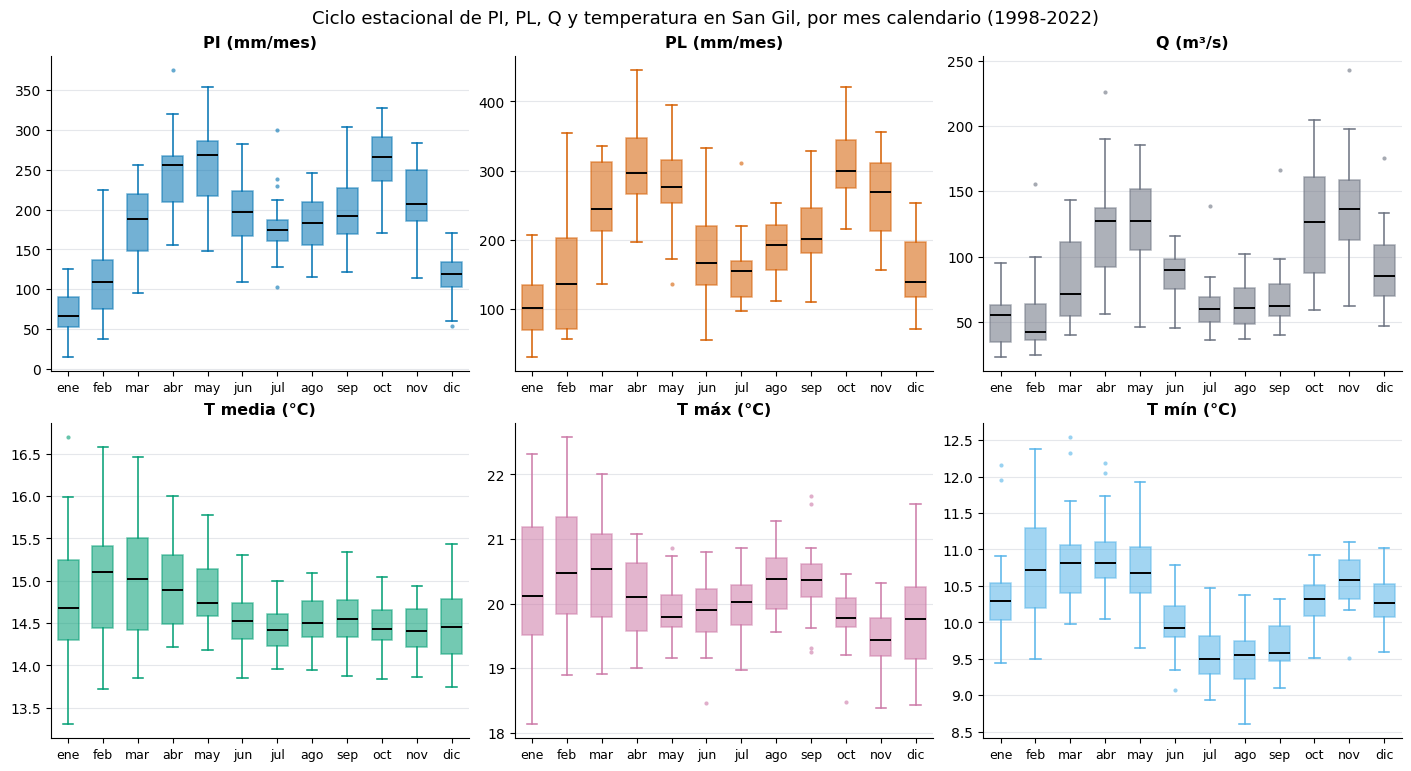

In [3]:
# --- diagramas de caja por mes calendario: la estacionalidad de cada variable, 1998-2022 ---
# Cada caja junta los valores de ese mes en todos los años disponibles (sin NaN); no se cruzan
# las seis variables entre sí, cada una usa sus propios meses válidos, igual que en 1.0.
MESES_ABREV = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]

# paleta Okabe-Ito del proyecto: PI y PL con su color fijo, Q en gris, las tres temperaturas
# con un tono distinto para cada una (los mismos que en el informe)
COLOR_POR_VARIABLE = {
    "PI (mm/mes)": "#0072B2",
    "PL (mm/mes)": "#D55E00",
    "Q (m³/s)": "#6B7280",
    "T media (°C)": "#009E73",
    "T máx (°C)": "#CC79A7",
    "T mín (°C)": "#56B4E9",
}

fig, ejes = plt.subplots(2, 3, figsize=(14, 7.6), constrained_layout=True)

for eje, columna in zip(ejes.flat, variables_resumen.columns):
    color = COLOR_POR_VARIABLE[columna]
    # un array por mes calendario, solo con los años que tienen dato ese mes
    datos_por_mes = [variables_resumen.loc[variables_resumen.index.month == mes, columna].dropna().values
                      for mes in range(1, 13)]
    eje.boxplot(datos_por_mes, tick_labels=MESES_ABREV, widths=0.6, patch_artist=True,
                medianprops=dict(color="black", linewidth=1.4),
                boxprops=dict(facecolor=color, alpha=0.55, edgecolor=color, linewidth=1.1),
                whiskerprops=dict(color=color, linewidth=1.1),
                capprops=dict(color=color, linewidth=1.1),
                flierprops=dict(marker="o", markersize=3, markerfacecolor=color,
                                 markeredgecolor="none", alpha=0.6))
    eje.set_title(columna, fontsize=11.5, weight="semibold")
    eje.tick_params(axis="x", labelsize=9)
    eje.grid(axis="y", color="#E5E7EB", linewidth=0.8, zorder=0)
    eje.set_axisbelow(True)
    for lado in ("top", "right"):
        eje.spines[lado].set_visible(False)

fig.suptitle("Ciclo estacional de PI, PL, Q y temperatura en San Gil, por mes calendario (1998-2022)",
             fontsize=13)
plt.show()

**Cómo leer las cajas.** La caja va del primer al tercer cuartil (Q1 a Q3) de ese mes en los años del período que tienen dato ese mes; la línea dentro es la mediana. Los bigotes se extienden hasta 1.5 veces el rango intercuartil desde la caja, y los puntos son los meses que caen fuera de ese rango (atípicos).

### 1.1 Precipitación mensual de IMERG, promediada sobre cada cuenca

IMERG entrega la lluvia en una grilla de celdas de 0.1° (unos 11 km de lado, 122 km² a esta latitud).
Para tener una serie por cuenca se promedian las celdas que la tocan, **ponderando cada una por la
fracción de su área que cae dentro de la cuenca**: una celda que solo roza el borde pesa poco y una que
está completamente adentro pesa el máximo. Ese cálculo está en `scripts/05_imerg_mensual_cuencas.py`
y su resultado es `out/imerg_mensual_fonce.csv`, que es lo que carga la celda de datos (`imerg`).

Estos valores vienen del producto **mensual** de IMERG (`GPM_3IMERGM`). Más adelante los compararemos
con la suma de los días del producto **diario** (`GPM_3IMERGDF`), que es una verificación independiente
del mismo dato.

In [4]:
# serie mensual por cuenca, en formato ancho: una columna por estación
p_mensual = (imerg.pivot(index="periodo", columns="id_estacion", values="p_imerg_mm")
                  .reindex(columns=list(ESTACIONES)).sort_index())

print(f"período: {p_mensual.index.min()} a {p_mensual.index.max()}  ({len(p_mensual)} meses)")
print(f"meses sin dato en San Gil: {int(p_mensual[ID_PRINCIPAL].isna().sum())} de {len(p_mensual)}")

resumen_mensual = pd.DataFrame({
    "media (mm/mes)": p_mensual.mean(),
    "mediana (mm/mes)": p_mensual.median(),
    "mínimo (mm/mes)": p_mensual.min(),
    "máximo (mm/mes)": p_mensual.max(),
    "media anual (mm/año)": p_mensual.mean() * 12,
}).round(1)
resumen_mensual.index = [ESTACIONES[i] for i in resumen_mensual.index]
resumen_mensual

período: 1998-01 a 2022-12  (300 meses)
meses sin dato en San Gil: 0 de 300


,media (mm/mes),mediana (mm/mes),mínimo (mm/mes),máximo (mm/mes),media anual (mm/año)
"San Gil (Fonce, salida)",185.3,185.5,14.8,375.1,2224.0
Mérida (Fonce),183.5,182.0,14.6,374.8,2202.6
Nemizaque (Pienta),177.3,177.3,15.1,374.5,2127.9
Puente Llano (Taquiza),180.4,179.0,13.2,366.8,2164.4
Puente Cabra (Mogoticos),183.6,183.7,14.7,367.8,2202.9
Puente Arco (Monchía),191.7,190.2,14.7,375.0,2300.6


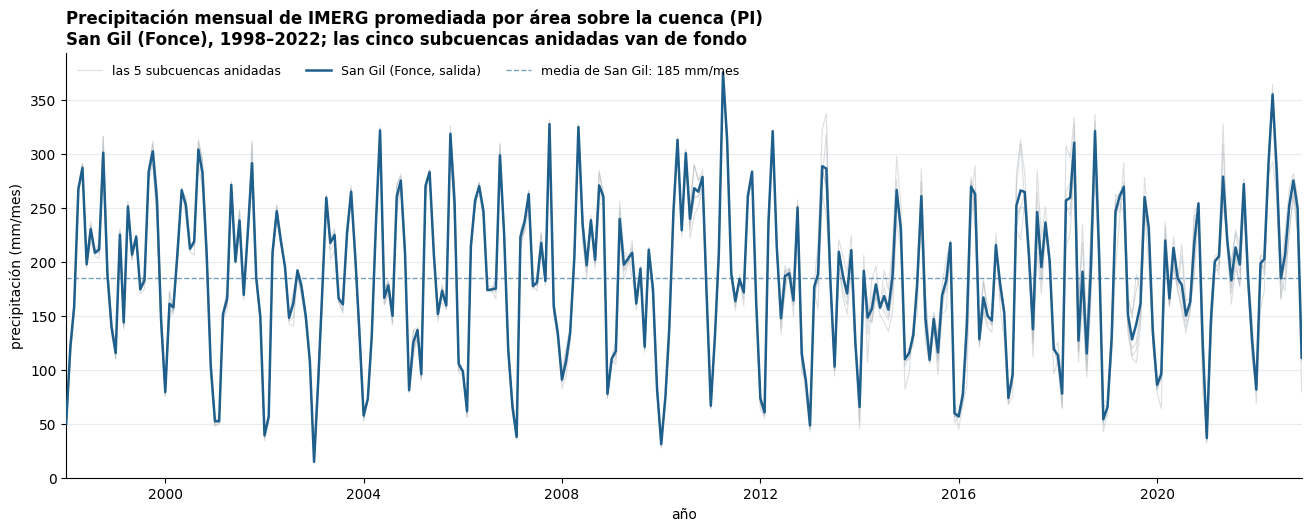

In [5]:
AZUL, GRIS = "#1F5F8B", "#8B949B"
t = p_mensual.index.to_timestamp()
media_sg = p_mensual[ID_PRINCIPAL].mean()

fig, eje = plt.subplots(figsize=(13, 5.2), constrained_layout=True)

# las cinco subcuencas van de fondo: dan contexto sin competir con San Gil
for k, id_est in enumerate(ESTACIONES):
    if id_est == ID_PRINCIPAL:
        continue
    eje.plot(t, p_mensual[id_est], color=GRIS, lw=0.8, alpha=0.30, zorder=1,
             label="las 5 subcuencas anidadas" if k == 1 else None)

eje.plot(t, p_mensual[ID_PRINCIPAL], color=AZUL, lw=1.8, zorder=3,
         label=f"{ESTACIONES[ID_PRINCIPAL]}")
eje.axhline(media_sg, color=AZUL, lw=1, ls="--", alpha=0.6, zorder=2,
            label=f"media de San Gil: {media_sg:.0f} mm/mes")

eje.set_xlabel("año")
eje.set_ylabel("precipitación (mm/mes)")
eje.set_ylim(0, None)
eje.set_xlim(t[0], t[-1])
eje.grid(axis="y", color="#E9ECEF", lw=0.8)
eje.set_axisbelow(True)
for lado in ("top", "right"):
    eje.spines[lado].set_visible(False)
eje.legend(frameon=False, loc="upper left", ncol=3, fontsize=9)
eje.set_title("Precipitación mensual de IMERG promediada por área sobre la cuenca (PI)\n"
              "San Gil (Fonce), 1998–2022; las cinco subcuencas anidadas van de fondo",
              fontsize=12, fontweight="semibold", loc="left")
plt.show()

**Lo que se ve.** La serie de San Gil es bimodal: dos temporadas de lluvia al año, que se ven como pares
de picos, con una media de 185 mm/mes. Las cinco subcuencas, de fondo, siguen la misma forma casi mes a
mes; sus diferencias están en el nivel medio (de 177 mm/mes en Pienta a 192 en Monchía), no en el ritmo.
Eso es esperable: las celdas de IMERG que alimentan a las seis se solapan entre sí, porque una celda de
122 km² es más grande que Monchía (165 km²) o Mogoticos (183 km²).

San Gil no tiene ningún mes vacío en los 300 del período 1998–2022.

### 1.2 Las fuentes de precipitación, comparadas entre sí

Hay dos maneras de saber cuánto llueve sobre esta cuenca, y no dan lo mismo:

- **IMERG**, satélite, celdas de 0.1° (~122 km² a esta latitud), promediado sobre el polígono de la
  cuenca ponderando cada celda por su área dentro de ella.
- **Los pluviómetros del IDEAM**, que miden en el suelo pero en un punto: las **7 estaciones que caen
  dentro de la divisoria** de San Gil con serie mensual en 1998-2022, descargadas del portal DHIME.

**Nota (2026-09-26): CHIRPS, retirado del análisis.** CAMELS-COL trae una tercera serie de precipitación,
CHIRPS, ya promediada sobre la cuenca por quienes armaron el dataset. Se decidió no usarla: comparte
calibración con IMERG y con las mismas estaciones del IDEAM que forman el promedio de la red, así que no
aporta un punto de vista independiente frente a las dos fuentes que sí se comparan abajo; además, al venir
del mismo archivo que el caudal, arrastra sus huecos (ver 1.4). La columna `p_chirps` sigue llegando al
cargar el archivo de CAMELS-COL en la celda de datos, porque así viene el archivo, pero de aquí en
adelante no se usa en ningún análisis ni figura.

Los pluviómetros se comparan de dos formas a la vez: **uno a uno**, tenues al fondo, para ver cuánto se
dispersan entre ellos; y como **promedio de la red**, a plena opacidad, que es la estimación que
realmente compite con el satélite. Cada mes se promedia con los pluviómetros que tengan dato ese mes;
no se rellena ninguno.

In [6]:
# --- los pluviómetros, como matriz de meses x estación ---
# la cruda (con Encino 2016-2018) solo la usa 1.7, para mostrar por qué se excluye ese tramo
pluvio_mes_crudo = (pluvio_mensual_crudo.assign(periodo=pluvio_mensual_crudo.fecha.dt.to_period("M"))
                    .pivot(index="periodo", columns="codigo", values="precipitacion_mm"))
pluvio_mes = (pluvio_mensual.assign(periodo=pluvio_mensual.fecha.dt.to_period("M"))
              .pivot(index="periodo", columns="codigo", values="precipitacion_mm"))

# El promedio de la red (PL) usa los 7 pluviómetros de la cuenca (la celda de datos ya dejó fuera al
# que cae en la vertiente del Chicamocha). Cada mes se promedia con los pluviómetros que tengan dato ese
# mes, sin rellenar los que falten.
promedio_pluvio = pluvio_mes[PLUVIO_EN_CUENCA].mean(axis=1, skipna=True)
n_pluvio_por_mes = pluvio_mes[PLUVIO_EN_CUENCA].notna().sum(axis=1)

comp = pd.concat([p_mensual[ID_PRINCIPAL].rename("IMERG"),
                  promedio_pluvio.rename("PLUVIO"), pluvio_mes], axis=1).sort_index()
comp = comp.loc[p_mensual.index.min():p_mensual.index.max()]      # el período de estudio

print(f"pluviómetros de la cuenca: {len(PLUVIO_EN_CUENCA)}")
print(f"meses con al menos un pluviómetro: {int((n_pluvio_por_mes > 0).sum())} de {len(comp)}")
print(f"pluviómetros disponibles por mes: mediana {int(n_pluvio_por_mes.median())}, "
      f"mínimo {int(n_pluvio_por_mes.min())}, máximo {int(n_pluvio_por_mes.max())}\n")

filas = {}
for columna, etiqueta in ([("PLUVIO", "promedio de la red")]
                          + [(cod, PLUVIOMETROS[cod]) for cod in PLUVIO_EN_CUENCA]):
    par = comp[["IMERG", columna]].dropna()
    anual = par.groupby(par.index.year).sum()[par.groupby(par.index.year).size() == 12]
    filas[etiqueta] = {
        "meses comparables": len(par),
        "IMERG (mm/mes)": par.IMERG.mean(),
        "la otra fuente (mm/mes)": par[columna].mean(),
        "diferencia de IMERG (%)": (par.IMERG.mean() / par[columna].mean() - 1) * 100,
        "correlación mensual (Pearson)": par.IMERG.corr(par[columna]),
        "años completos": len(anual),
        "la otra fuente (mm/año)": anual[columna].mean() if len(anual) else float("nan"),
    }
pd.DataFrame(filas).T.round(2)

pluviómetros de la cuenca: 7
meses con al menos un pluviómetro: 300 de 300
pluviómetros disponibles por mes: mediana 6, mínimo 4, máximo 7



,meses comparables,IMERG (mm/mes),la otra fuente (mm/mes),diferencia de IMERG (%),correlación mensual (Pearson),años completos,la otra fuente (mm/año)
promedio de la red,300.0,185.33,210.69,-12.04,0.85,25.0,2528.25
Encino,258.0,187.38,265.96,-29.54,0.37,18.0,3143.33
Charalá,290.0,183.18,224.73,-18.49,0.76,20.0,2754.68
Pavas Las,271.0,186.24,184.24,1.08,0.54,14.0,2240.99
Pueblo Viejo,191.0,183.73,158.46,15.95,0.72,13.0,1905.76
Coromoro,300.0,185.33,209.33,-11.46,0.74,25.0,2511.96
Valle de San Jose,292.0,188.24,182.38,3.21,0.69,18.0,2100.34
Escuela Agricola Mogotes,296.0,185.02,236.58,-21.79,0.80,23.0,2836.26


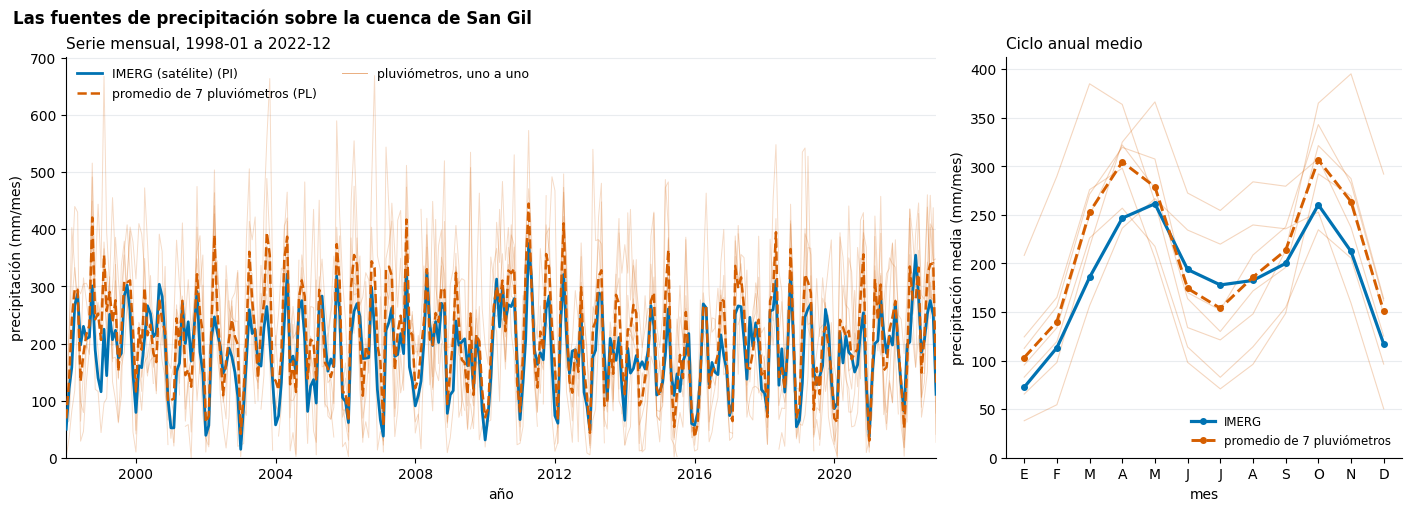

In [7]:
# paleta apta para daltonismo (Okabe-Ito); además, satélite = línea continua y pluviómetro = punteada,
# para que las series se distingan sin depender solo del color.
# Decisión de dibujo: los pluviómetros individuales van tenues, como nube de fondo, y encima va a plena
# opacidad el promedio de los que tengan dato cada mes. Lo que importa es la red, no cada aparato.
AZUL, NARANJA = "#0072B2", "#D55E00"
FUENTES = [("IMERG", "IMERG (satélite) (PI)", AZUL, "-", 2.0),
           ("PLUVIO", f"promedio de {len(PLUVIO_EN_CUENCA)} pluviómetros (PL)", NARANJA, "--", 1.8)]
t = comp.index.to_timestamp()

fig, (a, b) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True,
                           gridspec_kw={"width_ratios": [2.2, 1]})

# --- izquierda: las series mensuales ---
for cod in PLUVIO_EN_CUENCA:                       # la nube de pluviómetros individuales
    a.plot(t, comp[cod], color=NARANJA, ls="-", lw=0.7, alpha=0.22, zorder=1)
for columna, etiqueta, color, estilo, grosor in FUENTES:
    a.plot(t, comp[columna], color=color, ls=estilo, lw=grosor, label=etiqueta, zorder=3)
a.plot([], [], color=NARANJA, lw=0.7, alpha=0.5, label="pluviómetros, uno a uno")   # entrada de leyenda
a.set_xlim(t[0], t[-1]); a.set_ylim(0, None)
a.set_xlabel("año"); a.set_ylabel("precipitación (mm/mes)")
a.grid(axis="y", color="#E9ECEF", lw=0.8); a.set_axisbelow(True)
a.legend(frameon=False, fontsize=9, loc="upper left", ncol=2)
a.set_title(f"Serie mensual, {comp.index.min()} a {comp.index.max()}", fontsize=11, loc="left")

# --- derecha: ciclo anual medio ---
MES = ["E", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]
ciclo = comp.groupby(comp.index.month).mean()
for cod in PLUVIO_EN_CUENCA:
    b.plot(ciclo.index, ciclo[cod], color=NARANJA, lw=0.8, alpha=0.25, zorder=1)
for columna, etiqueta, color, estilo, grosor in FUENTES:
    b.plot(ciclo.index, ciclo[columna], color=color, ls=estilo, lw=grosor + 0.3, marker="o", ms=4,
           label=etiqueta.split(" (")[0], zorder=3)
b.set_xticks(range(1, 13), MES); b.set_ylim(0, None)
b.set_xlabel("mes"); b.set_ylabel("precipitación media (mm/mes)")
b.grid(axis="y", color="#E9ECEF", lw=0.8); b.set_axisbelow(True)
b.legend(frameon=False, fontsize=8.5)
b.set_title("Ciclo anual medio", fontsize=11, loc="left")

for eje in (a, b):
    for lado in ("top", "right"):
        eje.spines[lado].set_visible(False)
fig.suptitle("Las fuentes de precipitación sobre la cuenca de San Gil",
             fontsize=12, fontweight="semibold", x=0.005, ha="left")
plt.show()

In [8]:
# --- 1.2: lectura, con las cifras calculadas arriba ---
_miles = lambda x: f"{x:,.0f}".replace(",", " ")
MESES_LARGOS = ["enero", "febrero", "marzo", "abril", "mayo", "junio", "julio", "agosto", "septiembre",
                "octubre", "noviembre", "diciembre"]
_t = pd.DataFrame(filas).T
_red, _ind = _t.loc["promedio de la red"], _t.drop(index="promedio de la red")
_c = _ind["correlación mensual (Pearson)"].astype(float)
_m = _ind["la otra fuente (mm/mes)"].astype(float)
_alt = {PLUVIOMETROS[c]: pluvio_catalogo.loc[c, "altitud"] for c in PLUVIO_EN_CUENCA}
_dif = _red["diferencia de IMERG (%)"]
_ciclo = comp[["IMERG", "PLUVIO"]].groupby(comp.index.month).mean()
_picos = lambda s: (MESES_LARGOS[s.loc[1:6].idxmax() - 1], MESES_LARGOS[s.loc[7:12].idxmax() - 1],
                    MESES_LARGOS[s.loc[5:9].idxmin() - 1])
_ppl, _ppi = _picos(_ciclo.PLUVIO), _picos(_ciclo.IMERG)
_exc = pluvio_exclusiones.assign(nombre=pluvio_exclusiones.codigo.map(PLUVIOMETROS)).groupby("nombre").meses_excluidos.sum()
display(Markdown(f"""
**Lo que se ve.**

1. **El promedio de la red le gana a cualquier pluviómetro suelto.** Su correlación mensual con IMERG es
   **{_red['correlación mensual (Pearson)']:.2f}**, mientras que los pluviómetros individuales van de {_c.min():.2f}
   ({_c.idxmin()}) a {_c.max():.2f} ({_c.idxmax()}). Promediar siete aparatos cancela el ruido propio de cada uno
   —lecturas mal transcritas, días sin registro, un embudo tapado— y deja la señal común, que es la lluvia de la
   cuenca. Es el argumento para usar la red y no una estación "representativa".
2. **IMERG queda un {abs(_dif):.1f} % {"por debajo" if _dif < 0 else "por encima"} de la red de pluviómetros**:
   {_red['IMERG (mm/mes)']:.1f} mm/mes contra {_red['la otra fuente (mm/mes)']:.1f}, o
   {_miles(_red['IMERG (mm/mes)'] * 12)} mm/año contra {_miles(_red['la otra fuente (mm/mes)'] * 12)}, sobre los
   {int(_red['meses comparables'])} meses del período. Es la dirección esperable: los satélites tienden a
   subestimar la lluvia orográfica de montaña, que es justo la de esta cuenca.
3. **La dispersión entre pluviómetros es grande.** Van de {_m.min():.0f} mm/mes en {_m.idxmin()}
   ({_miles(_alt[_m.idxmin()])} m) a {_m.max():.0f} en {_m.idxmax()} ({_miles(_alt[_m.idxmax()])} m), un factor de
   {_m.max() / _m.min():.1f} entre dos puntos de la misma cuenca. En terreno de montaña la lluvia cambia de ladera a
   ladera: ningún pluviómetro solo representa la cuenca.
4. **El ciclo anual de la red y el del satélite tienen la misma forma bimodal.** PL pone sus picos en {_ppl[0]} y
   {_ppl[1]}, y PI en {_ppi[0]} y {_ppi[1]}; el mínimo de mitad de año cae en {_ppl[2] + " en las dos" if _ppl[2] == _ppi[2] else _ppl[2] + " y en " + _ppi[2] + ", respectivamente"}.
5. **Tramos excluidos de PL**: {"; ".join(f"{n}, {int(k)} meses" for n, k in _exc.items())}. Son problemas de registro
   que ni los vecinos ni IMERG acompañan (evidencia en 1.7 y en 4.3). Todas las cifras de esta sección ya los
   excluyen.
"""))


**Lo que se ve.**

1. **El promedio de la red le gana a cualquier pluviómetro suelto.** Su correlación mensual con IMERG es
   **0.85**, mientras que los pluviómetros individuales van de 0.37
   (Encino) a 0.80 (Escuela Agricola Mogotes). Promediar siete aparatos cancela el ruido propio de cada uno
   —lecturas mal transcritas, días sin registro, un embudo tapado— y deja la señal común, que es la lluvia de la
   cuenca. Es el argumento para usar la red y no una estación "representativa".
2. **IMERG queda un 12.0 % por debajo de la red de pluviómetros**:
   185.3 mm/mes contra 210.7, o
   2 224 mm/año contra 2 528, sobre los
   300 meses del período. Es la dirección esperable: los satélites tienden a
   subestimar la lluvia orográfica de montaña, que es justo la de esta cuenca.
3. **La dispersión entre pluviómetros es grande.** Van de 158 mm/mes en Pueblo Viejo
   (2 107 m) a 266 en Encino (1 814 m), un factor de
   1.7 entre dos puntos de la misma cuenca. En terreno de montaña la lluvia cambia de ladera a
   ladera: ningún pluviómetro solo representa la cuenca.
4. **El ciclo anual de la red y el del satélite tienen la misma forma bimodal.** PL pone sus picos en abril y
   octubre, y PI en mayo y octubre; el mínimo de mitad de año cae en julio en las dos.
5. **Tramos excluidos de PL**: Encino, 36 meses; Pavas Las, 5 meses; Pueblo Viejo, 76 meses; Valle de San Jose, 2 meses. Son problemas de registro
   que ni los vecinos ni IMERG acompañan (evidencia en 1.7 y en 4.3). Todas las cifras de esta sección ya los
   excluyen.


**Cómo leerlo.** Un pluviómetro mide un punto y el satélite promedia 122 km², así que se espera
dispersión; lo que no se espera es un sesgo sistemático. No existe en esta cuenca una tercera fuente
independiente contra la cual medir a las otras dos, y cada una tiene su argumento a favor y en contra:

| | A favor | En contra |
|---|---|---|
| **Red de pluviómetros** | Mide la lluvia en el suelo, directamente, y el promedio de siete aparatos es estable. | Los datos vienen marcados como **preliminares** por el IDEAM, sin validar; siete puntos son pocos para una cuenca de montaña, y ninguno está en la parte más alta. |
| **IMERG** | Cubre toda la cuenca sin huecos y su serie está completa. | Es una estimación indirecta que promedia celdas de 122 km², demasiado grandes para el detalle de esta cuenca de montaña. |

**Qué se hace, entonces.** No se corrige una por la otra. **En la mayoría de los análisis se usan las
dos**, IMERG (PI) y el promedio de la red (PL), y se reportan en paralelo, para que el desacuerdo no quede
escondido. **Cuando haya que escoger una, manda PL**, porque son medidas reales de lluvia en la cuenca y
no una estimación indirecta; PI queda como contraste. Es la regla 11 del proyecto.

### 1.3 Precipitación y caudal en las mismas unidades

El caudal observado viene en la columna `caudal` de los archivos de CAMELS-COL (la serie que mide el
IDEAM en la estación), en m³/s. Dividiéndolo por el área de la cuenca queda en **mm/día**, o sea la
lámina de agua que sale de la cuenca, que es comparable directamente con la lluvia que le cae encima.
Eso permite ponerlos en el mismo eje: lo que entra (precipitación) y lo que sale (caudal), sin ejes
dobles que confundan la lectura.

El caudal diario se pasa a mensual con `a_mensual`, que **deja el mes vacío si le faltan cinco o más
días** (regla del proyecto, `MAX_DIAS_FALTANTES = 4`). El acumulado del mes es el caudal medio de los días
con dato por los días del mes; así un mes al que le faltan hasta cuatro días no queda subestimado, como
pasaría si simplemente se sumaran los días que hay (ver 4.1).

In [9]:
q_diario = (diario[diario.id_estacion == ID_PRINCIPAL]
            .set_index("fecha")["caudal_mm"])
q_mensual = a_mensual(q_diario, "sum")
q_mensual.index = q_mensual.index.to_period("M")

# se conservan todos los meses del período de IMERG: los que no tienen caudal quedan como NaN
# y así aparecen como hueco en la figura, en vez de unirse con una línea que no existe
balance = pd.DataFrame({"p_imerg": p_mensual[ID_PRINCIPAL], "q": q_mensual}).reindex(p_mensual.index)
balance["escorrentia"] = balance.q / balance.p_imerg
completos = balance.dropna(subset=["p_imerg", "q"])

print(f"meses con lluvia y caudal a la vez: {len(completos)} de {len(p_mensual)}")
print(f"lluvia    media {completos.p_imerg.mean():6.1f} mm/mes  ({completos.p_imerg.mean() * 12:.0f} mm/año)")
print(f"caudal    media {completos.q.mean():6.1f} mm/mes  ({completos.q.mean() * 12:.0f} mm/año)")
print(f"coeficiente de escorrentía del período: {completos.q.sum() / completos.p_imerg.sum():.2f}")
print(f"meses en que salió más agua de la que cayó (coef. > 1): {int((completos.escorrentia > 1).sum())}"
      f"  | máximo: {completos.escorrentia.max():.2f} en {completos.escorrentia.idxmax()}")

meses con lluvia y caudal a la vez: 262 de 300
lluvia    media  183.4 mm/mes  (2201 mm/año)
caudal    media  110.9 mm/mes  (1331 mm/año)
coeficiente de escorrentía del período: 0.60
meses en que salió más agua de la que cayó (coef. > 1): 21  | máximo: 2.92 en 2003-01


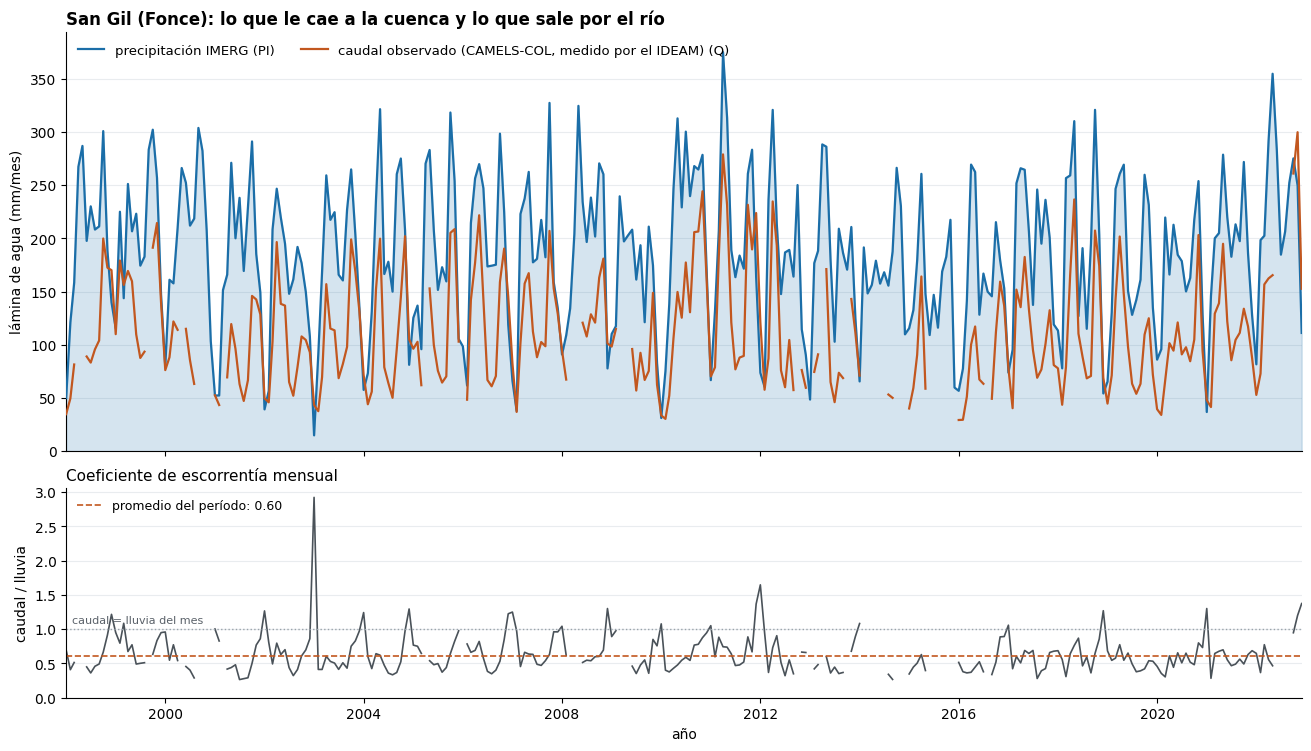

In [10]:
AZUL, NARANJA = "#1B6EA8", "#C2571F"
t = balance.index.to_timestamp()

fig, (a, b) = plt.subplots(2, 1, figsize=(13, 7.4), height_ratios=[2, 1],
                           sharex=True, constrained_layout=True)

# --- arriba: lluvia y caudal, mismo eje, mismas unidades ---
a.fill_between(t, balance.p_imerg, color=AZUL, alpha=0.18, zorder=1)
a.plot(t, balance.p_imerg, color=AZUL, lw=1.6, zorder=3, label="precipitación IMERG (PI)")
# el caudal va como línea, sin relleno: con los meses faltantes el relleno deja rayas sueltas
a.plot(t, balance.q, color=NARANJA, lw=1.6, zorder=4, label="caudal observado (CAMELS-COL, medido por el IDEAM) (Q)")
a.set_ylabel("lámina de agua (mm/mes)")
a.set_ylim(0, None)
a.grid(axis="y", color="#E9ECEF", lw=0.8); a.set_axisbelow(True)
a.legend(frameon=False, loc="upper left", ncol=2, fontsize=9.5)
a.set_title("San Gil (Fonce): lo que le cae a la cuenca y lo que sale por el río",
            fontsize=12, fontweight="semibold", loc="left")

# --- abajo: qué fracción de la lluvia sale como caudal ---
media_esc = completos.q.sum() / completos.p_imerg.sum()
b.plot(t, balance.escorrentia, color="#4A5259", lw=1.2)
b.axhline(media_esc, color=NARANJA, lw=1.2, ls="--",
          label=f"promedio del período: {media_esc:.2f}")
b.axhline(1, color="#9AA3AA", lw=1, ls=":")
b.annotate("caudal = lluvia del mes", (t[0], 1), xytext=(4, 4), textcoords="offset points",
           fontsize=8, color="#5A6169")
b.set_ylabel("caudal / lluvia")
b.set_xlabel("año")
b.set_ylim(0, None)
b.grid(axis="y", color="#E9ECEF", lw=0.8); b.set_axisbelow(True)
b.legend(frameon=False, loc="upper left", fontsize=9)
b.set_title("Coeficiente de escorrentía mensual", fontsize=11, loc="left")

for eje in (a, b):
    for lado in ("top", "right"):
        eje.spines[lado].set_visible(False)
a.set_xlim(t[0], t[-1])
plt.show()

**Lo que se ve.**

1. **Sale como caudal el 60 % de la lluvia** (1 331 mm/año de 2 201 mm/año). El resto se evapora o
   se queda almacenado. Es un valor alto pero razonable para una cuenca andina húmeda y empinada.
2. **El caudal sigue a la lluvia sin retraso visible a escala mensual**: los dos suben y bajan casi a la
   vez. Con datos mensuales no se puede ver un desfase de días.
3. **La franja azul entre las dos curvas es lo que la cuenca no devuelve**, y se angosta en las
   temporadas húmedas: cuando el suelo ya está mojado, una fracción mayor de la lluvia se convierte en
   caudal.
4. **Hay huecos de caudal** (los más largos, alrededor de 2014–2016), donde el registro del IDEAM no
   alcanza los días mínimos que exige la regla. Quedan como espacios en blanco, no se rellenan.
5. **Algunos meses tienen coeficiente mayor que 1**, es decir que salió más agua de la que cayó ese mes.
   Hasta cierto punto es normal, porque el río descarga agua almacenada de meses anteriores, pero el
   valor extremo de 2.9 es demasiado alto para explicarse así: o la lluvia de ese mes está subestimada
   por IMERG, o hay un problema en el caudal. Queda como cosa por revisar.

### 1.4 Completitud: qué meses tienen dato y cuáles no

Antes de analizar nada conviene ver **dónde están los huecos**. Cada celda de la figura es un mes: verde
si la variable tiene dato ese mes, rojo si no. Un mes de caudal cuenta como "con dato" cuando cumple la
regla del proyecto, es decir cuando le faltan cuatro días o menos.

La precipitación de IMERG es un producto satelital continuo, así que no tiene huecos; el caudal sí,
porque depende de que la estación haya estado midiendo.

In [11]:
# caudal mensual de CAMELS-COL (el mismo q_mensual de 1.3), recortado al período de estudio
q_cam = q_mensual.reindex(p_mensual.index)

COMPLETITUD = {
    "precipitación IMERG": p_mensual[ID_PRINCIPAL],
    "caudal (CAMELS-COL)": q_cam,
}

resumen_completitud = pd.DataFrame({
    nombre: {"meses con dato": int(s.notna().sum()),
             "meses sin dato": int(s.isna().sum()),
             "% completo": round(s.notna().mean() * 100, 1)}
    for nombre, s in COMPLETITUD.items()}).T
print(f"período {p_mensual.index.min()} a {p_mensual.index.max()}  ({len(p_mensual)} meses)")
resumen_completitud

período 1998-01 a 2022-12  (300 meses)


,meses con dato,meses sin dato,% completo
precipitación IMERG,300.0,0.0,100.0
caudal (CAMELS-COL),262.0,38.0,87.3


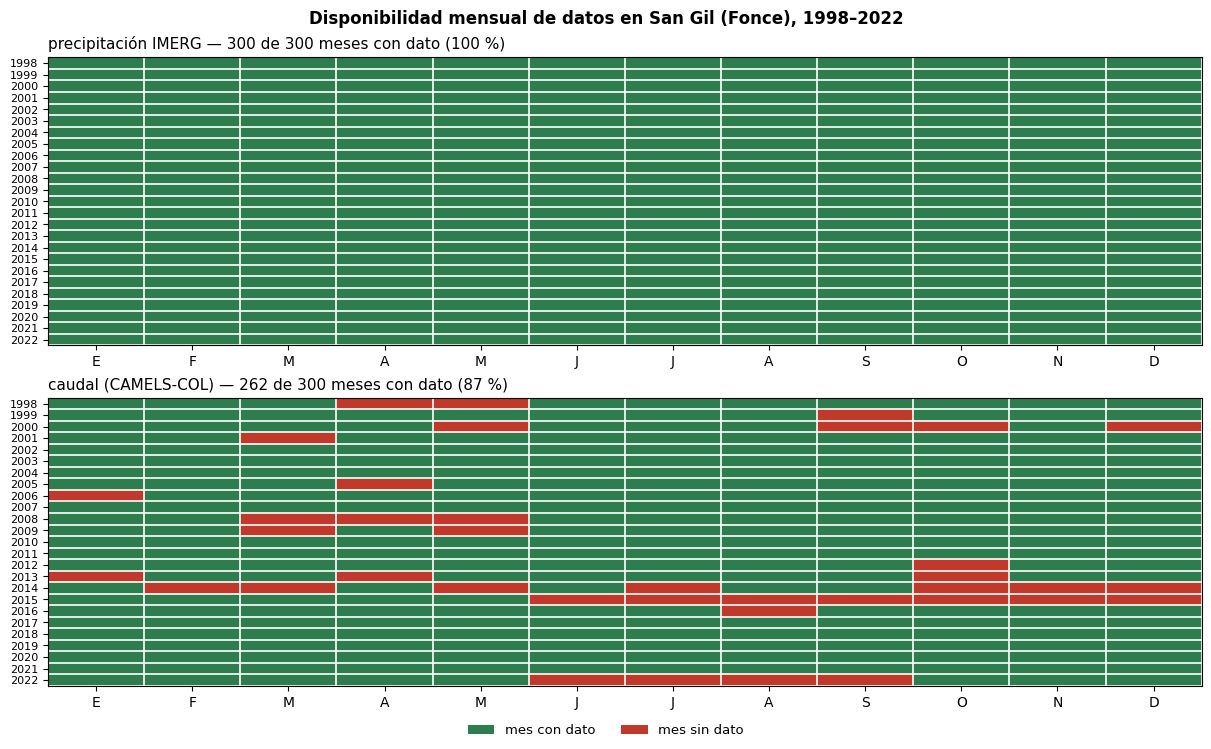

In [12]:
VERDE, ROJO = "#2E7D4F", "#C0392B"
anios = sorted(p_mensual.index.year.unique())
MES_INI = ["E", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

fig, ejes = plt.subplots(len(COMPLETITUD), 1, figsize=(12, 2.2 + 2.6 * len(COMPLETITUD)),
                         constrained_layout=True)
for eje, (nombre, serie) in zip(np.atleast_1d(ejes), COMPLETITUD.items()):
    # matriz años x meses: 1 = hay dato, 0 = no hay
    m = pd.DataFrame(index=anios, columns=range(1, 13), dtype=float)
    for periodo, valor in serie.items():
        m.loc[periodo.year, periodo.month] = float(pd.notna(valor))
    eje.imshow(m.values, cmap=ListedColormap([ROJO, VERDE]), vmin=0, vmax=1,
               aspect="auto", interpolation="nearest")
    eje.set_xticks(range(12), MES_INI)
    eje.set_yticks(range(len(anios)), anios, fontsize=8)
    eje.set_xticks(np.arange(-.5, 12, 1), minor=True)
    eje.set_yticks(np.arange(-.5, len(anios), 1), minor=True)
    eje.grid(which="minor", color="white", lw=1.2)
    eje.tick_params(which="minor", length=0)
    con = int(serie.notna().sum())
    eje.set_title(f"{nombre} — {con} de {len(serie)} meses con dato ({con / len(serie) * 100:.0f} %)",
                  fontsize=11, loc="left")

parches = [Patch(facecolor=VERDE, label="mes con dato"), Patch(facecolor=ROJO, label="mes sin dato")]
fig.legend(handles=parches, loc="outside lower center", ncol=2, frameon=False, fontsize=9.5)
fig.suptitle("Disponibilidad mensual de datos en San Gil (Fonce), 1998–2022",
             fontsize=12, fontweight="semibold")
plt.show()

**Lo que se ve, y es el hallazgo más útil de esta sección.**

1. **IMERG está completo**: los 300 meses. Es un producto satelital y no depende de que alguien vaya a
   leer un instrumento.
2. **El caudal de CAMELS-COL en San Gil llega a 262 meses de 300 (87 %)**, con huecos repartidos por
   casi todos los años. Los peores son **2014 y 2015**, con 7 meses vacíos cada uno; 2017 a 2021 están
   completos.

Ampliar la regla de uno a cuatro días faltantes recuperó 47 meses: con el umbral anterior quedaban 215 y
ahora quedan 262. Esos meses se perdían por faltantes dispersos de dos a cuatro días.

### 1.5 Las dos fuentes de temperatura, comparadas entre sí

El proyecto tiene temperatura por dos caminos distintos, y ninguno de los dos es una observación:

- **ERA5-Land** (ECMWF), bajada de Earth Engine y promediada sobre el polígono de la cuenca ponderando
  cada celda por su área dentro de ella, igual que se hace con IMERG. Malla de 0.1°.
- **MSWX**, que viene dentro de CAMELS-COL como las columnas `t_min` y `t_max` de la cuenca.

Los dos son productos de malla: uno es un reanálisis y el otro una interpolación corregida por sesgo.
Compararlos no dice cuál tiene la razón, pero sí cuánta incertidumbre arrastra la temperatura de
entrada, que es lo que después alimenta el cálculo de evapotranspiración.

**Un detalle de método que hay que separar del resultado.** ERA5-Land entrega una media diaria
verdadera, promedio de las 24 horas. MSWX, dentro de CAMELS-COL, solo trae mínima y máxima, así que su
"media" hay que aproximarla como el punto medio `(t_min + t_max) / 2`. Ese punto medio no es la media
de las 24 horas: sobreestima, porque la temperatura pasa más horas cerca de la mínima que de la máxima.
Para que la comparación sea justa, abajo se calculan las dos cosas por separado: el sesgo entre fuentes
y el sesgo que introduce el método.

In [13]:
# --- las dos fuentes de temperatura, recortadas al período de estudio (regla del proyecto: 1998-2022) ---
PERIODO = slice("1998-01-01", "2022-12-31")

# ERA5-Land ya viene promediado sobre el polígono de la cuenca
t_era5 = era5.loc[PERIODO, ["t_media", "t_min", "t_max"]].copy()
t_era5["amplitud"] = t_era5.t_max - t_era5.t_min                  # rango diario, lo que usa Hargreaves
t_era5["punto_medio"] = (t_era5.t_min + t_era5.t_max) / 2         # para comparar con MSWX en igualdad

# MSWX, dentro de CAMELS-COL: solo hay mínima y máxima, la media se aproxima por el punto medio
_cam = diario[diario.id_estacion == ID_PRINCIPAL].set_index("fecha").loc[PERIODO]
t_mswx = _cam[["t_min", "t_max"]].copy()
t_mswx["amplitud"] = t_mswx.t_max - t_mswx.t_min
t_mswx["punto_medio"] = (t_mswx.t_min + t_mswx.t_max) / 2
t_mswx["t_media"] = t_mswx["punto_medio"]                         # es lo único que MSWX permite

# días en que las dos fuentes tienen dato, que son los únicos comparables
comunes = t_era5.join(t_mswx, how="inner", lsuffix="_era5", rsuffix="_mswx").dropna()

resumen_t = pd.DataFrame({
    "ERA5-Land": [t_era5.t_min.mean(), t_era5.t_max.mean(), t_era5.amplitud.mean(),
                  t_era5.punto_medio.mean(), t_era5.t_media.mean()],
    "MSWX (CAMELS-COL)": [t_mswx.t_min.mean(), t_mswx.t_max.mean(), t_mswx.amplitud.mean(),
                          t_mswx.punto_medio.mean(), np.nan],
}, index=["mínima diaria", "máxima diaria", "amplitud diaria",
          "media por punto medio", "media real de 24 h"])
resumen_t["diferencia"] = resumen_t["ERA5-Land"] - resumen_t["MSWX (CAMELS-COL)"]

# correlación entre fuentes, a escala diaria y mensual
mes_era5 = a_mensual(t_era5.punto_medio, "mean")
mes_mswx = a_mensual(t_mswx.punto_medio, "mean")
correlaciones = pd.Series({
    "mínima, diaria": comunes.t_min_era5.corr(comunes.t_min_mswx),
    "máxima, diaria": comunes.t_max_era5.corr(comunes.t_max_mswx),
    "punto medio, diaria": comunes.punto_medio_era5.corr(comunes.punto_medio_mswx),
    "punto medio, mensual": mes_era5.corr(mes_mswx),
})

print(f"días comparables: {len(comunes)} de {len(t_era5)} del período\n")
print("Promedios del período 1998-2022, en °C:")
print(resumen_t.round(2).to_string(na_rep="—"))
print("\nCorrelación entre las dos fuentes (r de Pearson):")
print(correlaciones.round(3).to_string())
print(f"\nEl método explica {t_era5.punto_medio.mean() - t_era5.t_media.mean():+.2f} °C: "
      f"es lo que el punto medio le suma a la media real de 24 h dentro de ERA5-Land,")
print(f"donde sí se pueden medir las dos. El resto de la diferencia entre fuentes, "
      f"{resumen_t.loc['media por punto medio', 'diferencia']:+.2f} °C, sí es desacuerdo entre productos.")

días comparables: 8601 de 9131 del período

Promedios del período 1998-2022, en °C:
                       ERA5-Land  MSWX (CAMELS-COL)  diferencia
mínima diaria              10.30              12.56       -2.27
máxima diaria              20.07              21.18       -1.11
amplitud diaria             9.78               8.62        1.16
media por punto medio      15.19              16.87       -1.69
media real de 24 h         14.68                  —           —

Correlación entre las dos fuentes (r de Pearson):
mínima, diaria          0.784
máxima, diaria          0.791
punto medio, diaria     0.772
punto medio, mensual    0.864

El método explica +0.51 °C: es lo que el punto medio le suma a la media real de 24 h dentro de ERA5-Land,
donde sí se pueden medir las dos. El resto de la diferencia entre fuentes, -1.69 °C, sí es desacuerdo entre productos.


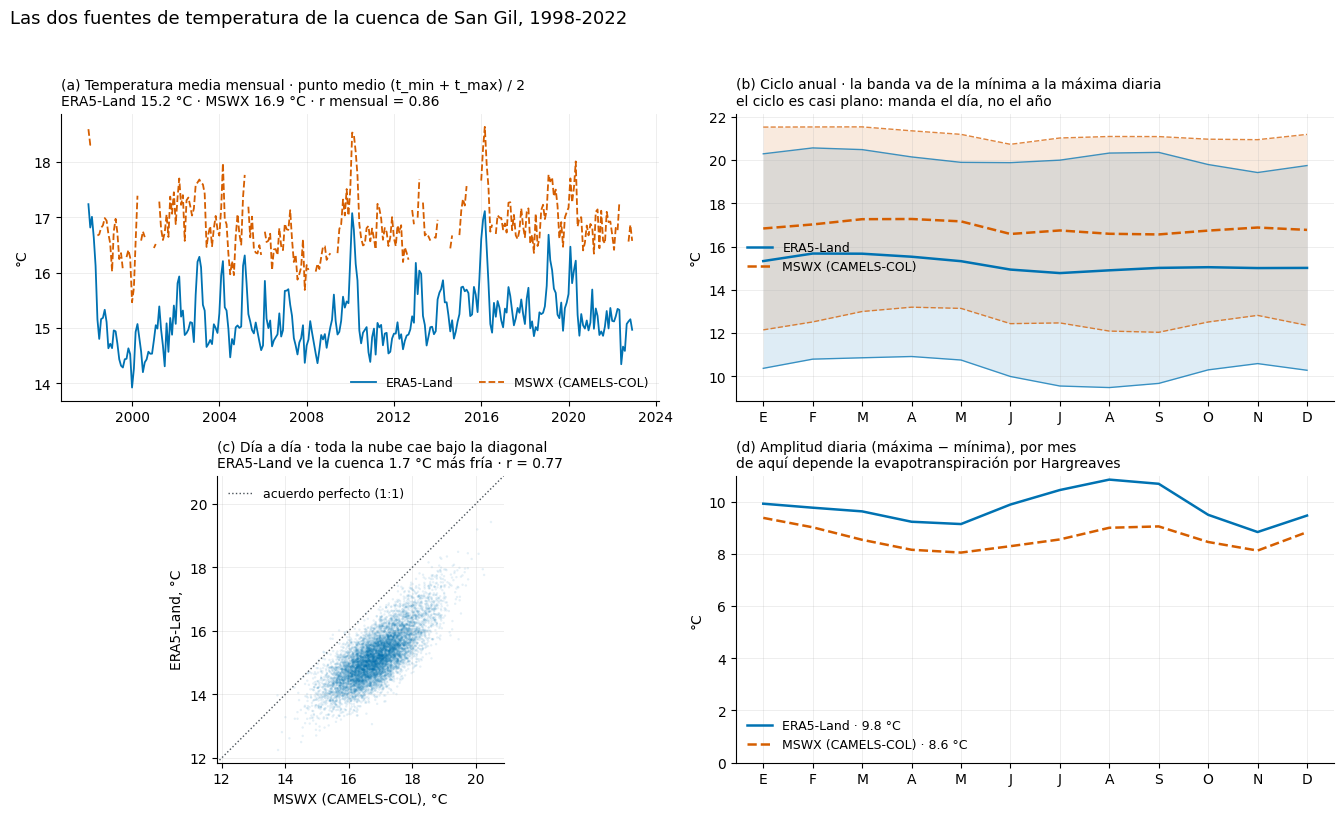

In [14]:
# paleta apta para daltonismo (Okabe-Ito); además, ERA5-Land = línea continua y MSWX = punteada,
# para que las dos se distingan aunque la figura se imprima en blanco y negro
AZUL_T, NARANJA_T = "#0072B2", "#D55E00"
FUENTES_T = [("ERA5-Land", t_era5, AZUL_T, "-"), ("MSWX (CAMELS-COL)", t_mswx, NARANJA_T, "--")]
MESES = ["E", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

fig, ax = plt.subplots(2, 2, figsize=(13.5, 8.2))

# --- (a) serie mensual del punto medio: la comparación en igualdad de método ---
for nombre, datos, color, estilo in FUENTES_T:
    serie = a_mensual(datos.punto_medio, "mean")                  # los huecos se ven como cortes
    ax[0, 0].plot(serie.index, serie.values, color=color, linestyle=estilo, lw=1.3, label=nombre)
ax[0, 0].set_title(f"(a) Temperatura media mensual · punto medio (t_min + t_max) / 2\n"
                   f"ERA5-Land {t_era5.punto_medio.mean():.1f} °C · "
                   f"MSWX {t_mswx.punto_medio.mean():.1f} °C · r mensual = "
                   f"{correlaciones['punto medio, mensual']:.2f}", fontsize=10, loc="left")
ax[0, 0].set_ylabel("°C")
ax[0, 0].legend(frameon=False, fontsize=9, ncol=2)

# --- (b) ciclo anual: la banda va de la mínima a la máxima media de cada mes ---
for nombre, datos, color, estilo in FUENTES_T:
    ciclo = datos.groupby(datos.index.month)[["t_min", "t_max", "punto_medio"]].mean()
    ax[0, 1].fill_between(ciclo.index, ciclo.t_min, ciclo.t_max, color=color, alpha=0.13, lw=0)
    ax[0, 1].plot(ciclo.index, ciclo.punto_medio, color=color, linestyle=estilo, lw=1.8, label=nombre)
    for col in ("t_min", "t_max"):
        ax[0, 1].plot(ciclo.index, ciclo[col], color=color, linestyle=estilo, lw=1.0, alpha=0.75)
ax[0, 1].set_title("(b) Ciclo anual · la banda va de la mínima a la máxima diaria\n"
                   "el ciclo es casi plano: manda el día, no el año", fontsize=10, loc="left")
ax[0, 1].set_xticks(range(1, 13), MESES)
ax[0, 1].set_ylabel("°C")
ax[0, 1].legend(frameon=False, fontsize=9, loc="center left")

# --- (c) día a día, una fuente contra la otra; la diagonal es el acuerdo perfecto ---
ax[1, 0].scatter(comunes.punto_medio_mswx, comunes.punto_medio_era5, s=3, alpha=0.10,
                 color=AZUL_T, edgecolors="none", rasterized=True)
lim = [min(comunes.punto_medio_mswx.min(), comunes.punto_medio_era5.min()) - 0.4,
       max(comunes.punto_medio_mswx.max(), comunes.punto_medio_era5.max()) + 0.4]
ax[1, 0].plot(lim, lim, color="#4A5259", lw=1, ls=":", label="acuerdo perfecto (1:1)")
ax[1, 0].set_xlim(lim); ax[1, 0].set_ylim(lim); ax[1, 0].set_aspect("equal")
ax[1, 0].set_title(f"(c) Día a día · toda la nube cae bajo la diagonal\n"
                   f"ERA5-Land ve la cuenca "
                   f"{abs(resumen_t.loc['media por punto medio', 'diferencia']):.1f} °C más fría · "
                   f"r = {correlaciones['punto medio, diaria']:.2f}", fontsize=10, loc="left")
ax[1, 0].set_xlabel("MSWX (CAMELS-COL), °C"); ax[1, 0].set_ylabel("ERA5-Land, °C")
ax[1, 0].legend(frameon=False, fontsize=9, loc="upper left")

# --- (d) amplitud diaria: es la variable de la que depende Hargreaves ---
for nombre, datos, color, estilo in FUENTES_T:
    ciclo = datos.groupby(datos.index.month).amplitud.mean()
    ax[1, 1].plot(ciclo.index, ciclo.values, color=color, linestyle=estilo, lw=1.8,
                  label=f"{nombre} · {datos.amplitud.mean():.1f} °C")
ax[1, 1].set_title("(d) Amplitud diaria (máxima − mínima), por mes\n"
                   "de aquí depende la evapotranspiración por Hargreaves", fontsize=10, loc="left")
ax[1, 1].set_xticks(range(1, 13), MESES)
ax[1, 1].set_ylabel("°C"); ax[1, 1].set_ylim(bottom=0)
ax[1, 1].legend(frameon=False, fontsize=9)

for a in ax.flat:
    a.grid(alpha=0.25, lw=0.6)
    for lado in ("top", "right"):
        a.spines[lado].set_visible(False)
fig.suptitle("Las dos fuentes de temperatura de la cuenca de San Gil, 1998-2022",
             fontsize=13, y=0.99, x=0.008, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.965])
plt.show()

**Lo que se ve.**

1. **Las dos fuentes están de acuerdo en el ritmo y en desacuerdo en el nivel.** Se mueven juntas —la
   correlación mensual del punto medio es alta— pero ERA5-Land pone la cuenca sistemáticamente más
   fría. En el panel (c) la nube entera cae por debajo de la diagonal: no es que difieran unos días,
   es un corrimiento constante de todo el período.
2. **El desacuerdo no es parejo entre la mínima y la máxima.** La diferencia es mayor en la mínima que
   en la máxima, y de ahí sale el punto 3.
3. **ERA5-Land tiene mayor amplitud diaria que MSWX**, y esto es lo que más pesa hacia adelante:
   Hargreaves estima la evapotranspiración a partir de `√(t_max − t_min)`, así que una fuente que
   abre más el rango diario va a dar una evapotranspiración mayor. Elegir fuente de temperatura no es
   un detalle: cambia el resultado del balance hídrico.
4. **El ciclo anual es casi plano en las dos.** La banda del panel (b) es ancha y horizontal: la
   temperatura de esta cuenca varía mucho más entre el día y la noche que entre enero y julio. Es lo
   normal en el trópico, y significa que la estacionalidad del balance la va a marcar la lluvia, no la
   temperatura.

**Lo que esto no dice.** Cuál de las dos es la correcta. Las dos son productos de malla, no medidas; no
hay en el proyecto una serie de temperatura observada en la cuenca contra la cual arbitrar. Lo que queda
es la magnitud de la incertidumbre, que hay que arrastrar explícitamente al calcular la
evapotranspiración en vez de hacer como si la temperatura fuera un dato exacto.

### 1.6 ¿Llueve más arriba? Altura contra precipitación

En una cuenca de montaña que va de 1 114 a 4 297 m, la intuición dice que la lluvia debería cambiar con
la altura: el aire húmedo sube por la ladera, se enfría, condensa y descarga. Es el efecto orográfico, y
es la razón por la que uno esperaría que las partes altas fueran más húmedas hasta cierto nivel.

Vale la pena preguntárselo con datos por dos razones prácticas. La primera es que **ninguno de los
7 pluviómetros está por encima de 2 625 m**, y casi un tercio de la cuenca está más arriba que eso: si
existe un gradiente, lo estamos extrapolando a ciegas justo donde nace el río. La segunda es que IMERG
sí dibuja un patrón espacial, y conviene saber si ese patrón coincide con lo que miden los aparatos en
el suelo o si el satélite está inventando una estructura que nadie confirma.

La comparación se hace sacando, para cada pluviómetro, el píxel de IMERG que lo contiene. Así se
enfrentan en el mismo punto y con el mismo período lo que midió el aparato y lo que estimó el satélite.

In [15]:
# --- una fila por pluviómetro: altura, lo que midió, y lo que IMERG estima en ese mismo punto ---
def _lluvia_anual(codigo):
    """Media de los totales anuales de una estación, contando solo los años con los 12 meses."""
    s = pluvio_mes[codigo].dropna()
    por_anio = s.groupby(s.index.year).agg(["sum", "count"])
    completos = por_anio[por_anio["count"] == 12]["sum"]
    return completos.mean(), len(completos)


def _pixel_que_lo_contiene(tabla, lon, lat):
    """Valor del píxel de 0.1° que contiene ese punto; NaN si el punto cae fuera de la malla."""
    toca = tabla[(abs(tabla.lon - lon) <= 0.05) & (abs(tabla.lat - lat) <= 0.05)]
    return toca.iloc[0] if len(toca) else None


filas = []
for cod in PLUVIO_EN_CUENCA:
    lon, lat = pluvio_catalogo.loc[cod, "longitud"], pluvio_catalogo.loc[cod, "latitud"]
    p_anual, n_anios = _lluvia_anual(cod)
    px_i = _pixel_que_lo_contiene(imerg_px, lon, lat)
    px_t = _pixel_que_lo_contiene(era5_px, lon, lat)
    filas.append({
        "codigo": cod, "estacion": PLUVIOMETROS[cod],
        "altitud": pluvio_catalogo.loc[cod, "altitud"],
        "p_pluvio": p_anual, "anios_completos": n_anios,
        "p_imerg": None if px_i is None else px_i.p_anual,
        "t_era5": None if px_t is None else px_t.t_media,
    })
gradiente = pd.DataFrame(filas).sort_values("altitud").reset_index(drop=True)
gradiente["sesgo_imerg_pct"] = (gradiente.p_imerg / gradiente.p_pluvio - 1) * 100

# --- ¿hay relación lineal entre altura y lluvia? Se prueba en las dos fuentes por separado ---
def _ajuste(x, y):
    r = stats.linregress(x, y)
    return {"pendiente_por_100m": r.slope * 100, "r": r.rvalue, "R2": r.rvalue ** 2, "p": r.pvalue}


ajustes = pd.DataFrame({
    "pluviómetros (lo medido)": _ajuste(gradiente.altitud, gradiente.p_pluvio),
    "IMERG (en esos mismos puntos)": _ajuste(gradiente.altitud, gradiente.p_imerg),
}).T

print("Los 7 pluviómetros dentro de la cuenca, ordenados por altura:")
print(gradiente[["estacion", "altitud", "p_pluvio", "anios_completos", "p_imerg",
                 "sesgo_imerg_pct"]].round(1).to_string(index=False))
print("\n¿La lluvia cambia con la altura? Regresión lineal sobre los 7 puntos:")
print(ajustes.round(3).to_string())
print("\nPara referencia, otras dos variables de posición sobre la misma lluvia observada:")
for var, etiqueta in [("latitud", "latitud (sur -> norte)"), ("longitud", "longitud (oeste -> este)")]:
    valores = pluvio_catalogo.loc[gradiente.codigo, var].values
    a = _ajuste(valores, gradiente.p_pluvio.values)
    print(f"  {etiqueta:<26} r = {a['r']:+.3f} | R2 = {a['R2']:.2f} | p = {a['p']:.3f}")

seco, humedo = gradiente.loc[gradiente.p_pluvio.idxmin()], gradiente.loc[gradiente.p_pluvio.idxmax()]
print(f"\nEntre la estación más seca y la más húmeda hay un factor de "
      f"{humedo.p_pluvio / seco.p_pluvio:.1f}x "
      f"({seco.estacion}, {seco.p_pluvio:.0f} mm/año contra {humedo.estacion}, {humedo.p_pluvio:.0f})")

Los 7 pluviómetros dentro de la cuenca, ordenados por altura:
                estacion  altitud  p_pluvio  anios_completos  p_imerg  sesgo_imerg_pct
       Valle de San Jose   1300.0    2100.3               18   2421.6             15.3
                 Charalá   1350.0    2754.7               20   2396.8            -13.0
                Coromoro   1520.0    2512.0               25   2264.9             -9.8
Escuela Agricola Mogotes   1673.0    2836.3               23   2246.2            -20.8
                  Encino   1814.0    3143.3               18   2199.9            -30.0
            Pueblo Viejo   2107.0    1905.8               13   2089.0              9.6
               Pavas Las   2625.0    2241.0               14   2044.3             -8.8

¿La lluvia cambia con la altura? Regresión lineal sobre los 7 puntos:
                               pendiente_por_100m      r     R2      p
pluviómetros (lo medido)                  -26.460 -0.280  0.079  0.543
IMERG (en esos mismos puntos)

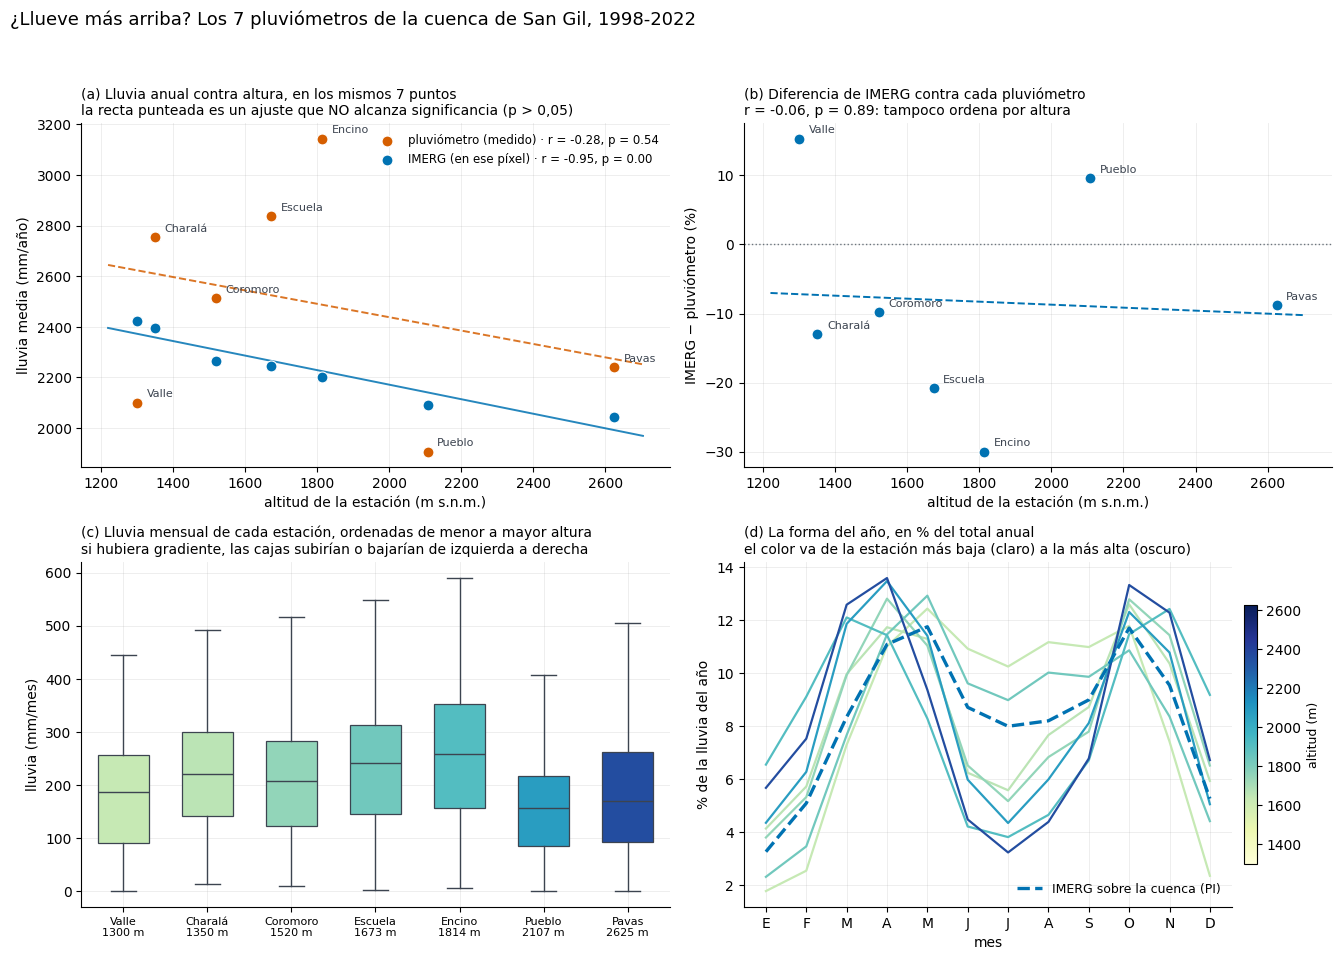

In [16]:
# paleta apta para daltonismo (Okabe-Ito); pluviómetro = naranja, IMERG = azul, como en el resto
AZUL_P, NARANJA_P, GRIS_P = "#0072B2", "#D55E00", "#6C757D"
MES_INI = ["E", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

fig, ax = plt.subplots(2, 2, figsize=(13.5, 9.6))

# --- (a) lo medido y lo estimado, contra la altura, en los mismos 7 puntos ---
alturas = np.linspace(gradiente.altitud.min() - 80, gradiente.altitud.max() + 80, 50)
for columna, etiqueta, color in [("p_pluvio", "pluviómetro (medido)", NARANJA_P),
                                 ("p_imerg", "IMERG (en ese píxel)", AZUL_P)]:
    r = stats.linregress(gradiente.altitud, gradiente[columna])
    ax[0, 0].scatter(gradiente.altitud, gradiente[columna], s=62, color=color, zorder=3,
                     edgecolor="white", linewidth=0.8,
                     label=f"{etiqueta} · r = {r.rvalue:+.2f}, p = {r.pvalue:.2f}")
    ax[0, 0].plot(alturas, r.intercept + r.slope * alturas, color=color, lw=1.4,
                  ls="--" if r.pvalue > 0.05 else "-", alpha=0.85)
for _, f in gradiente.iterrows():          # el nombre de cada estación, junto a su punto medido
    ax[0, 0].annotate(f.estacion.split(" ")[0], (f.altitud, f.p_pluvio), xytext=(7, 4),
                      textcoords="offset points", fontsize=8, color="#3C4450")
ax[0, 0].set_title("(a) Lluvia anual contra altura, en los mismos 7 puntos\n"
                   "la recta punteada es un ajuste que NO alcanza significancia (p > 0,05)",
                   fontsize=10, loc="left")
ax[0, 0].set_xlabel("altitud de la estación (m s.n.m.)"); ax[0, 0].set_ylabel("lluvia media (mm/año)")
ax[0, 0].legend(frameon=False, fontsize=8.5, loc="upper right")

# --- (b) ¿el error de IMERG depende de la altura? ---
r_sesgo = stats.linregress(gradiente.altitud, gradiente.sesgo_imerg_pct)
ax[0, 1].axhline(0, color=GRIS_P, lw=1, ls=":")
ax[0, 1].scatter(gradiente.altitud, gradiente.sesgo_imerg_pct, s=62, color=AZUL_P, zorder=3,
                 edgecolor="white", linewidth=0.8)
ax[0, 1].plot(alturas, r_sesgo.intercept + r_sesgo.slope * alturas, color=AZUL_P, lw=1.4, ls="--")
for _, f in gradiente.iterrows():
    ax[0, 1].annotate(f.estacion.split(" ")[0], (f.altitud, f.sesgo_imerg_pct), xytext=(7, 4),
                      textcoords="offset points", fontsize=8, color="#3C4450")
ax[0, 1].set_title(f"(b) Diferencia de IMERG contra cada pluviómetro\n"
                   f"r = {r_sesgo.rvalue:+.2f}, p = {r_sesgo.pvalue:.2f}: tampoco ordena por altura",
                   fontsize=10, loc="left")
ax[0, 1].set_xlabel("altitud de la estación (m s.n.m.)")
ax[0, 1].set_ylabel("IMERG − pluviómetro (%)")

# --- (c) cuánta lluvia mensual mide cada estación, ordenadas por altura ---
orden = gradiente.sort_values("altitud")
datos_caja = [pluvio_mes[c].dropna().values for c in orden.codigo]
caja = ax[1, 0].boxplot(datos_caja, patch_artist=True, widths=0.6, showfliers=False)
for parche, alt in zip(caja["boxes"], orden.altitud):
    tono = (alt - orden.altitud.min()) / (orden.altitud.max() - orden.altitud.min())
    parche.set(facecolor=plt.cm.YlGnBu(0.25 + 0.55 * tono), edgecolor="#3C4450", linewidth=0.9)
for pieza in ("medians", "whiskers", "caps"):
    for linea in caja[pieza]:
        linea.set(color="#3C4450", linewidth=1.0)
ax[1, 0].set_xticks(range(1, len(orden) + 1),
                    [f"{e.split(' ')[0]}\n{a:.0f} m" for e, a in zip(orden.estacion, orden.altitud)],
                    fontsize=8)
ax[1, 0].set_title("(c) Lluvia mensual de cada estación, ordenadas de menor a mayor altura\n"
                   "si hubiera gradiente, las cajas subirían o bajarían de izquierda a derecha",
                   fontsize=10, loc="left")
ax[1, 0].set_ylabel("lluvia (mm/mes)")

# --- (d) la forma del año, normalizada, coloreada por altura ---
norma = plt.Normalize(orden.altitud.min(), orden.altitud.max())
for _, f in orden.iterrows():
    ciclo_est = pluvio_mes[f.codigo].groupby(pluvio_mes.index.month).mean()
    ax[1, 1].plot(ciclo_est.index, 100 * ciclo_est / ciclo_est.sum(), lw=1.6,
                  color=plt.cm.YlGnBu(0.25 + 0.55 * norma(f.altitud)))
ciclo_imerg = comp["IMERG"].groupby(comp.index.month).mean()
ax[1, 1].plot(ciclo_imerg.index, 100 * ciclo_imerg / ciclo_imerg.sum(), lw=2.4, color=AZUL_P,
              ls="--", label="IMERG sobre la cuenca (PI)")
ax[1, 1].set_xticks(range(1, 13), MES_INI)
ax[1, 1].set_title("(d) La forma del año, en % del total anual\n"
                   "el color va de la estación más baja (claro) a la más alta (oscuro)",
                   fontsize=10, loc="left")
ax[1, 1].set_xlabel("mes"); ax[1, 1].set_ylabel("% de la lluvia del año")
ax[1, 1].legend(frameon=False, fontsize=9)
fig.colorbar(plt.cm.ScalarMappable(norm=norma, cmap="YlGnBu"), ax=ax[1, 1],
             shrink=0.75, pad=0.02).set_label("altitud (m)", fontsize=9)

for a in ax.flat:
    a.grid(alpha=0.25, lw=0.6)
    for lado in ("top", "right"):
        a.spines[lado].set_visible(False)
fig.suptitle("¿Llueve más arriba? Los 7 pluviómetros de la cuenca de San Gil, 1998-2022",
             fontsize=13, y=0.995, x=0.006, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.965])
plt.show()

In [17]:
# --- 1.6: lectura, con las cifras calculadas arriba ---
_miles = lambda x: f"{x:,.0f}".replace(",", " ")
_aj = ajustes.loc["pluviómetros (lo medido)"]
_ai = ajustes.loc["IMERG (en esos mismos puntos)"]
_pos = {v: _ajuste(pluvio_catalogo.loc[gradiente.codigo, v].values, gradiente.p_pluvio.values)["p"]
        for v in ("latitud", "longitud")}
_forma = pd.DataFrame({c: pluvio_mes[c].groupby(pluvio_mes.index.month).mean() for c in gradiente.codigo})
_forma = 100 * _forma / _forma.sum()
_julio = _forma.loc[7].rename(index=dict(zip(gradiente.codigo, gradiente.estacion)))
_r_julio = stats.linregress(gradiente.altitud, _forma.loc[7].values)
_ciclo_pi = comp["IMERG"].groupby(comp.index.month).mean()
_julio_pi = 100 * _ciclo_pi[7] / _ciclo_pi.sum()
_mes_max = _forma.idxmax()
_sentido = "contrario al que predeciría más lluvia con la altura" if humedo.altitud < seco.altitud else "el que predeciría más lluvia con la altura"
display(Markdown(f"""
**Lo que se ve.**

1. **Los pluviómetros {"no muestran un gradiente significativo" if _aj.p > 0.05 else "sí muestran un gradiente"} con la
   altura**: R² = {_aj.R2:.2f} y p = {_aj.p:.2f} sobre los siete puntos. Otra variable de posición tampoco lo explica
   mejor: la latitud y la longitud dan p = {_pos['latitud']:.2f} y p = {_pos['longitud']:.2f}.
2. **El ejemplo que lo resume**: {humedo.estacion}, a {_miles(humedo.altitud)} m, mide {_miles(humedo.p_pluvio)} mm/año, y
   {seco.estacion}, a {_miles(seco.altitud)} m, mide {_miles(seco.p_pluvio)}: {_miles(abs(seco.altitud - humedo.altitud))} m de
   diferencia y un factor de **{humedo.p_pluvio / seco.p_pluvio:.1f}** en lluvia, en el sentido {_sentido}.
3. **IMERG sí impone un gradiente, y va hacia abajo**: {_ai.pendiente_por_100m:+.0f} mm/año por cada 100 m, con
   r = {_ai.r:.2f} y p = {_ai.p:.3f}, en los mismos siete puntos.
4. **El error de IMERG frente a cada pluviómetro tampoco ordena por altura** (panel b: r = {r_sesgo.rvalue:+.2f},
   p = {r_sesgo.pvalue:.2f}). El error parece depender de qué estación es, no de a qué altura está.
5. **La forma del año es parecida en todas, pero no idéntica** (panel d): todas las estaciones e IMERG son bimodales,
   con dos temporadas húmedas y un veranillo a mitad de año.
   - **La profundidad del veranillo varía**: julio concentra desde el {_julio.min():.1f} % del año en {_julio.idxmin()}
     hasta el {_julio.max():.1f} % en {_julio.idxmax()}. La relación con la altura (r = {_r_julio.rvalue:+.2f},
     p = {_r_julio.pvalue:.2f}) {"no alcanza significancia: queda como indicio" if _r_julio.pvalue > 0.05 else "es significativa"}.
   - **IMERG** le asigna a julio el {_julio_pi:.1f} % del año, más que {int((_julio < _julio_pi).sum())} de los
     {len(_julio)} pluviómetros.
   - **El mes del máximo**: {int(_mes_max.between(1, 6).sum())} estaciones lo ponen en la primera mitad del año y
     {int(_mes_max.between(7, 12).sum())} en la segunda; IMERG, en {MESES_LARGOS[_ciclo_pi.idxmax() - 1]}.
"""))


**Lo que se ve.**

1. **Los pluviómetros no muestran un gradiente significativo con la
   altura**: R² = 0.08 y p = 0.54 sobre los siete puntos. Otra variable de posición tampoco lo explica
   mejor: la latitud y la longitud dan p = 0.80 y p = 0.47.
2. **El ejemplo que lo resume**: Encino, a 1 814 m, mide 3 143 mm/año, y
   Pueblo Viejo, a 2 107 m, mide 1 906: 293 m de
   diferencia y un factor de **1.6** en lluvia, en el sentido contrario al que predeciría más lluvia con la altura.
3. **IMERG sí impone un gradiente, y va hacia abajo**: -29 mm/año por cada 100 m, con
   r = -0.95 y p = 0.001, en los mismos siete puntos.
4. **El error de IMERG frente a cada pluviómetro tampoco ordena por altura** (panel b: r = -0.06,
   p = 0.89). El error parece depender de qué estación es, no de a qué altura está.
5. **La forma del año es parecida en todas, pero no idéntica** (panel d): todas las estaciones e IMERG son bimodales,
   con dos temporadas húmedas y un veranillo a mitad de año.
   - **La profundidad del veranillo varía**: julio concentra desde el 3.2 % del año en Pavas Las
     hasta el 10.3 % en Valle de San Jose. La relación con la altura (r = -0.65,
     p = 0.11) no alcanza significancia: queda como indicio.
   - **IMERG** le asigna a julio el 8.0 % del año, más que 5 de los
     7 pluviómetros.
   - **El mes del máximo**: 5 estaciones lo ponen en la primera mitad del año y
     2 en la segunda; IMERG, en mayo.


**Por qué desconfiar del gradiente de IMERG.** Una correlación tan alta sobre siete puntos no
significa que el satélite haya detectado un patrón físico: su campo de lluvia es espacialmente muy suave y
las estaciones están repartidas a lo largo de esa suavidad. IMERG estima sobre celdas de 122 km²; dentro de
una sola caben laderas enteras con climas distintos. El gradiente que muestra puede ser real o el
resultado de interpolar sobre una topografía que el algoritmo no resuelve.

**Qué se puede concluir y qué no.** No se puede concluir que no exista efecto orográfico en esta cuenca:
siete puntos son muy pocos, ninguno está en la parte más alta de la cuenca, y los datos del IDEAM vienen
marcados como preliminares. Lo que sí se puede concluir es más modesto y más útil: **con la información
disponible, la altura no sirve para predecir cuánto llueve en un punto de esta cuenca**, y cualquier modelo
que reparta la lluvia por bandas de altura estaría apoyándose en un supuesto que estos datos no sostienen.

**Consecuencia para el trabajo.** Refuerza la regla 11: como los pluviómetros y el satélite no coinciden
en cómo se reparte la lluvia en el espacio, se siguen reportando las dos fuentes en paralelo, con PL como
referencia cuando haya que escoger.

### 1.7 ¿Alcanza con quitarle a Encino sus tres años anómalos?

En 1.6 quedó una duda pendiente: Encino es, por lejos, la estación más lluviosa de la red, y su tramo
2016-2018 se ve sospechoso —2017 llega a 6 695 mm, más del doble de un año típico—. Antes de dar por
buena esa sospecha conviene hacer la prueba más simple: recalcular la media de Encino sin esos tres años
y ver si, al quitarlos, deja de ser un valor atípico.

Se repite la figura de `scripts/10_estaciones_subcuencas.py` —el mapa del DEM con las subcuencas
Nemizaque (Pienta) y Puente Llano (Taquiza) resaltadas y las 7 estaciones ubicadas, y el perfil de lluvia
anual contra altitud— pero con la precipitación de Encino recalculada excluyendo 2016, 2017 y 2018. El
perfil muestra las dos versiones de Encino, la original y la corregida, unidas por una flecha, para ver
cuánto se mueve el punto.

Encino, con todo el período:        3 446 mm/año (294 meses)
Encino, sin 2016-2017-2018:         3 192 mm/año (258 meses)
Diferencia: 255 mm/año, un 7.4 % menos

Las 7 estaciones dentro de la cuenca, con Encino ya corregida:
                etiqueta  altitud  p_anual_original  p_anual         nombre_subcuenca
       Valle de San Jose   1300.0            2174.0   2174.0  San Gil (Fonce, salida)
                 Charalá   1350.0            2697.0   2697.0           Merida (Fonce)
                Coromoro   1520.0            2512.0   2512.0   Puente Llano (Taquiza)
Escuela Agricola Mogotes   1673.0            2839.0   2839.0 Puente Cabra (Mogoticos)
                  Encino   1814.0            3446.0   3192.0       Nemizaque (Pienta)
            Pueblo Viejo   2107.0            1570.0   1570.0   Puente Llano (Taquiza)
               Pavas Las   2625.0            2171.0   2171.0   Puente Llano (Taquiza)

Pendiente altitudinal, con Encino SIN corregir: -394 mm/año por 1000 m (r = -0.31, p =

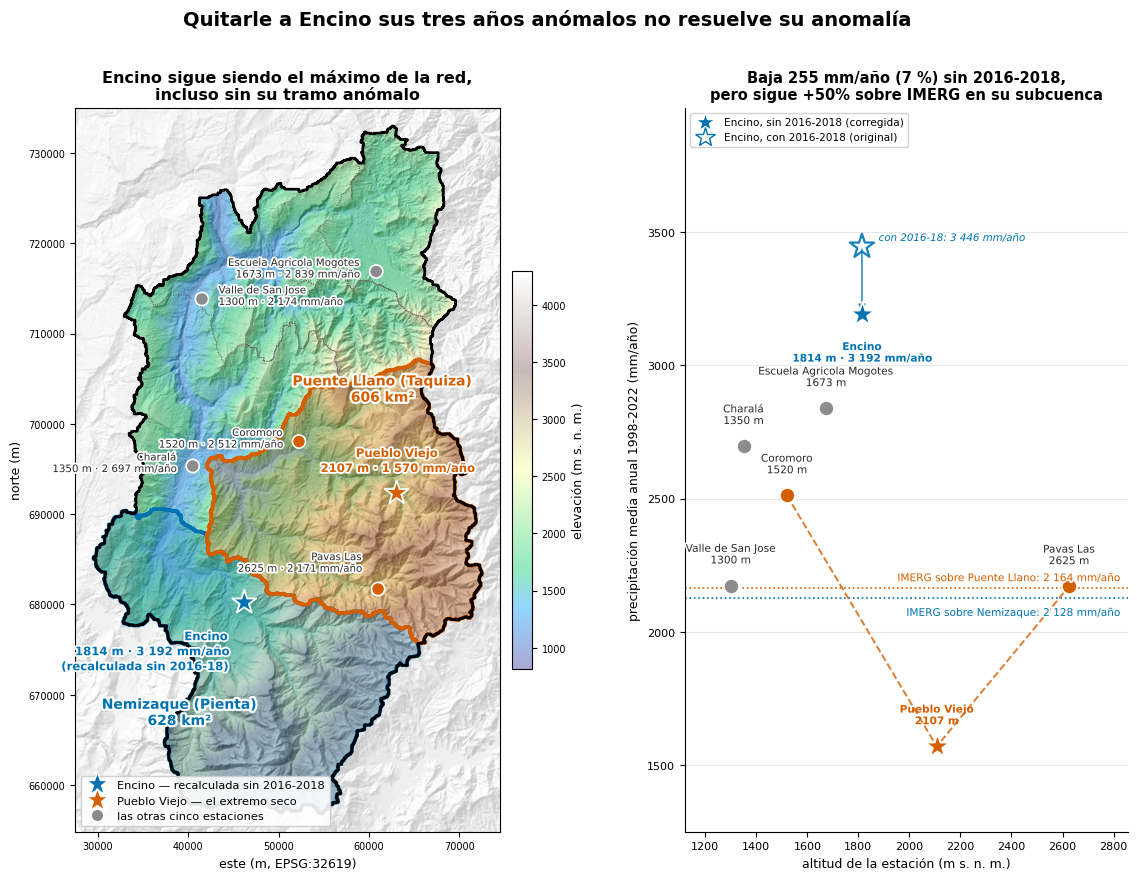


Figura: C:\Users\juanp\OneDrive\Escritorio\Proyectos\U\Hidrologia\Tarea 1 - Analisis de Cuenca\reporte\figuras\encino_sin_tramo_anomalo.png


In [18]:
# --- 1.7: se repite la figura de scripts/10_estaciones_subcuencas.py, pero recalculando ENCINO
# sin sus tres años anómalos (2016-2018; ver 1.6). El relieve (dem_z) viene de la celda de datos.

COD_ENCINO, COD_PUEBLO_VIEJO = 24020040, 24020230
SUBCUENCA_ENCINO = 24027030             # Nemizaque, río Pienta
SUBCUENCA_PUEBLO_VIEJO = 24027050       # Puente Llano, río Taquiza
ANIOS_ANOMALOS_ENCINO = [2016, 2017, 2018]

AZUL, NARANJA, GRIS, OTRAS = "#0072B2", "#D55E00", "#6B7280", "#8C8C8C"


def miles(x):
    # separador de miles con espacio (estilo del proyecto)
    return f"{x:,.0f}".replace(",", " ")


# dónde va el rótulo de cada subcuenca en el mapa (coordenadas del DEM, EPSG:32619); se fija a mano
# porque el centroide de Puente Llano cae encima de Pueblo Viejo y el texto tapaba el punto
ROTULO_SUBCUENCA = {SUBCUENCA_ENCINO: (39000, 668000), SUBCUENCA_PUEBLO_VIEJO: (61500, 703800)}

# hacia dónde sale la etiqueta de cada estación en el mapa: (dx, dy) en puntos, alineación; se fija a
# mano porque con siete estaciones (dos muy juntas) es más limpio que calcularlo. Se indexa por código,
# no por nombre, porque el nombre ya viene limpiado (título) desde la celda de carga de datos.
ETIQUETA_ESTACION = {
    24020040: (-12, -20, "right", "top"),        # Encino
    24020220: (-12, 11, "right", "bottom"),       # Pavas Las
    24020230: (0, 13, "center", "bottom"),        # Pueblo Viejo
    24020120: (-12, 2, "right", "center"),        # Coromoro
    24025050: (-12, 2, "right", "center"),        # Charalá
    24020080: (12, 2, "left", "center"),          # Valle de San José
    24025040: (-12, 2, "right", "center"),        # Escuela Agrícola Mogotes
}

# --- precipitación anual media de cada pluviómetro dentro de la cuenca ---
# misma regla que en 1.2 y en scripts/10_estaciones_subcuencas.py: media mensual (sin rellenar meses faltantes) x 12; no exige
# años completos, por eso no coincide exactamente con la mediana de años completos que se usó para
# encontrar el tramo anómalo en 1.6.
# "original" = la serie cruda, con el tramo; "corregida" = sin 2016-2018, que es la que usa el proyecto
p_anual_original = pluvio_mes_crudo[PLUVIO_EN_CUENCA].mean() * 12

pluvio_mes_corregido = pluvio_mes_crudo.copy()
pluvio_mes_corregido.loc[pluvio_mes_corregido.index.year.isin(ANIOS_ANOMALOS_ENCINO), COD_ENCINO] = np.nan
p_anual_corregido = pluvio_mes_corregido[PLUVIO_EN_CUENCA].mean() * 12

# se recalculan aquí los números adelantados en el encargo, para dejar constancia de que salen del dato
p_orig, p_corr = p_anual_original[COD_ENCINO], p_anual_corregido[COD_ENCINO]
n_orig = int(pluvio_mes_crudo[COD_ENCINO].notna().sum())
n_corr = int(pluvio_mes_corregido[COD_ENCINO].notna().sum())
print(f"Encino, con todo el período:        {miles(p_orig)} mm/año ({n_orig} meses)")
print(f"Encino, sin 2016-2017-2018:         {miles(p_corr)} mm/año ({n_corr} meses)")
print(f"Diferencia: {miles(p_orig - p_corr)} mm/año, un {(1 - p_corr / p_orig) * 100:.1f} % menos\n")

# --- catálogo de las 7 estaciones dentro de la cuenca, con el valor corregido de Encino ---
est = pluvio_catalogo.loc[PLUVIO_EN_CUENCA, ["nombre", "altitud", "latitud", "longitud"]].copy()
est["etiqueta"] = est["nombre"]
est["p_anual"] = p_anual_corregido               # el valor "vigente": el que se dibuja en el mapa
est["p_anual_original"] = p_anual_original       # se guarda aparte solo para compararlo en el perfil
est = gpd.GeoDataFrame(est, geometry=gpd.points_from_xy(est.longitud, est.latitud), crs=4326)


# ¿en qué subcuenca cae cada estación? como están anidadas, se toma la más pequeña que la contiene
def subcuenca_de(punto):
    dentro = cuencas[cuencas.contains(punto)].sort_values("area_km2")
    return dentro.iloc[0].gauge_id if len(dentro) else np.nan


est["subcuenca"] = est.geometry.apply(subcuenca_de)
est["nombre_subcuenca"] = est.subcuenca.map(cuencas.set_index("gauge_id").nombre)


def color_de(fila):
    if fila.subcuenca == SUBCUENCA_ENCINO:
        return AZUL
    if fila.subcuenca == SUBCUENCA_PUEBLO_VIEJO:
        return NARANJA
    return OTRAS


est["color"] = est.apply(color_de, axis=1)
est["extrema"] = est.index.isin([COD_ENCINO, COD_PUEBLO_VIEJO])

print("Las 7 estaciones dentro de la cuenca, con Encino ya corregida:")
tabla = est[["etiqueta", "altitud", "p_anual_original", "p_anual", "nombre_subcuenca"]].sort_values("altitud")
print(tabla.round(0).to_string(index=False))

# --- ¿cambia el (ya débil) gradiente altitudinal de la red al corregir Encino? se compara con y sin ---
r_antes = stats.linregress(est.altitud, est.p_anual_original)
r_despues = stats.linregress(est.altitud, est.p_anual)
print(f"\nPendiente altitudinal, con Encino SIN corregir: {r_antes.slope * 1000:+.0f} mm/año por 1000 m "
      f"(r = {r_antes.rvalue:+.2f}, p = {r_antes.pvalue:.2f})")
print(f"Pendiente altitudinal, con Encino CORREGIDA:    {r_despues.slope * 1000:+.0f} mm/año por 1000 m "
      f"(r = {r_despues.rvalue:+.2f}, p = {r_despues.pvalue:.2f})")

# --- lo que IMERG estima para las dos subcuencas donde caen Encino y Pueblo Viejo ---
anio_imerg = imerg.periodo.dt.year
p_sub = imerg.assign(anio=anio_imerg).groupby(["id_estacion", "anio"]).p_imerg_mm.sum().groupby("id_estacion").mean()
p_imerg_encino = p_sub[SUBCUENCA_ENCINO]
print(f"\nIMERG sobre Nemizaque (la subcuenca de Encino): {miles(p_imerg_encino)} mm/año")
print(f"Encino SIN corregir queda {p_orig / p_imerg_encino - 1:+.0%} sobre ese valor; "
      f"CORREGIDA queda {p_corr / p_imerg_encino - 1:+.0%}")

# ------------------------------------------------------------------ el relieve, de la celda de datos
madre = cuencas[cuencas.gauge_id == ID_PRINCIPAL]
z, tr, crs_dem = dem_z, dem_tr, dem_crs
madre_utm = madre.to_crs(crs_dem)

fuera = geometry_mask(madre_utm.geometry, out_shape=z.shape, transform=tr)      # True = fuera de la cuenca
z_cuenca = np.where(fuera, np.nan, z)
res = abs(tr.a)
ext = (tr.c, tr.c + tr.a * z.shape[1], tr.f + tr.e * z.shape[0], tr.f)
sombra = LightSource(azdeg=315, altdeg=45).hillshade(np.nan_to_num(z, nan=np.nanmean(z)),
                                                     vert_exag=2, dx=res, dy=res)

# ------------------------------------------------------------------ figura: mapa + perfil altitud-lluvia
fig = plt.figure(figsize=(14.5, 9.4))
rejilla = fig.add_gridspec(1, 2, width_ratios=[1.35, 1], wspace=0.16)
mapa = fig.add_subplot(rejilla[0, 0])
perfil = fig.add_subplot(rejilla[0, 1])

# --- panel izquierdo: relieve y subcuencas ---
mapa.imshow(np.where(fuera, sombra, np.nan), cmap="gray", extent=ext, alpha=0.3, vmin=0, vmax=1)
mapa.imshow(sombra * ~fuera + np.where(fuera, np.nan, 0), cmap="gray", extent=ext, vmin=0, vmax=1)
relieve = mapa.imshow(z_cuenca, cmap="terrain", extent=ext, alpha=0.42,
                      vmin=np.nanpercentile(z_cuenca, 0.5) - 400, vmax=np.nanmax(z_cuenca))

cuencas_utm = cuencas.to_crs(crs_dem)
otras = cuencas_utm[~cuencas_utm.gauge_id.isin([ID_PRINCIPAL, SUBCUENCA_ENCINO, SUBCUENCA_PUEBLO_VIEJO])]
otras.boundary.plot(ax=mapa, color="0.35", lw=0.7, linestyle=":", zorder=3)

for gid, color in [(SUBCUENCA_ENCINO, AZUL), (SUBCUENCA_PUEBLO_VIEJO, NARANJA)]:
    sub = cuencas_utm[cuencas_utm.gauge_id == gid]
    sub.plot(ax=mapa, color=color, alpha=0.26, zorder=3)
    sub.boundary.plot(ax=mapa, color=color, lw=2.6, zorder=4)
    fila = sub.iloc[0]
    mapa.annotate(f"{fila.nombre}\n{fila.area_km2:.0f} km²", ROTULO_SUBCUENCA[gid],
                  ha="center", va="center", fontsize=10, weight="bold", color=color, zorder=6,
                  path_effects=[pe.withStroke(linewidth=3.2, foreground="white")])

madre_utm.boundary.plot(ax=mapa, color="k", lw=1.9, zorder=5)

est_utm = est.to_crs(crs_dem)
normales = est_utm[~est_utm.extrema]
extremas = est_utm[est_utm.extrema]
mapa.scatter(normales.geometry.x, normales.geometry.y, s=90, c=normales.color,
             edgecolor="white", linewidth=1.2, zorder=7)
mapa.scatter(extremas.geometry.x, extremas.geometry.y, s=330, c=extremas.color, marker="*",
             edgecolor="white", linewidth=1.3, zorder=8)

for cod, e in est_utm.iterrows():
    dx, dy, ha, va = ETIQUETA_ESTACION[cod]
    if cod == COD_ENCINO:
        texto = f"{e.etiqueta}\n{e.altitud:.0f} m · {miles(e.p_anual)} mm/año\n(recalculada sin 2016-18)"
    else:
        texto = f"{e.etiqueta}\n{e.altitud:.0f} m · {miles(e.p_anual)} mm/año"
    mapa.annotate(texto, (e.geometry.x, e.geometry.y),
                  xytext=(dx, dy), textcoords="offset points", ha=ha, va=va,
                  fontsize=8.4 if e.extrema else 7.4,
                  weight="bold" if e.extrema else "normal",
                  color=e.color if e.extrema else "#2B2B2B", zorder=9,
                  path_effects=[pe.withStroke(linewidth=2.6, foreground="white")])

mapa.set_xlim(ext[0], ext[1])
mapa.set_ylim(ext[2], ext[3])
mapa.set_xlabel(f"este (m, {crs_dem.to_string()})", fontsize=9)
mapa.set_ylabel("norte (m)", fontsize=9)
mapa.ticklabel_format(style="plain")
mapa.tick_params(labelsize=7)
barra = fig.colorbar(relieve, ax=mapa, shrink=0.55, pad=0.02)
barra.set_label("elevación (m s. n. m.)", fontsize=9)
barra.ax.tick_params(labelsize=7)

mapa.legend(handles=[
    Line2D([], [], marker="*", color="none", markerfacecolor=AZUL, markeredgecolor="white",
           markersize=17, label="Encino — recalculada sin 2016-2018"),
    Line2D([], [], marker="*", color="none", markerfacecolor=NARANJA, markeredgecolor="white",
           markersize=17, label="Pueblo Viejo — el extremo seco"),
    Line2D([], [], marker="o", color="none", markerfacecolor=OTRAS, markeredgecolor="white",
           markersize=9, label="las otras cinco estaciones"),
], loc="lower left", fontsize=8.2, framealpha=0.9)
mapa.set_title("Encino sigue siendo el máximo de la red,\nincluso sin su tramo anómalo",
               fontsize=11.5, weight="semibold")

# --- panel derecho: lluvia contra altitud; Encino se muestra dos veces, original y corregida ---
todas_p = pd.concat([est.p_anual, est.p_anual_original])
perfil.set_xlim(est.altitud.min() - 180, est.altitud.max() + 230)
perfil.set_ylim(todas_p.min() - 320, todas_p.max() + 520)

for cod, e in est.sort_values("altitud").iterrows():
    perfil.scatter(e.altitud, e.p_anual, s=340 if e.extrema else 120, c=e.color,
                   marker="*" if e.extrema else "o", edgecolor="white", linewidth=1.3, zorder=4)
    if cod != COD_ENCINO:                                 # la de Encino se anota más abajo, junto a la flecha
        perfil.annotate(f"{e.etiqueta}\n{e.altitud:.0f} m",
                        (e.altitud, e.p_anual), textcoords="offset points", xytext=(0, 16),
                        ha="center", fontsize=7.6,
                        weight="bold" if e.extrema else "normal",
                        color=e.color if e.extrema else "#2B2B2B",
                        path_effects=[pe.withStroke(linewidth=2.4, foreground="white")])

# Encino corregida: se anota con el mismo estilo, pero hacia abajo para dejar sitio arriba a la original
e_encino = est.loc[COD_ENCINO]
perfil.annotate(f"{e_encino.etiqueta}\n{e_encino.altitud:.0f} m · {miles(e_encino.p_anual)} mm/año",
                (e_encino.altitud, e_encino.p_anual), textcoords="offset points", xytext=(0, -34),
                ha="center", fontsize=7.6, weight="bold", color=AZUL,
                path_effects=[pe.withStroke(linewidth=2.4, foreground="white")])

# Encino sin corregir: marcador hueco, unido al corregido con una flecha fina, para ver que casi no se mueve
perfil.scatter(e_encino.altitud, e_encino.p_anual_original, s=340, facecolor="none",
               edgecolor=AZUL, linewidth=1.6, marker="*", zorder=3, alpha=0.9)
perfil.annotate("", xy=(e_encino.altitud, e_encino.p_anual), xytext=(e_encino.altitud, e_encino.p_anual_original),
                arrowprops=dict(arrowstyle="-|>", color=AZUL, lw=1.2, alpha=0.8), zorder=3)
perfil.annotate(f"con 2016-18: {miles(e_encino.p_anual_original)} mm/año",
                (e_encino.altitud, e_encino.p_anual_original), textcoords="offset points",
                xytext=(12, 4), ha="left", fontsize=7.4, color=AZUL, style="italic", zorder=4,
                path_effects=[pe.withStroke(linewidth=2.2, foreground="white")])

# las tres estaciones de Puente Llano, unidas para que se vea el hundimiento de Pueblo Viejo (como en 31)
taquiza = est[est.subcuenca == SUBCUENCA_PUEBLO_VIEJO].sort_values("altitud")
perfil.plot(taquiza.altitud, taquiza.p_anual, color=NARANJA, lw=1.4, linestyle="--", zorder=3, alpha=0.8)

# lo que IMERG estima para cada una de las dos subcuencas
nombres_sub = cuencas.set_index("gauge_id").nombre
for gid, color, dy in [(SUBCUENCA_ENCINO, AZUL, -13), (SUBCUENCA_PUEBLO_VIEJO, NARANJA, 5)]:
    perfil.axhline(p_sub[gid], color=color, lw=1.2, linestyle=":", zorder=2)
    perfil.annotate(f"IMERG sobre {nombres_sub[gid].split(' (')[0]}: {miles(p_sub[gid])} mm/año",
                    (perfil.get_xlim()[1], p_sub[gid]), xytext=(-5, dy),
                    textcoords="offset points", ha="right", fontsize=7.6, color=color, zorder=5,
                    path_effects=[pe.withStroke(linewidth=2.4, foreground="white")])

perfil.set_xlabel("altitud de la estación (m s. n. m.)", fontsize=9)
perfil.set_ylabel("precipitación media anual 1998-2022 (mm/año)", fontsize=9)
perfil.grid(axis="y", color="#E5E7EB", linewidth=0.8)
perfil.set_axisbelow(True)
for lado in ("top", "right"):
    perfil.spines[lado].set_visible(False)
perfil.tick_params(labelsize=8)
perfil.legend(handles=[
    Line2D([], [], marker="*", color="none", markerfacecolor=AZUL, markeredgecolor="white",
           markersize=15, label="Encino, sin 2016-2018 (corregida)"),
    Line2D([], [], marker="*", color="none", markerfacecolor="none", markeredgecolor=AZUL,
           markersize=15, label="Encino, con 2016-2018 (original)"),
], loc="upper left", fontsize=7.6, framealpha=0.9)
perfil.set_title(f"Baja {miles(p_orig - p_corr)} mm/año ({(1 - p_corr / p_orig) * 100:.0f} %) "
                 f"sin 2016-2018,\npero sigue {p_corr / p_imerg_encino - 1:+.0%} sobre IMERG "
                 f"en su subcuenca",
                 fontsize=10.5, weight="semibold")

fig.suptitle("Quitarle a Encino sus tres años anómalos no resuelve su anomalía",
             fontsize=14, weight="bold", y=0.985)

OUT = RAIZ / "reporte/figuras"
fig.savefig(OUT / "encino_sin_tramo_anomalo.png", dpi=160, bbox_inches="tight")
plt.show()
print(f"\nFigura: {OUT / 'encino_sin_tramo_anomalo.png'}")

**Lo que se ve.** Quitar 2016-2018 baja a Encino de 3 446 a 3 192 mm/año: un recorte de 255 mm/año, un
7 %. Es un cambio real pero chico frente a lo que separa a Encino del resto de la red: sigue siendo, con
margen amplio, la estación más lluviosa de las siete —la que le sigue, Escuela Agrícola Mogotes, mide
2 839 mm/año, 353 mm/año menos que la Encino ya corregida— y sigue quedando cerca de 50 % por encima de
lo que IMERG estima para su propia subcuenca, Nemizaque (2 128 mm/año); sin corregir estaba 62 % por
encima. El gradiente altitudinal de la red, que en 1.6 ya salía plano y no significativo, tampoco se
mueve de forma relevante al corregir Encino: pasa de −394 a −402 mm/año por cada 1 000 m, y sigue sin
alcanzar significancia (p > 0.4 en los dos casos).

**La lectura correcta no es que 2016-2018 fuera el problema de Encino.** Es que Encino mide de más
durante todo el período de registro, no solo en esos tres años: quitar el tramo más extremo corrige una
fracción menor del exceso (7 % de la lluvia anual) y deja casi intacta la distancia frente al resto de
la red y frente a IMERG. Descartar 2016-2018 habría sido una corrección cómoda pero insuficiente. La
estación queda marcada como sospechosa en el conjunto completo del dato, no solo en un tramo puntual, y
con lo disponible no hay forma de saber cuánto de esos 3 192 mm/año restantes es lluvia real y cuánto
sigue siendo un problema del pluviómetro.

### 1.8 La evapotranspiración potencial (ETP): la de CAMELS-COL y la calculada por el proyecto

**Qué es y de dónde sale.** La ETP es cuánta agua evaporaría y transpiraría una superficie de pasto bien
regada con el clima del día; no se mide, se calcula, y no es la evapotranspiración real de la cuenca.
CAMELS-COL publica una ETP diaria (columna `poten_evapo`, aquí `etp`) y en su artículo dice cómo la
calculó (Jimenez et al., 2025, ecuación 1): con el método de **Hargreaves y Samani (1985)**, que solo
necesita la temperatura, usando la mínima y la máxima de MSWX,

$$\mathrm{ETP} = 0.0023 \; R_a \; (T + 17.8) \; \sqrt{T_{máx} - T_{mín}} \qquad [\mathrm{mm/día}]$$

donde $T = (T_{máx} + T_{mín})/2$ en °C y $R_a$ es la radiación que llega al tope de la atmósfera, que
depende solo de la latitud y del día del año. $R_a$ se calcula con las ecuaciones 21 a 25 de **FAO-56**
(Allen et al., 1998; la edición en español de 2006 es la que cita CAMELS-COL) y se pasa de MJ m⁻² día⁻¹ a
mm/día multiplicando por 0.408.

**Lo que hizo el proyecto** (`scripts/06b_etp_hargreaves.py`): aplicar exactamente esa fórmula dos veces,
una con la temperatura de **ERA5-Land**, la del proyecto, y otra con la de **MSWX**, la misma que usó
CAMELS-COL. La latitud es la del centroide del polígono de San Gil (6.26° N). La segunda cuenta sirve de
control: si CAMELS-COL aplicó bien su fórmula, su ETP y la de Hargreaves con MSWX deberían coincidir.

Referencias:
- Jimenez, D. A., et al. (2025). CAMELS-COL: A Large-Sample Hydrometeorological Dataset for Colombia.
  *Earth Syst. Sci. Data Discuss.* https://doi.org/10.5194/essd-2025-200
- Hargreaves, G. H., y Samani, Z. A. (1985). Reference crop evapotranspiration from temperature.
  *Applied Engineering in Agriculture*, 1(2), 96–99. https://doi.org/10.13031/2013.26773
- Allen, R. G., Pereira, L. S., Raes, D., y Smith, M. (1998). *Crop evapotranspiration: Guidelines for
  computing crop water requirements* (FAO Irrigation and Drainage Paper 56). FAO, Roma. Edición en
  español: *Evapotranspiración del cultivo* (Estudio FAO Riego y Drenaje 56), 2006.

In [19]:
# --- 1.8: las tres ETP, de diaria a mensual con la regla del proyecto (acumulado del mes) ---
ETP_FUENTES = {"CAMELS-COL (publicada)": "etp_camels",
               "Hargreaves con MSWX": "etp_mswx",
               "Hargreaves con ERA5-Land": "etp_era5land"}
etp_mensual = pd.DataFrame({nombre: a_mensual_del_periodo(etp_diaria[col], "sum")
                            for nombre, col in ETP_FUENTES.items()})
etp_comun = etp_mensual.dropna()          # los meses en que las tres tienen dato, para compararlas

comparacion_etp = pd.DataFrame({
    "meses con dato": etp_mensual.notna().sum(),
    f"ETP media en los {len(etp_comun)} meses comunes (mm/año)": etp_comun.mean() * 12,
    "cociente CAMELS-COL / esta (mediana mensual)": etp_comun.rdiv(etp_comun["CAMELS-COL (publicada)"], axis=0).median(),
    "correlación mensual con CAMELS-COL (Pearson)": etp_comun.corr()["CAMELS-COL (publicada)"],
})
_c = etp_comun["CAMELS-COL (publicada)"] / etp_comun["Hargreaves con MSWX"]
print(f"{len(etp_comun)} meses con las tres ETP")
print(f"CAMELS-COL / Hargreaves con MSWX, mes a mes: entre {_c.min():.2f} y {_c.max():.2f}")
print(f"ERA5-Land contra MSWX, ambas con Hargreaves: {(etp_comun['Hargreaves con ERA5-Land'] / etp_comun['Hargreaves con MSWX']).mean() * 100 - 100:+.1f} % en promedio, "
      f"r = {etp_comun['Hargreaves con ERA5-Land'].corr(etp_comun['Hargreaves con MSWX']):.2f}")
# lo que CAMELS-COL daría si Ra se hubiera dejado en MJ m⁻² día⁻¹, sin pasarla a mm/día: una hipótesis
# sobre el origen del factor, que se comprueba en vez de suponerla
_sin_convertir = etp_comun["Hargreaves con MSWX"] / 0.408
print(f"con Ra sin convertir a mm/día, CAMELS-COL / Hargreaves-MSWX sería {(etp_comun['CAMELS-COL (publicada)'] / _sin_convertir).median():.2f}")

# para juzgar cuál es plausible: la lluvia y el caudal de esos mismos meses (mm/año)
_pq = pd.DataFrame({"PL": variables_resumen["PL (mm/mes)"],
                    "Q": a_mensual_del_periodo(san_gil_diario["caudal_mm"], "sum")}).reindex(etp_comun.index).dropna()
print(f"en los {len(_pq)} meses con PL y Q: PL {_pq.PL.mean() * 12:.0f} mm/año, Q {_pq.Q.mean() * 12:.0f} mm/año, "
      f"PL − Q {(_pq.PL - _pq.Q).mean() * 12:.0f} mm/año")
comparacion_etp.round(2)

262 meses con las tres ETP
CAMELS-COL / Hargreaves con MSWX, mes a mes: entre 2.70 y 2.84
ERA5-Land contra MSWX, ambas con Hargreaves: +1.3 % en promedio, r = 0.88
con Ra sin convertir a mm/día, CAMELS-COL / Hargreaves-MSWX sería 1.12


en los 262 meses con PL y Q: PL 2517 mm/año, Q 1331 mm/año, PL − Q 1186 mm/año


,meses con dato,ETP media en los 262 meses comunes (mm/año),cociente CAMELS-COL / esta (mediana mensual),correlación mensual con CAMELS-COL (Pearson)
CAMELS-COL (publicada),262,3421.79,1.00,1.00
Hargreaves con MSWX,262,1240.19,2.76,0.99
Hargreaves con ERA5-Land,300,1256.96,2.72,0.85


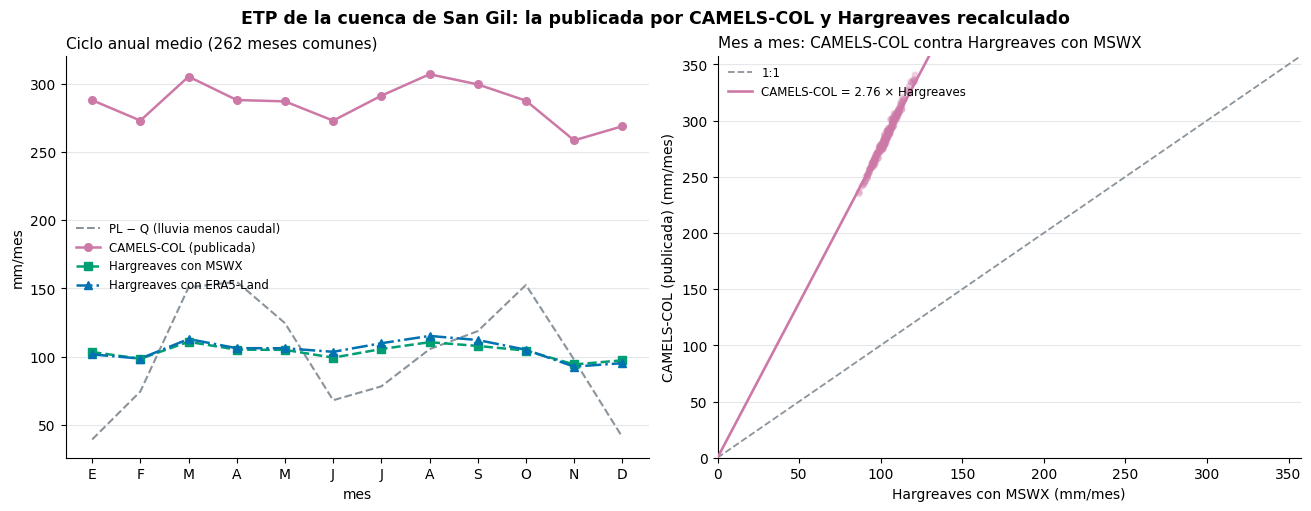

In [20]:
# --- 1.8 (figura): ciclo anual de las tres ETP y su relación mes a mes con CAMELS-COL ---
# Izquierda: promedio por mes calendario de los 262 meses comunes; se añade PL − Q (lluvia menos
# caudal) como referencia de cuánta agua queda disponible cada mes para evaporarse y transpirar.
# Derecha: dispersión mes a mes entre CAMELS-COL y Hargreaves con MSWX, con la recta 1:1 y la
# pendiente mediana del cociente, calculada aquí mismo (no escrita a mano).

ROSA, VERDE, AZUL, GRIS_ETP = "#CC79A7", "#009E73", "#0072B2", "#8B949B"
MES_INI = ["E", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

# color, estilo de línea y marcador: cada fuente se distingue por los tres a la vez, no solo por color
FUENTES_ETP = [("CAMELS-COL (publicada)", ROSA, "-", "o"),
               ("Hargreaves con MSWX", VERDE, "--", "s"),
               ("Hargreaves con ERA5-Land", AZUL, "-.", "^")]

fig, (izq, der) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# --- izquierda: ciclo anual medio ---
ciclo_etp = etp_comun.groupby(etp_comun.index.month).mean()
ciclo_pl_menos_q = (_pq.PL - _pq.Q).groupby(_pq.index.month).mean()

izq.plot(ciclo_pl_menos_q.index, ciclo_pl_menos_q.values, color=GRIS_ETP, lw=1.5, ls="--", zorder=2,
         label="PL − Q (lluvia menos caudal)")
for columna, color, estilo, marcador in FUENTES_ETP:
    izq.plot(ciclo_etp.index, ciclo_etp[columna], color=color, ls=estilo, marker=marcador, ms=5.5,
             lw=1.8, label=columna, zorder=3)
izq.set_xticks(range(1, 13), MES_INI)
izq.set_xlabel("mes")
izq.set_ylabel("mm/mes")
izq.grid(axis="y", color="#E5E7EB", lw=0.8)
izq.set_axisbelow(True)
for lado in ("top", "right"):
    izq.spines[lado].set_visible(False)
izq.legend(frameon=False, fontsize=8.5, loc="center left")
izq.set_title(f"Ciclo anual medio ({len(etp_comun)} meses comunes)", fontsize=11, loc="left")

# --- derecha: CAMELS-COL contra Hargreaves con MSWX, mes a mes ---
x = etp_comun["Hargreaves con MSWX"]
y = etp_comun["CAMELS-COL (publicada)"]
pendiente = (y / x).median()   # mediana del cociente mes a mes: el factor de la sección 1.8 de arriba

der.scatter(x, y, s=26, color=ROSA, alpha=0.35, edgecolor="none", zorder=2)
limite = max(x.max(), y.max()) * 1.05
recta = np.array([0, limite])
der.plot(recta, recta, color=GRIS_ETP, ls="--", lw=1.3, label="1:1", zorder=3)
der.plot(recta, pendiente * recta, color=ROSA, lw=1.9,
         label=f"CAMELS-COL = {pendiente:.2f} × Hargreaves", zorder=4)
der.set_xlim(0, limite)
der.set_ylim(0, limite)
der.set_xlabel("Hargreaves con MSWX (mm/mes)")
der.set_ylabel("CAMELS-COL (publicada) (mm/mes)")
der.grid(axis="y", color="#E5E7EB", lw=0.8)
der.set_axisbelow(True)
for lado in ("top", "right"):
    der.spines[lado].set_visible(False)
der.legend(frameon=False, fontsize=8.5, loc="upper left")
der.set_title("Mes a mes: CAMELS-COL contra Hargreaves con MSWX", fontsize=11, loc="left")

fig.suptitle("ETP de la cuenca de San Gil: la publicada por CAMELS-COL y Hargreaves recalculado",
             fontsize=12.5, fontweight="semibold")
plt.show()


**Lo que se ve.**

1. **La ETP de CAMELS-COL no cuadra con su propia fórmula.** Es 2.76 veces Hargreaves recalculado con las
   mismas temperaturas de MSWX, y el factor casi no cambia de un mes a otro (entre 2.70 y 2.84): los
   puntos de la derecha caen sobre una recta que pasa por el origen. Es la misma cuenta multiplicada por
   una constante. Dejar $R_a$ en MJ m⁻² día⁻¹, sin pasarla a mm, explicaría un factor de 2.45 y no de
   2.76 (quedaría 1.12), así que no es solo eso; la causa no se pudo identificar.
2. **El valor recalculado es el plausible.** Hargreaves da unos 1 240 a 1 257 mm/año, dentro del rango de
   1 200 a 1 400 mm/año que el mismo artículo de CAMELS-COL reporta para Colombia según el IDEAM. En el
   balance, la cuenca pierde PL − Q = 1 106 mm/año: menos que la ETP recalculada, como corresponde si la
   evapotranspiración real no supera a la potencial. Los 3 422 mm/año de CAMELS-COL superan incluso a
   la lluvia.
3. **Con MSWX o con ERA5-Land, Hargreaves da casi lo mismo** (+1.3 %, r = 0.88 mes a mes). ERA5-Land es
   más fría, pero tiene más amplitud diaria, y en la fórmula las dos cosas se compensan.
4. **PL − Q no es la evapotranspiración.** Mes a mes supera a la ETP en marzo-abril y en octubre, y cae
   muy por debajo en enero y diciembre: en las temporadas de lluvia la cuenca guarda agua, y en las
   secas la devuelve al río. Solo en el promedio anual se puede comparar con la ETP.

**Qué ETP se usa.** En todo el proyecto, **Hargreaves con ERA5-Land**. La de CAMELS-COL no se usa en
ningún cálculo.

**¿Está bien calculada $R_a$?** Una diferencia tan constante hace sospechar de $R_a$. Se comprobó de tres
formas. Las dos primeras están en `scripts/06b_etp_hargreaves.py`, que se detiene si fallan:

1. el ejemplo 8 de FAO-56 (20° S, 3 de septiembre: 32.2 MJ m⁻² día⁻¹) da lo mismo;
2. integrar minuto a minuto la radiación que llega al tope de la atmósfera da lo mismo que la fórmula, en
   la latitud de la cuenca y todo el año.

La tercera, abajo: despejar de la ETP de CAMELS-COL la $R_a$ que habrían tenido que usar, y compararla con
el máximo físicamente posible en esta latitud.

In [21]:
# --- la Ra que CAMELS-COL habría tenido que usar para obtener su ETP con la fórmula de Hargreaves ---
_d = san_gil_diario.reindex(etp_diaria.index)
_ok = etp_diaria["etp_camels"].notna() & (_d["t_max"] > _d["t_min"])
ra_implicita = etp_diaria.loc[_ok, "etp_camels"] / (0.0023 * ((_d.t_max + _d.t_min) / 2 + 17.8)[_ok]
                                                    * np.sqrt((_d.t_max - _d.t_min)[_ok]))
ra_nuestra = etp_diaria.loc[_ok, "ra_mm"]
ra_mensual = pd.DataFrame({"Ra implícita en CAMELS-COL (mm/día)": ra_implicita,
                           "Ra de FAO-56 (mm/día)": ra_nuestra}).groupby(ra_implicita.index.month).mean()
ra_mensual["cociente"] = ra_mensual.iloc[:, 0] / ra_mensual.iloc[:, 1]
print(f"Ra de FAO-56 en la cuenca: entre {etp_diaria.ra_mm.min():.1f} y {etp_diaria.ra_mm.max():.1f} mm/día "
      f"({etp_diaria.ra_mm.min() / 0.408:.1f} a {etp_diaria.ra_mm.max() / 0.408:.1f} MJ m⁻² día⁻¹)")
print(f"Ra implícita en CAMELS-COL: media {ra_implicita.mean():.1f} mm/día; "
      f"{(ra_implicita > etp_diaria.ra_mm.max() / 0.408).mean() * 100:.0f} % de los días supera incluso el máximo en MJ")
ra_mensual.round(2)

Ra de FAO-56 en la cuenca: entre 13.4 y 15.4 mm/día (32.8 a 37.7 MJ m⁻² día⁻¹)
Ra implícita en CAMELS-COL: media 40.2 mm/día; 86 % de los días supera incluso el máximo en MJ


,Ra implícita en CAMELS-COL (mm/día),Ra de FAO-56 (mm/día),cociente
fecha,,,
1,38.19,13.74,2.78
2,40.26,14.56,2.77
3,41.85,15.24,2.75
4,41.89,15.32,2.73
5,40.74,14.92,2.73
6,40.05,14.60,2.74
7,40.46,14.70,2.75
8,41.73,15.07,2.77
9,42.01,15.16,2.77


**Lo que se ve.** La $R_a$ del proyecto está bien. La que haría falta para reproducir la ETP de
CAMELS-COL, unos 40 mm/día, es imposible: en el tope de la atmósfera, a 6° N, nunca llega a más de
15.4 mm/día. Leída en MJ m⁻² día⁻¹, en vez de mm/día, también supera el máximo del año (37.7 MJ). Tiene la
misma forma estacional que la nuestra (el cociente es casi plano mes a mes), así que el problema no está
en la latitud ni en la fecha: es un factor de escala. La causa exacta no se puede saber desde afuera, pero
la ETP de CAMELS-COL no se puede obtener con la fórmula que declaran y con valores físicos de $R_a$.

## 2. Morfometría de la cuenca

Todo lo que sigue sale de los CSV que ya calcularon `scripts/13_morfometria.py` (forma de la
cuenca, perfil del cauce, curva hipsométrica, pendientes, orientaciones y tiempos de concentración) y
`scripts/15_cauce_desde_dem.py` (el cauce derivado directamente del DEM con pysheds, para comparar
contra la red de drenaje que publica CAMELS-COL). Esta sección solo carga esos productos y los dibuja;
no recalcula nada que no esté ya en esos CSV.

### 2.1 Qué forma tiene la cuenca

Tres índices de forma —Gravelius, factor de forma de Horton y razón de elongación— resumen qué tan
alargada es la cuenca de San Gil, comparados contra lo que publica CAMELS-COL para la misma cuenca.

In [22]:
# tabla de índices de forma: lo calculado con el polígono real de la cuenca contra lo que publica CAMELS-COL
filas_forma = ["área", "perímetro", "índice de Gravelius", "factor de forma de Horton", "razón de elongación"]
tabla_forma = morfometria.set_index("magnitud").loc[filas_forma, ["valor", "unidad", "publicado_camels"]].copy()
tabla_forma.columns = ["calculado", "unidad", "publicado por CAMELS-COL"]
tabla_forma[["calculado", "publicado por CAMELS-COL"]] = tabla_forma[["calculado", "publicado por CAMELS-COL"]].round(2)
display(tabla_forma)

# el perímetro de un círculo con la misma área que la cuenca (2·√(π·área)) mide cuánto se alarga la forma real
area_km2 = morfometria.set_index("magnitud").loc["área", "valor"]
perimetro_km = morfometria.set_index("magnitud").loc["perímetro", "valor"]
perimetro_circulo_km = 2 * np.sqrt(np.pi * area_km2)
exceso_pct = (perimetro_km / perimetro_circulo_km - 1) * 100

print(f"perímetro real: {perimetro_km:.1f} km  |  perímetro del círculo de área equivalente: "
      f"{perimetro_circulo_km:.1f} km  |  exceso: {exceso_pct:.0f} %")

,calculado,unidad,publicado por CAMELS-COL
magnitud,,,
área,2098.85,km²,2124.00
perímetro,338.49,km,340.46
índice de Gravelius,2.08,—,2.08
factor de forma de Horton,0.25,—,0.22
razón de elongación,0.57,—,NaN


perímetro real: 338.5 km  |  perímetro del círculo de área equivalente: 162.4 km  |  exceso: 108 %


**Lectura.** El índice de Gravelius (2.08) está lejos de 1, que sería una cuenca circular: la forma
real se aleja mucho del círculo. El factor de forma de Horton (0.25) va en la misma dirección —muy por
debajo de 1— y la razón de elongación (0.57, también menor cuanto más alargada es la cuenca) lo
confirma. El perímetro real, además, es un 108 % más largo que el de un círculo con la misma área. Los
tres índices y la comparación de perímetros coinciden: San Gil es una cuenca marcadamente alargada, no
compacta.

La consecuencia hidrológica es directa: en una cuenca alargada el agua de las distintas partes no llega
al mismo tiempo a la salida. Las crecidas que se generan en la cabecera y las que se generan cerca de la
salida quedan desfasadas entre sí, así que se amortiguan en vez de sumarse en un único pico de caudal,
como sí ocurriría en una cuenca compacta donde toda el agua converge casi al mismo tiempo.

### 2.2 Perfil del cauce principal

Elevación del cauce principal desde su cabecera hasta la salida en San Gil, extraída del DEM
(`scripts/13_morfometria.py`). La figura reproduce la de `scripts/14_figuras_morfometria.py`.

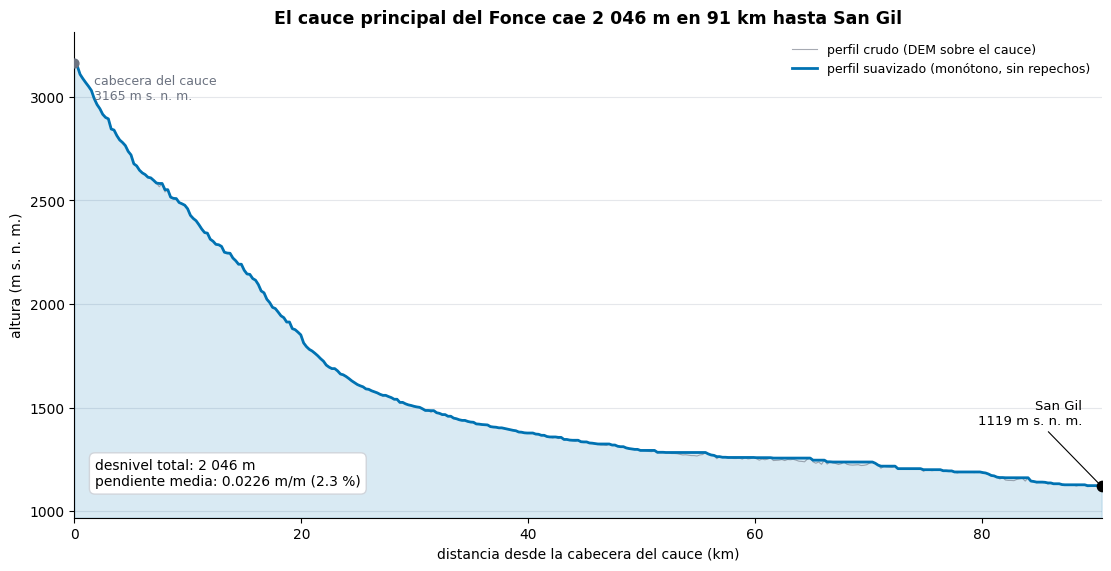

In [23]:
# paleta Okabe-Ito del proyecto (colorblind-safe); se reutiliza en el resto de la sección 2
AZUL, VERDE, NARANJA, ROSA, GRIS = "#0072B2", "#009E73", "#D55E00", "#CC79A7", "#6B7280"


def estilo_cartesiano(eje):
    """Rejilla horizontal tenue y sin bordes arriba/derecha; estilo compartido de las figuras de esta sección."""
    eje.grid(axis="y", color="#E5E7EB", linewidth=0.8, zorder=0)
    eje.set_axisbelow(True)
    for lado in ("top", "right"):
        eje.spines[lado].set_visible(False)


desnivel_m = perfil_cauce.altura_suavizada_m.iloc[0] - perfil_cauce.altura_suavizada_m.iloc[-1]
distancia_total_km = perfil_cauce.distancia_km.iloc[-1]
pendiente_media = desnivel_m / (distancia_total_km * 1000)
altura_san_gil = perfil_cauce.altura_suavizada_m.iloc[-1]

fig, ax = plt.subplots(figsize=(11, 5.6), constrained_layout=True)

base = perfil_cauce.altura_m.min() - 150
ax.fill_between(perfil_cauce.distancia_km, perfil_cauce.altura_suavizada_m, base, color=AZUL, alpha=0.15, zorder=1)
ax.plot(perfil_cauce.distancia_km, perfil_cauce.altura_m, color=GRIS, linewidth=0.8, alpha=0.6, zorder=2,
        label="perfil crudo (DEM sobre el cauce)")
ax.plot(perfil_cauce.distancia_km, perfil_cauce.altura_suavizada_m, color=AZUL, linewidth=2.0, zorder=3,
        label="perfil suavizado (monótono, sin repechos)")

ax.scatter([distancia_total_km], [altura_san_gil], color="k", zorder=4, s=55)
ax.annotate(f"San Gil\n{altura_san_gil:.0f} m s. n. m.", (distancia_total_km, altura_san_gil),
            xytext=(-14, 45), textcoords="offset points", ha="right", fontsize=9.5,
            arrowprops=dict(arrowstyle="-", color="k", lw=0.8))
ax.scatter([perfil_cauce.distancia_km.iloc[0]], [perfil_cauce.altura_suavizada_m.iloc[0]], color=GRIS, zorder=4, s=40)
ax.annotate(f"cabecera del cauce\n{perfil_cauce.altura_suavizada_m.iloc[0]:.0f} m s. n. m.",
            (perfil_cauce.distancia_km.iloc[0], perfil_cauce.altura_suavizada_m.iloc[0]),
            xytext=(14, -8), textcoords="offset points", ha="left", va="top", fontsize=9, color=GRIS)

ax.text(0.02, 0.06,
        f"desnivel total: {desnivel_m:,.0f} m\npendiente media: {pendiente_media:.4f} m/m ({pendiente_media*100:.1f} %)"
        .replace(",", " "),
        transform=ax.transAxes, fontsize=10, va="bottom", ha="left",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#D1D5DB"))

ax.set_xlim(0, distancia_total_km)
ax.set_ylim(base, perfil_cauce.altura_m.max() + 150)
ax.set_xlabel("distancia desde la cabecera del cauce (km)")
ax.set_ylabel("altura (m s. n. m.)")
ax.legend(loc="upper right", fontsize=9, frameon=False)
estilo_cartesiano(ax)
ax.set_title(f"El cauce principal del Fonce cae {desnivel_m:,.0f} m en {distancia_total_km:.0f} km hasta San Gil"
             .replace(",", " "), fontsize=12.5, weight="semibold")
plt.show()

**Lectura.** El perfil es cóncavo, como es de esperar en un cauce maduro, pero el desnivel está muy mal
repartido a lo largo del recorrido: de los 2 046 m que cae el cauce en sus 91 km, los primeros 20 km
hacen casi todo el trabajo —de 3 165 a cerca de 1 800 m s. n. m.—, mientras los 70 km restantes, ya en
terreno mucho más plano, solo pierden del orden de 700 m. La energía del relieve está concentrada en la
cabecera; el tramo bajo, que es la mayor parte de la longitud del cauce, aporta poca pendiente.

### 2.3 Curva hipsométrica

Fracción del área de la cuenca que queda por encima de cada altura, normalizada entre 0 y 1. Es una
forma estándar de leer en qué etapa de erosión está una cuenca.

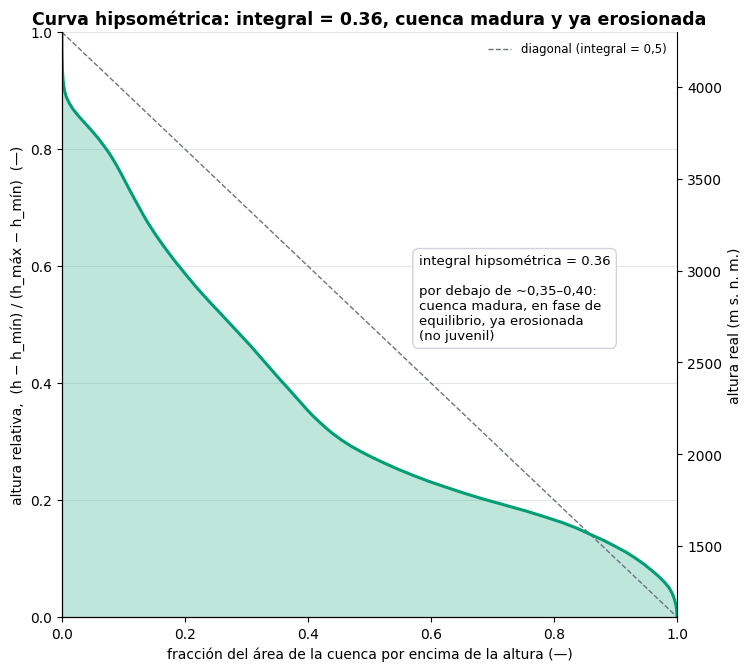

In [24]:
altura_min, altura_max = curva_hipsometrica.altura_m.min(), curva_hipsometrica.altura_m.max()
curva_hipsometrica["altura_relativa"] = (curva_hipsometrica.altura_m - altura_min) / (altura_max - altura_min)
integral_hips = morfometria.set_index("magnitud").loc["integral hipsométrica", "valor"]

fig, ax = plt.subplots(figsize=(7.4, 6.6), constrained_layout=True)
ax.fill_between(curva_hipsometrica.fraccion_area_encima, curva_hipsometrica.altura_relativa, 0,
                 color=VERDE, alpha=0.25, zorder=1)
ax.plot(curva_hipsometrica.fraccion_area_encima, curva_hipsometrica.altura_relativa, color=VERDE,
        linewidth=2.2, zorder=2)
ax.plot([0, 1], [1, 0], color=GRIS, linewidth=1, linestyle="--", zorder=1, label="diagonal (integral = 0,5)")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("fracción del área de la cuenca por encima de la altura (—)")
ax.set_ylabel("altura relativa,  (h − h_mín) / (h_máx − h_mín)  (—)")
ax.legend(loc="upper right", fontsize=8.5, frameon=False)
estilo_cartesiano(ax)

eje_alturas = ax.twinx()
eje_alturas.set_ylim(altura_min, altura_max)
eje_alturas.set_ylabel("altura real (m s. n. m.)")
eje_alturas.spines["top"].set_visible(False)

ax.text(0.58, 0.62,
        f"integral hipsométrica = {integral_hips:.2f}\n\n"
        "por debajo de ~0,35–0,40:\ncuenca madura, en fase de\nequilibrio, ya erosionada\n(no juvenil)",
        transform=ax.transAxes, fontsize=9.5, va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor="#D1D5DB"))

ax.set_title(f"Curva hipsométrica: integral = {integral_hips:.2f}, cuenca madura y ya erosionada",
             fontsize=12.5, weight="semibold")
plt.show()

**Lectura.** La integral hipsométrica da 0.36, por debajo del rango 0.35–0.40 que se usa como
referencia para una cuenca en equilibrio. Una integral cercana a 1 describiría una cuenca juvenil, con
la mayor parte del área todavía cerca de la altura máxima y poco material erosionado; una integral baja,
como esta, describe una cuenca madura: ya erosionada, con el relieve suavizado y buena parte del área
concentrada en las alturas intermedias y bajas, no en las cumbres.

### 2.4 Pendientes y orientación de laderas

Distribución de la pendiente del terreno (no la del cauce, la del terreno completo) y de hacia dónde
miran las laderas, ambas calculadas sobre el DEM.

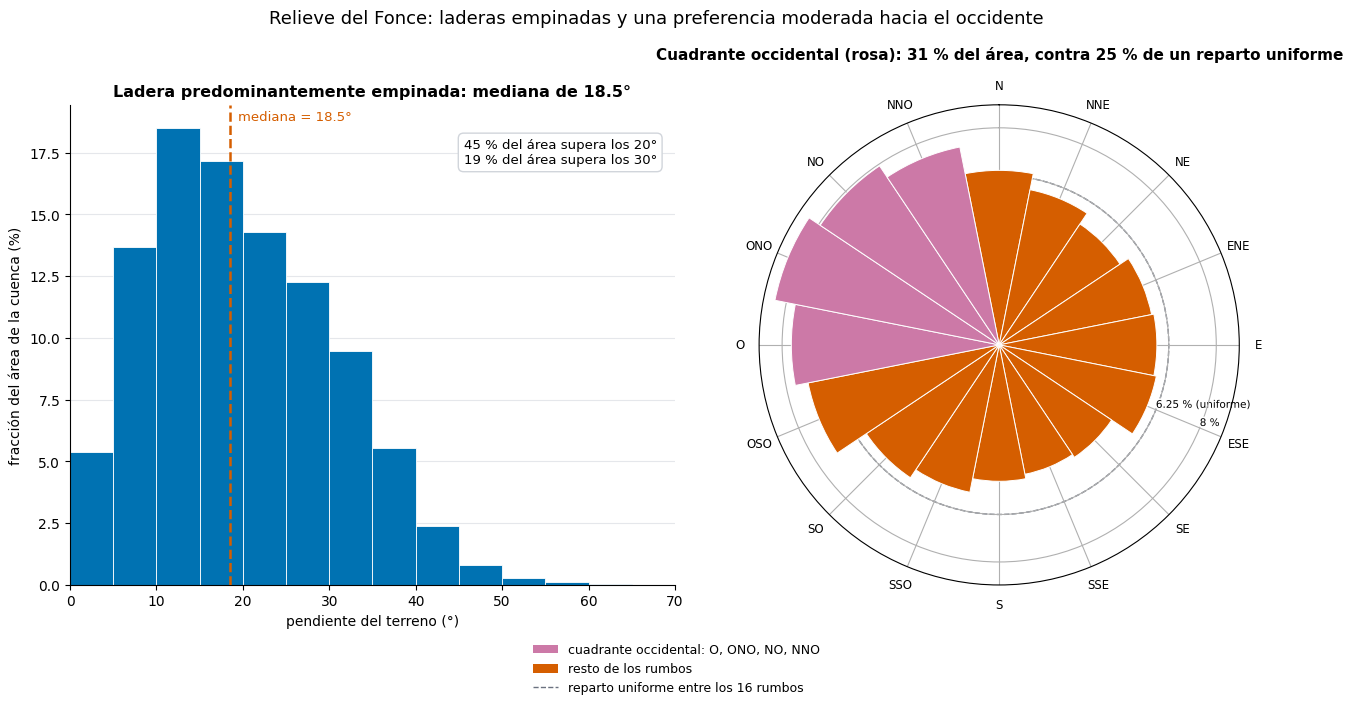

In [25]:
frac_mayor_20 = pendientes.loc[pendientes.desde_grados >= 20, "fraccion_area"].sum()
frac_mayor_30 = pendientes.loc[pendientes.desde_grados >= 30, "fraccion_area"].sum()
mediana_pend = morfometria.set_index("magnitud").loc["pendiente mediana del terreno", "valor"]

fig = plt.figure(figsize=(13, 6.6), constrained_layout=True)
izq = fig.add_subplot(1, 2, 1)
der = fig.add_subplot(1, 2, 2, projection="polar")

# --- panel izquierdo: histograma de pendientes ---
ancho = pendientes.hasta_grados - pendientes.desde_grados
izq.bar(pendientes.desde_grados, pendientes.fraccion_area * 100, width=ancho, align="edge",
        color=AZUL, edgecolor="white", linewidth=0.6, zorder=2)
izq.axvline(mediana_pend, color=NARANJA, linewidth=1.8, linestyle="--", zorder=3)
izq.annotate(f"mediana = {mediana_pend:.1f}°", (mediana_pend, izq.get_ylim()[1]),
             xytext=(6, -4), textcoords="offset points", fontsize=9.5, color=NARANJA, va="top")
izq.text(0.97, 0.93,
         f"{frac_mayor_20*100:.0f} % del área supera los 20°\n{frac_mayor_30*100:.0f} % del área supera los 30°",
         transform=izq.transAxes, fontsize=9.5, va="top", ha="right",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#D1D5DB"))
izq.set_xlim(0, pendientes.hasta_grados.max())
izq.set_xlabel("pendiente del terreno (°)")
izq.set_ylabel("fracción del área de la cuenca (%)")
izq.set_title(f"Ladera predominantemente empinada: mediana de {mediana_pend:.1f}°",
              fontsize=11.5, weight="semibold")
estilo_cartesiano(izq)

# --- panel derecho: rosa de orientaciones ---
# el rumbo va en orden horario empezando en N, cada uno a 22.5° del anterior (scripts/13_morfometria.py)
angulos = np.radians(np.arange(len(orientaciones)) * 22.5)
ancho_barra = np.radians(22.5)
# cuadrante occidental completo: O, ONO, NO, NNO. Se resalta para comparar contra el 25 % que le tocaría
# si el reparto fuera uniforme entre los cuatro cuadrantes
cuadrante_occidental = {"O", "ONO", "NO", "NNO"}
colores = [ROSA if r in cuadrante_occidental else NARANJA for r in orientaciones.rumbo]

der.bar(angulos, orientaciones.fraccion_area * 100, width=ancho_barra, color=colores,
        edgecolor="white", linewidth=0.7, zorder=2, align="center")
# círculo de referencia: lo que le tocaría a cada uno de los 16 rumbos si el reparto fuera uniforme (100/16 %)
uniforme_pct = 100 / len(orientaciones)
theta_circulo = np.linspace(0, 2 * np.pi, 200)
der.plot(theta_circulo, np.full_like(theta_circulo, uniforme_pct), color=GRIS, linewidth=1,
         linestyle="--", zorder=1)

der.set_theta_zero_location("N")
der.set_theta_direction(-1)          # sentido horario
der.set_xticks(angulos)
der.set_xticklabels(orientaciones.rumbo, fontsize=8.5)
der.set_ylabel("")
der.set_rlabel_position(112.5)
der.set_yticks([uniforme_pct, 8])
der.set_yticklabels([f"{uniforme_pct:.2f} % (uniforme)", "8 %"], fontsize=7.5)
for etiqueta in der.get_yticklabels():
    etiqueta.set_path_effects([pe.withStroke(linewidth=2.5, foreground="white")])
der.set_title("Cuadrante occidental (rosa): 31 % del área, contra 25 % de un reparto uniforme",
              fontsize=11, weight="semibold", pad=14)

manejadores = [Patch(facecolor=ROSA, label="cuadrante occidental: O, ONO, NO, NNO"),
               Patch(facecolor=NARANJA, label="resto de los rumbos"),
               Line2D([0], [0], color=GRIS, lw=1, ls="--", label="reparto uniforme entre los 16 rumbos")]
fig.legend(handles=manejadores, loc="outside lower center", ncol=1, frameon=False, fontsize=9)

fig.suptitle("Relieve del Fonce: laderas empinadas y una preferencia moderada hacia el occidente",
             fontsize=13, y=1.05)
plt.show()

**Lectura.** La pendiente mediana del terreno es 18.5°: una cuenca de ladera empinada en general. El
45 % del área supera los 20° y el 19 % supera los 30°, así que buena parte de la cuenca está en
pendientes que condicionan tanto la velocidad de la escorrentía como el riesgo de movimientos en masa.

Sobre la orientación: hay una preferencia hacia el occidente, pero es moderada, no dominante. El rumbo
individual con más área es ONO, con 8.4 % del área contra el 6.25 % que le tocaría a cada uno de los 16
rumbos si el reparto fuera uniforme —1.35 veces más—. Agrupando todo el cuadrante occidental (O, ONO, NO,
NNO) da 31 % del área, contra 25 % que sería el reparto uniforme para un cuarto de la rosa. Es una señal
real, consistente con que la humedad que alimenta la cuenca entra en buena parte desde el valle del
Magdalena, al occidente, pero no alcanza para decir que las laderas del Fonce miran "sobre todo" hacia
allá: cerca del 70 % del área mira hacia los otros tres cuadrantes, y el resto de los rumbos individuales
está repartido de forma bastante pareja, entre 4.9 % y 7.2 % cada uno.

### 2.5 Dos problemas con los datos de CAMELS-COL

Esta es la sección más importante de la morfometría: dos productos de CAMELS-COL para el Fonce no
cuadran con lo que da medir directamente sobre el DEM y la red de drenaje. El primero es un error de
pendiente que se propaga a los tiempos de concentración; el segundo compara tres formas distintas de
trazar el cauce principal, y de paso valida la divisoria de la cuenca de forma independiente.

**(a) Los tiempos de concentración están mal.**

CAMELS-COL publica un `equi_slope` (pendiente equivalente del cauce) de 4.45×10⁻⁵ m/m para el Fonce.
Con la pendiente real del cauce, medida con el método de Taylor-Schwarz sobre el perfil extraído del DEM
(0.0192 m/m, unas 430 veces mayor), los tiempos de concentración cambian de orden de magnitud.

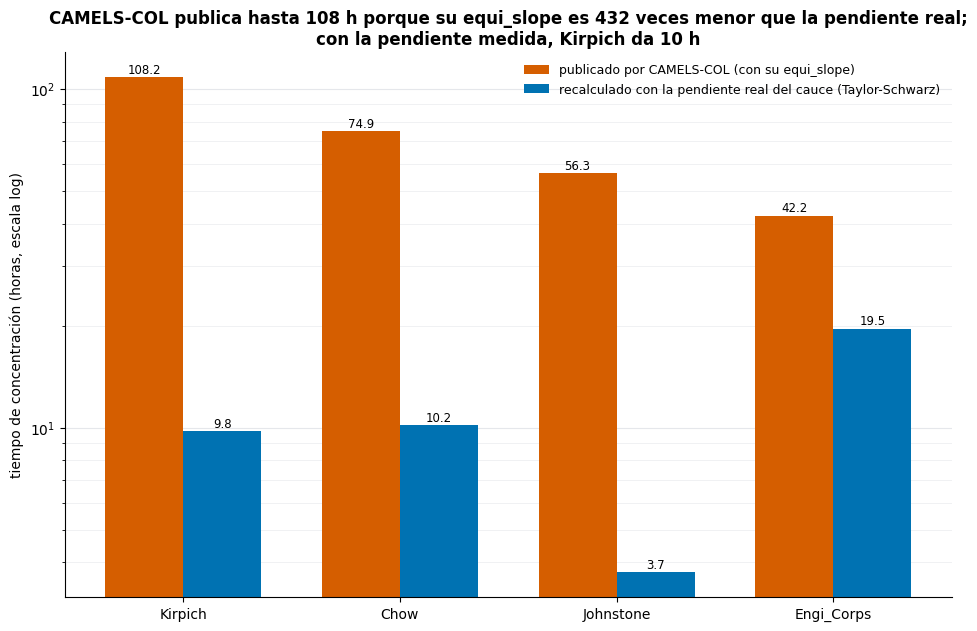

Kirpich con el equi_slope de CAMELS-COL: 101.1 h (publicado por CAMELS-COL: 108.2 h)


In [26]:
pendiente_taylor = morfometria.set_index("magnitud").loc["pendiente del cauce (Taylor-Schwarz)", "valor"]
equi_slope_camels = morfometria.set_index("magnitud").loc["pendiente del cauce (Taylor-Schwarz)", "publicado_camels"]
factor_pendiente = pendiente_taylor / equi_slope_camels

x = np.arange(len(tiempos_concentracion))
ancho = 0.36

fig, ax = plt.subplots(figsize=(9.5, 6.2), constrained_layout=True)
barras_pub = ax.bar(x - ancho / 2, tiempos_concentracion.publicado_camels_h, ancho, color=NARANJA, zorder=2,
                     label="publicado por CAMELS-COL (con su equi_slope)")
barras_med = ax.bar(x + ancho / 2, tiempos_concentracion.con_pendiente_medida_h, ancho, color=AZUL, zorder=2,
                     label="recalculado con la pendiente real del cauce (Taylor-Schwarz)")

for barras in (barras_pub, barras_med):
    for b in barras:
        ax.annotate(f"{b.get_height():.1f}", (b.get_x() + b.get_width() / 2, b.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8.5)

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(tiempos_concentracion.formula)
ax.set_ylabel("tiempo de concentración (horas, escala log)")
ax.legend(loc="upper right", fontsize=9, frameon=False)
estilo_cartesiano(ax)
ax.grid(axis="y", which="minor", color="#E5E7EB", linewidth=0.4, zorder=0)

kirpich_medido_h = tiempos_concentracion.loc[tiempos_concentracion.formula == "Kirpich", "con_pendiente_medida_h"].iloc[0]
ax.set_title(
    f"CAMELS-COL publica hasta {tiempos_concentracion.publicado_camels_h.max():.0f} h porque su equi_slope "
    f"es {factor_pendiente:.0f} veces menor que la pendiente real;\ncon la pendiente medida, Kirpich da "
    f"{kirpich_medido_h:.0f} h",
    fontsize=12, weight="semibold")
plt.show()

# prueba de que el error está en la pendiente y no en la fórmula: usando el equi_slope que reporta
# CAMELS-COL dentro de la misma fórmula de Kirpich, se reproduce casi exactamente lo que ellos publican
kirpich = tiempos_concentracion.loc[tiempos_concentracion.formula == "Kirpich"].iloc[0]
print(f"Kirpich con el equi_slope de CAMELS-COL: {kirpich.con_equi_slope_camels_h:.1f} h "
      f"(publicado por CAMELS-COL: {kirpich.publicado_camels_h:.1f} h)")

**Lectura.** Con el `equi_slope` que publica CAMELS-COL, Kirpich da un tiempo de concentración de
108 horas. Con la pendiente real del cauce, el mismo Kirpich da 10 horas. Las otras tres fórmulas (Chow,
Johnstone, Engi_Corps) se mueven en la misma dirección: bajan de decenas de horas a unas pocas.

La prueba de que el problema está en la pendiente y no en las fórmulas está en el print de arriba: si se
usa el `equi_slope` que reporta CAMELS-COL dentro de la misma fórmula de Kirpich, el resultado (101.1 h)
reproduce casi exactamente el valor que ellos publican (108.2 h). La diferencia entre esos dos números es
pequeña —variantes menores de cómo se aplicó la fórmula—; la diferencia grande está entre 0.0181 y
4.45×10⁻⁵ m/m, es decir, en el dato de pendiente que usaron, no en el cálculo del tiempo de
concentración.

**(b) La comparación de los tres trazados del cauce.**

Tres formas independientes de obtener el cauce principal de San Gil: la red de drenaje que publica
CAMELS-COL (el camino más largo de su grafo de cauces), el cauce derivado directamente del DEM con
pysheds —llenado de depresiones, dirección de flujo D8 y acumulación de flujo
(`scripts/15_cauce_desde_dem.py`)— y las cifras que CAMELS-COL publica como atributos de la cuenca.

In [27]:
tabla_cauces = comparacion_cauces.set_index("magnitud").rename(columns={
    "red_de_camels": "red de drenaje de CAMELS-COL",
    "derivado_del_dem": "derivado del DEM (pysheds)",
    "publicado_camels": "publicado por CAMELS-COL",
    "dif_pct": "diferencia (%)",
})

# formato con más decimales para las pendientes (del orden de 10⁻² a 10⁻⁵ m/m): con 1-2 decimales
# la pendiente publicada por CAMELS-COL se vería como 0.00 y escondería justo el problema que muestra la tabla
def _formatea(v):
    if pd.isna(v):
        return "—"
    return f"{v:.6f}" if abs(v) < 1 else f"{v:,.1f}".replace(",", " ")

columnas_valor = ["red de drenaje de CAMELS-COL", "derivado del DEM (pysheds)", "publicado por CAMELS-COL"]
tabla_mostrar = tabla_cauces.copy()
for columna in columnas_valor:
    tabla_mostrar[columna] = tabla_cauces[columna].map(_formatea)
tabla_mostrar["diferencia (%)"] = tabla_cauces["diferencia (%)"].map(lambda v: f"{v:.1f}")
display(tabla_mostrar)

,red de drenaje de CAMELS-COL,derivado del DEM (pysheds),publicado por CAMELS-COL,diferencia (%)
magnitud,,,,
longitud del cauce principal (km),90.8,95.0,99.1,4.7
desnivel del cauce (m),2 046.0,2 776.0,—,35.7
pendiente media (m/m),0.022544,0.029213,—,29.6
pendiente Taylor-Schwarz (m/m),0.019244,0.045030,0.000044,134.0
área drenada en la salida (km²),2 098.8,2 087.7,2 124.0,-0.5


**Lectura.** La longitud del cauce concuerda dentro de un 9 % entre las tres fuentes: 90.76 km (red de
CAMELS-COL), 95.03 km (derivado del DEM) y 99.12 km (publicado por CAMELS-COL).

El resultado más importante de esta tabla es otro: el área que drena hasta la salida según el trazado del
DEM da 2 088 km², contra 2 099 km² del polígono de la cuenca, que es el área que usa todo el análisis —
apenas 0.5 % de diferencia. **El DEM valida la divisoria de la cuenca de forma independiente**, sin
depender del polígono que publica CAMELS-COL ni de cómo se digitalizó.

La pendiente confirma el problema encontrado en (a) por un segundo camino: la pendiente Taylor-Schwarz da
0.0192 m/m con la red de CAMELS-COL y 0.0450 m/m con el cauce derivado del DEM —las dos medidas propias
quedan en el orden de 10⁻² m/m—, mientras que lo que CAMELS-COL publica como `equi_slope` es del orden de
10⁻⁵ m/m. Dos trazados distintos, hechos con datos y métodos distintos, coinciden entre sí y los dos se
alejan igual de lo publicado: el error queda confirmado por dos caminos independientes, no depende de
cómo se trazó el cauce.

El desnivel sí difiere bastante entre los dos trazados propios (2 046 m con la red de CAMELS-COL contra
2 776 m con el DEM), pero por una razón distinta, de definición y no de error: el trazado D8 sobre el DEM
remonta el cauce hasta la divisoria misma de la cuenca, mientras que la red de CAMELS-COL empieza donde
ellos definen el inicio del cauce, más abajo en la ladera. Miden desniveles sobre tramos de distinta
longitud en la cabecera, no la misma magnitud con métodos distintos.

### Comparaciones complementarias de lluvia y caudal (gráficas a–c del visor web)

Estas nubes relacionan PI y PL con el caudal mensual. Cada par usa meses con datos válidos simultáneos; periodo, N y métricas se calculan desde las series. Las figuras se construyen con Matplotlib y la lectura estadística aparece debajo de cada gráfico.

In [ ]:
relaciones_lluvia_caudal = [
 {"codigo":"a","nombre":"IMERG frente a lluvia local","columna_x":"PI (mm/mes)","columna_y":"PL (mm/mes)","etiqueta_x":"Precipitación satelital IMERG (PI, mm/mes)","etiqueta_y":"Lluvia local (PL, mm/mes)"},
 {"codigo":"b","nombre":"Lluvia local frente a caudal","columna_x":"PL (mm/mes)","columna_y":"Q (m³/s)","etiqueta_x":"Lluvia local (PL, mm/mes)","etiqueta_y":"Caudal medio (Q, m³/s)"},
 {"codigo":"c","nombre":"IMERG frente a caudal","columna_x":"PI (mm/mes)","columna_y":"Q (m³/s)","etiqueta_x":"Precipitación satelital IMERG (PI, mm/mes)","etiqueta_y":"Caudal medio (Q, m³/s)"},
]
# Criterios heurísticos: fuerza por |r| (0.3 y 0.7), curvatura por mejora de R² (0.05), Cook (4/N), atípicos (>3 desviaciones) y cambio de varianza (razón 1.5).
for relacion in relaciones_lluvia_caudal:
    pares=variables_resumen[[relacion["columna_x"],relacion["columna_y"]]].dropna().sort_index()
    x=pares.iloc[:,0].to_numpy(float); y=pares.iloc[:,1].to_numpy(float); n=len(pares)
    inicio=pares.index.min().strftime("%m/%Y"); fin=pares.index.max().strftime("%m/%Y")
    r=stats.pearsonr(x,y)[0]; rho=stats.spearmanr(x,y)[0]
    diferencia_corr=abs(r-rho)
    texto_correlaciones=("Los coeficientes son similares, compatible con una relación monotónica cercana a lineal." if diferencia_corr<.15 else "Spearman y Pearson difieren; puede haber monotonicidad no lineal o influencia de valores atípicos.")
    fuerza="débil" if abs(r)<.3 else ("moderada" if abs(r)<.7 else "fuerte")
    direccion="positiva" if r>0 else ("negativa" if r<0 else "nula")
    pred=np.polyval(np.polyfit(x,y,1),x); pred2=np.polyval(np.polyfit(x,y,2),x)
    sst=np.sum((y-y.mean())**2); r2=1-np.sum((y-pred)**2)/sst; r2q=1-np.sum((y-pred2)**2)/sst
    residuos=y-pred; mejora=r2q-r2; sigma=np.std(residuos,ddof=2)
    z=(pares-pares.mean())/pares.std(ddof=0).replace(0,np.nan); tri=pares.index.quarter.to_numpy()
    centros=z.assign(trimestre=tri).groupby("trimestre").median(); centro=z.median()
    entre=np.sqrt(((centros-centro)**2).sum(axis=1)).mean(); dentro=np.sqrt(((z.to_numpy()-centros.loc[tri].to_numpy())**2).sum(axis=1)).mean(); razon_tri=entre/dentro if dentro else np.nan
    X=np.column_stack([np.ones(n),x]); h=np.einsum("ij,jk,ik->i",X,np.linalg.pinv(X.T@X),X)
    mse=np.sum(residuos**2)/(n-2); cook=(residuos**2/(2*mse))*h/np.maximum((1-h)**2,np.finfo(float).eps)
    infl=int(np.sum(cook>4/n)); atipicos=int(np.sum(np.abs(residuos)/(sigma if sigma else 1)>3))
    terc=np.array_split(np.argsort(x),3); vb=np.var(residuos[terc[0]],ddof=1); va=np.var(residuos[terc[-1]],ddof=1); razon_var=va/vb if vb else np.inf
    forma="curvatura apreciable" if mejora>=.05 else "sin curvatura marcada"
    cluster="separación estacional visible" if razon_tri>=1 else "trimestres ampliamente superpuestos"
    hetero="mayor dispersión con lluvia alta" if razon_var>=1.5 else ("menor dispersión con lluvia alta" if razon_var<=1/1.5 else "sin cambio marcado de dispersión")
    fig,ax=plt.subplots(figsize=(7.8,6.3),constrained_layout=True)
    sc=ax.scatter(x,y,c=pares.index.month,cmap=plt.get_cmap("turbo",12),vmin=.5,vmax=12.5,s=38,alpha=.78,edgecolors="white",linewidths=.5)
    if relacion["codigo"]=="a":
        error=x-y; sesgo=float(np.mean(error)); mae=float(np.mean(np.abs(error))); rmse=float(np.sqrt(np.mean(error**2)))
        lim=max(x.max(),y.max());ax.plot([0,lim],[0,lim],"--",color="#9AA9A5",label="Igualdad (PI = PL)");ax.set_xlim(0,lim);ax.set_ylim(0,lim);ax.set_aspect("equal");ax.legend(frameon=False)
    ax.set(xlabel=relacion["etiqueta_x"],ylabel=relacion["etiqueta_y"],title=relacion["nombre"]);ax.grid(color="#E5E7EB");ax.set_axisbelow(True)
    for lado in ("top","right"):ax.spines[lado].set_visible(False)
    barra=fig.colorbar(sc,ax=ax,ticks=np.arange(1,13),pad=.02);barra.ax.set_yticklabels(MESES_ABREV);barra.set_label("Mes calendario")
    plt.show()
    display(Markdown(f"**{relacion['codigo']}) {relacion['nombre']}.** Periodo {inicio}–{fin}; N={n}. Dirección {direccion}, fuerza {fuerza} (Pearson r={r:.2f}; Spearman ρ={rho:.2f}). {texto_correlaciones} Forma: {forma} (R² lineal={r2:.2f}; mejora cuadrática={mejora:.2f}); dispersión residual={sigma:.2f}. Agrupamiento trimestral: {cluster} (razón centros/intradispersión={razon_tri:.2f}). Puntos influyentes por Cook>4/N: {infl}; valores atípicos por residuo estandarizado: {atipicos}. Variabilidad: {hetero} (razón varianza tercil alto/bajo={razon_var:.2f})."))
    if relacion["codigo"]=="a":
        sentido="sobreestima" if sesgo>0 else ("subestima" if sesgo<0 else "no muestra sesgo medio")
        display(Markdown(f"**Errores frente a PL:** PI {sentido}. Sesgo medio (PI − PL) = {sesgo:.1f} mm/mes; MAE = {mae:.1f} mm/mes; RMSE = {rmse:.1f} mm/mes. El sesgo conserva la dirección del error; MAE expresa su magnitud absoluta media y RMSE penaliza más las desviaciones grandes. Una correlación lineal alta (R o R²) no garantiza concordancia ni exactitud: una sobreestimación sistemática puede mantener la correlación y producir errores elevados."))
display(Markdown("**Pearson y Spearman.** Pearson mide relación lineal y es sensible a valores atípicos; Spearman usa rangos para captar relaciones monotónicas, incluso no lineales, y suele ser menos sensible a extremos. Cuando difieren, la asociación puede ser monotónica sin ser lineal o estar afectada por valores extremos."))
display(Markdown("**Límite causal y predictivo.** Una correlación alta no demuestra causalidad física ni basta para justificar o garantizar un modelo predictivo. La variabilidad estacional coordinada puede producir asociación sin demostrar transferencia real de masa; la capacidad predictiva requiere validación propia."))

### 2.1.3 Evaluación fuera del periodo de ajusteSe comparan bloques temporales continuos para respetar el orden de las observaciones y evitar que meses autocorrelacionados queden mezclados entre ajuste y validación. Los coeficientes OLS y la climatología mensual de Q se estiman exclusivamente con el bloque de ajuste. Las predicciones no se recortan; los valores negativos se identifican como físicamente implausibles.

In [ ]:
# La tabla mensual y todas las dependencias ya se cargaron en la primera celda.periodos_eval = pd.period_range("1998-01", "2022-12", freq="M")series_eval = variables_mensuales[["PI", "PL", "Q"]].copy().reindex(periodos_eval)
series_eval["Q"] = series_eval.Q * AREA_KM2[ID_PRINCIPAL] * 1000 / (series_eval.index.days_in_month * 86400)series_eval.columns = ["PI", "PL", "Q"]ajuste_eval = series_eval.loc["1998-01":"2014-12"]validacion_eval = series_eval.loc["2015-01":"2022-12"]def metricas_eval(observado, estimado):    pares = pd.concat([observado.rename("observado"), estimado.rename("estimado")], axis=1).dropna()    error = pares.estimado - pares.observado    return {"n": len(pares), "sesgo": error.mean(), "mae": error.abs().mean(),            "rmse": np.sqrt(np.mean(error ** 2))}def ajustar_ols_eval(columna_x, columna_y, rezago=0):    muestra = pd.concat([ajuste_eval[columna_x].shift(rezago).rename("x"),                         ajuste_eval[columna_y].rename("y")], axis=1).dropna()    if len(muestra) < 3 or muestra.x.nunique() < 2:        return None    pendiente, intercepto = np.polyfit(muestra.x.to_numpy(float), muestra.y.to_numpy(float), 1)    return {"pendiente": pendiente, "intercepto": intercepto, "n_ajuste": len(muestra)}def comparar_eval(observado, estimado):    pares = pd.concat([observado.rename("observado"), estimado.rename("estimado")], axis=1).dropna()    pares["residuo"] = pares.observado - pares.estimado    return paresmodelos_eval = {}coef_pl = ajustar_ols_eval("PI", "PL")pred_pl_ols = coef_pl["intercepto"] + coef_pl["pendiente"] * series_eval.PImodelos_eval["PL · OLS con PI"] = {    "objetivo": "PL", "ajuste": comparar_eval(ajuste_eval.PL, pred_pl_ols.loc[ajuste_eval.index]),    "validacion": comparar_eval(validacion_eval.PL, pred_pl_ols.loc[validacion_eval.index])}modelos_eval["PL · IMERG sin corrección"] = {    "objetivo": "PL", "ajuste": comparar_eval(ajuste_eval.PL, ajuste_eval.PI),    "validacion": comparar_eval(validacion_eval.PL, validacion_eval.PI)}climatologia_q_eval = ajuste_eval.groupby(ajuste_eval.index.month).Q.mean()pred_q_clima = pd.Series([climatologia_q_eval.get(p.month, np.nan) for p in series_eval.index], index=series_eval.index)modelos_eval["Q · climatología mensual"] = {    "objetivo": "Q", "ajuste": comparar_eval(ajuste_eval.Q, pred_q_clima.loc[ajuste_eval.index]),    "validacion": comparar_eval(validacion_eval.Q, pred_q_clima.loc[validacion_eval.index])}for predictor in ("PL", "PI"):    for rezago in (0, 1):        nombre = f"Q · OLS con {predictor} t" if rezago == 0 else f"Q · OLS con {predictor} t−1"        coef = ajustar_ols_eval(predictor, "Q", rezago)        x_completo = series_eval[predictor].shift(rezago)        pred = coef["intercepto"] + coef["pendiente"] * x_completo        modelos_eval[nombre] = {            "objetivo": "Q", "coeficientes": coef,            "ajuste": comparar_eval(ajuste_eval.Q, pred.loc[ajuste_eval.index]),            "validacion": comparar_eval(validacion_eval.Q, pred.loc[validacion_eval.index])}# Figuras de la validación: series observadas/estimadas y diagnóstico en tres dimensiones residuales.fig, eje = plt.subplots(figsize=(12, 4.5))pl_ols_val = modelos_eval["PL · OLS con PI"]["validacion"]pl_ref_val = modelos_eval["PL · IMERG sin corrección"]["validacion"]eje.plot(pl_ols_val.index.to_timestamp(), pl_ols_val.observado, color="#202020", label="PL observado")eje.plot(pl_ols_val.index.to_timestamp(), pl_ols_val.estimado, color=AZUL, label="PL estimado · OLS")eje.plot(pl_ref_val.index.to_timestamp(), pl_ref_val.estimado, color=GRIS, linestyle="--", label="Benchmark · PI sin corregir")eje.set(title="PL observado y estimado durante la validación", ylabel="Precipitación (mm/mes)", xlabel="Mes")eje.grid(alpha=.2); eje.legend(ncol=3); fig.tight_layout(); plt.show()fig, eje = plt.subplots(figsize=(12, 4.5))q_ref_val = modelos_eval["Q · climatología mensual"]["validacion"]eje.plot(q_ref_val.index.to_timestamp(), q_ref_val.observado, color="#202020", linewidth=1.5, label="Q observado")eje.plot(q_ref_val.index.to_timestamp(), q_ref_val.estimado, color=GRIS, linestyle="--", label="Benchmark · climatología")for nombre, resultado in modelos_eval.items():    if resultado["objetivo"] == "Q" and nombre != "Q · climatología mensual":        pares = resultado["validacion"]        eje.plot(pares.index.to_timestamp(), pares.estimado, alpha=.8, linewidth=1, label=nombre)eje.set(title="Q observado y estimado durante la validación", ylabel="Caudal medio (m³/s)", xlabel="Mes")eje.grid(alpha=.2); eje.legend(ncol=2); fig.tight_layout(); plt.show()for nombre, resultado in modelos_eval.items():    pares = resultado["validacion"]    if pares.empty:        continue    fig, ejes = plt.subplots(1, 3, figsize=(15, 4))    fechas = pares.index.to_timestamp()    ejes[0].plot(fechas, pares.residuo, marker=".", linewidth=.8, color=AZUL)    ejes[0].axhline(0, color=GRIS, linestyle="--"); ejes[0].set(title="Residuo en el tiempo", xlabel="Mes", ylabel="Observado − estimado")    ejes[1].scatter(pares.estimado, pares.residuo, c=pares.index.month, cmap="turbo", vmin=1, vmax=12, alpha=.8)    ejes[1].axhline(0, color=GRIS, linestyle="--"); ejes[1].set(title="Residuo frente al estimado", xlabel="Estimado", ylabel="Residuo")    grupos_mes = [pares.loc[pares.index.month == mes, "residuo"].dropna().to_numpy() for mes in range(1, 13)]    ejes[2].boxplot(grupos_mes, labels=["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"], showfliers=True)    ejes[2].axhline(0, color=GRIS, linestyle="--"); ejes[2].tick_params(axis="x", rotation=45); ejes[2].set(title="Residuo por mes calendario", ylabel="Observado − estimado")    fig.suptitle(f"Diagnóstico fuera de muestra: {nombre}"); fig.tight_layout(); plt.show()# Resumen numérico calculado en ambos bloques, sin seleccionar parámetros con la validación.filas_eval = []for nombre, resultado in modelos_eval.items():    fila = {"modelo": nombre}    for bloque in ("ajuste", "validacion"):        pares = resultado[bloque]        met = metricas_eval(pares.observado, pares.estimado)        fila[f"{bloque}_n"] = met["n"]        for clave in ("sesgo", "mae", "rmse"):            fila[f"{bloque}_{clave}"] = met[clave]    filas_eval.append(fila)tabla_eval = pd.DataFrame(filas_eval)display(Markdown("### Métricas calculadas por bloque temporal\n\n" + tabla_eval.round(2).to_string(index=False)))met_pl = metricas_eval(pl_ols_val.observado, pl_ols_val.estimado)met_pl_ref = metricas_eval(pl_ref_val.observado, pl_ref_val.estimado)comparacion_pl = "supera" if met_pl["rmse"] < met_pl_ref["rmse"] else "no supera"rmse_ajuste_pl = metricas_eval(modelos_eval["PL · OLS con PI"]["ajuste"].observado, modelos_eval["PL · OLS con PI"]["ajuste"].estimado)["rmse"]razon_pl = met_pl["rmse"] / rmse_ajuste_pl if rmse_ajuste_pl else np.nanneg_pl = int((pl_ols_val.estimado < 0).sum())display(Markdown(f"**PL frente a su benchmark.** El OLS {comparacion_pl} a IMERG sin corregir en RMSE de validación ({met_pl['rmse']:.2f} frente a {met_pl_ref['rmse']:.2f} mm/mes); MAE = {met_pl['mae']:.2f}, sesgo = {met_pl['sesgo']:.2f} mm/mes. La razón RMSE validación/ajuste es {razon_pl:.2f}; predicciones negativas = {neg_pl}."))modelos_q = {n:r for n,r in modelos_eval.items() if r["objetivo"] == "Q" and n != "Q · climatología mensual"}met_q_ref = metricas_eval(q_ref_val.observado, q_ref_val.estimado)clasificacion_q = []for nombre, resultado in modelos_q.items():    pares = resultado["validacion"]    met = metricas_eval(pares.observado, pares.estimado)    rmse_ajuste = metricas_eval(resultado["ajuste"].observado, resultado["ajuste"].estimado)["rmse"]    por_mes = pares.residuo.groupby(pares.index.month).apply(lambda s: np.sqrt(np.mean(s ** 2)))    clasificacion_q.append((met["rmse"], nombre, met, rmse_ajuste, por_mes, int((pares.estimado < 0).sum())))mejor_q = min(clasificacion_q, key=lambda x: x[0])meses_q = mejor_q[4]mes_min_q, mes_max_q = int(meses_q.idxmin()), int(meses_q.idxmax())benchmark_superado = mejor_q[0] < met_q_ref["rmse"]lectura_benchmark = "supera" if benchmark_superado else "no supera"razon_q = mejor_q[0] / mejor_q[3] if mejor_q[3] else np.nannombres_mes_eval = ["enero", "febrero", "marzo", "abril", "mayo", "junio", "julio", "agosto", "septiembre", "octubre", "noviembre", "diciembre"]
pendiente_mejor_q = modelos_q[mejor_q[1]]["coeficientes"]["pendiente"]
direccion_mejor_q = "positiva" if pendiente_mejor_q > 0 else ("negativa" if pendiente_mejor_q < 0 else "nula")
display(Markdown(f"**Conclusión hidrológica en validación.** Entre los modelos lineales evaluados, el menor RMSE corresponde a **{mejor_q[1]}**, con relación {direccion_mejor_q} (pendiente OLS = {pendiente_mejor_q:.4f}; RMSE = {mejor_q[0]:.2f} m³/s), y {lectura_benchmark} la climatología mensual de Q ({met_q_ref['rmse']:.2f} m³/s). Su RMSE fuera/dentro del ajuste es {razon_q:.2f}; las predicciones negativas suman {mejor_q[5]}. Los RMSE residuales menor y mayor se observan en {nombres_mes_eval[mes_min_q-1]} y {nombres_mes_eval[mes_max_q-1]}, respectivamente. Esto describe la validación; no constituye selección independiente del modelo ni una garantía predictiva."))display(Markdown("**Alcance físico.** La asociación lluvia–caudal puede ser aprovechable para describir covariación mensual, pero los modelos contemporáneos/rezagados lineales simplifican almacenamiento, humedad antecedente y tránsito. IMERG Final incorpora pluviómetros y la red IDEAM puede compartir información, por lo que la independencia de fuentes es limitada. La climatología de Q representa el ciclo estacional; superarla indica información adicional respecto a ese ciclo, no causalidad por sí sola."))

## 3. Cómo se relacionan las variables entre sí

Hasta aquí cada variable se miró por separado o de dos en dos (precipitación contra caudal, una fuente
de temperatura contra la otra). Esta sección las cruza todas entre sí a la vez: las dos fuentes de
lluvia (PI y PL), Q, ETP y las dos fuentes de temperatura (T MSWX y T ERA5), seis variables
mensuales en total.

Los datos ya están calculados por `scripts/16_correlaciones_variables.py`; aquí no se recalcula nada,
solo se dibuja. El script cruza las seis variables sobre los **262 meses en que las seis tienen dato a
la vez** (no sobre la muestra propia de cada par), para que los coeficientes de la matriz sean
comparables entre sí. Además de las series crudas, todo se repite sobre las **anomalías**: cada variable
menos su propio ciclo anual medio, para separar "comparten el calendario" de "se mueven juntas cuando un
mes se sale de lo normal".

Cada figura es una matriz de dispersión (*pair plot*) de 6×6:

- **Diagonal**: histograma de cada variable.
- **Triángulo inferior**: nube de puntos de cada par (262 meses), pequeños y semitransparentes, con una
  recta de ajuste tenue encima.
- **Triángulo superior**: los coeficientes de **Pearson** (arriba, en grande) y de **Spearman** (abajo,
  con ρ) del par. El fondo de la celda se colorea según Pearson —azul para positivo, naranja para
  negativo, blanco en cero— y el tamaño del número de Pearson crece con |r|, para que la matriz se lea
  de un vistazo.

Etiquetas de variable solo en el borde izquierdo y el inferior, con su unidad. PI, PL, Q y ETP
van en mm/mes; T MSWX y T ERA5 en °C.

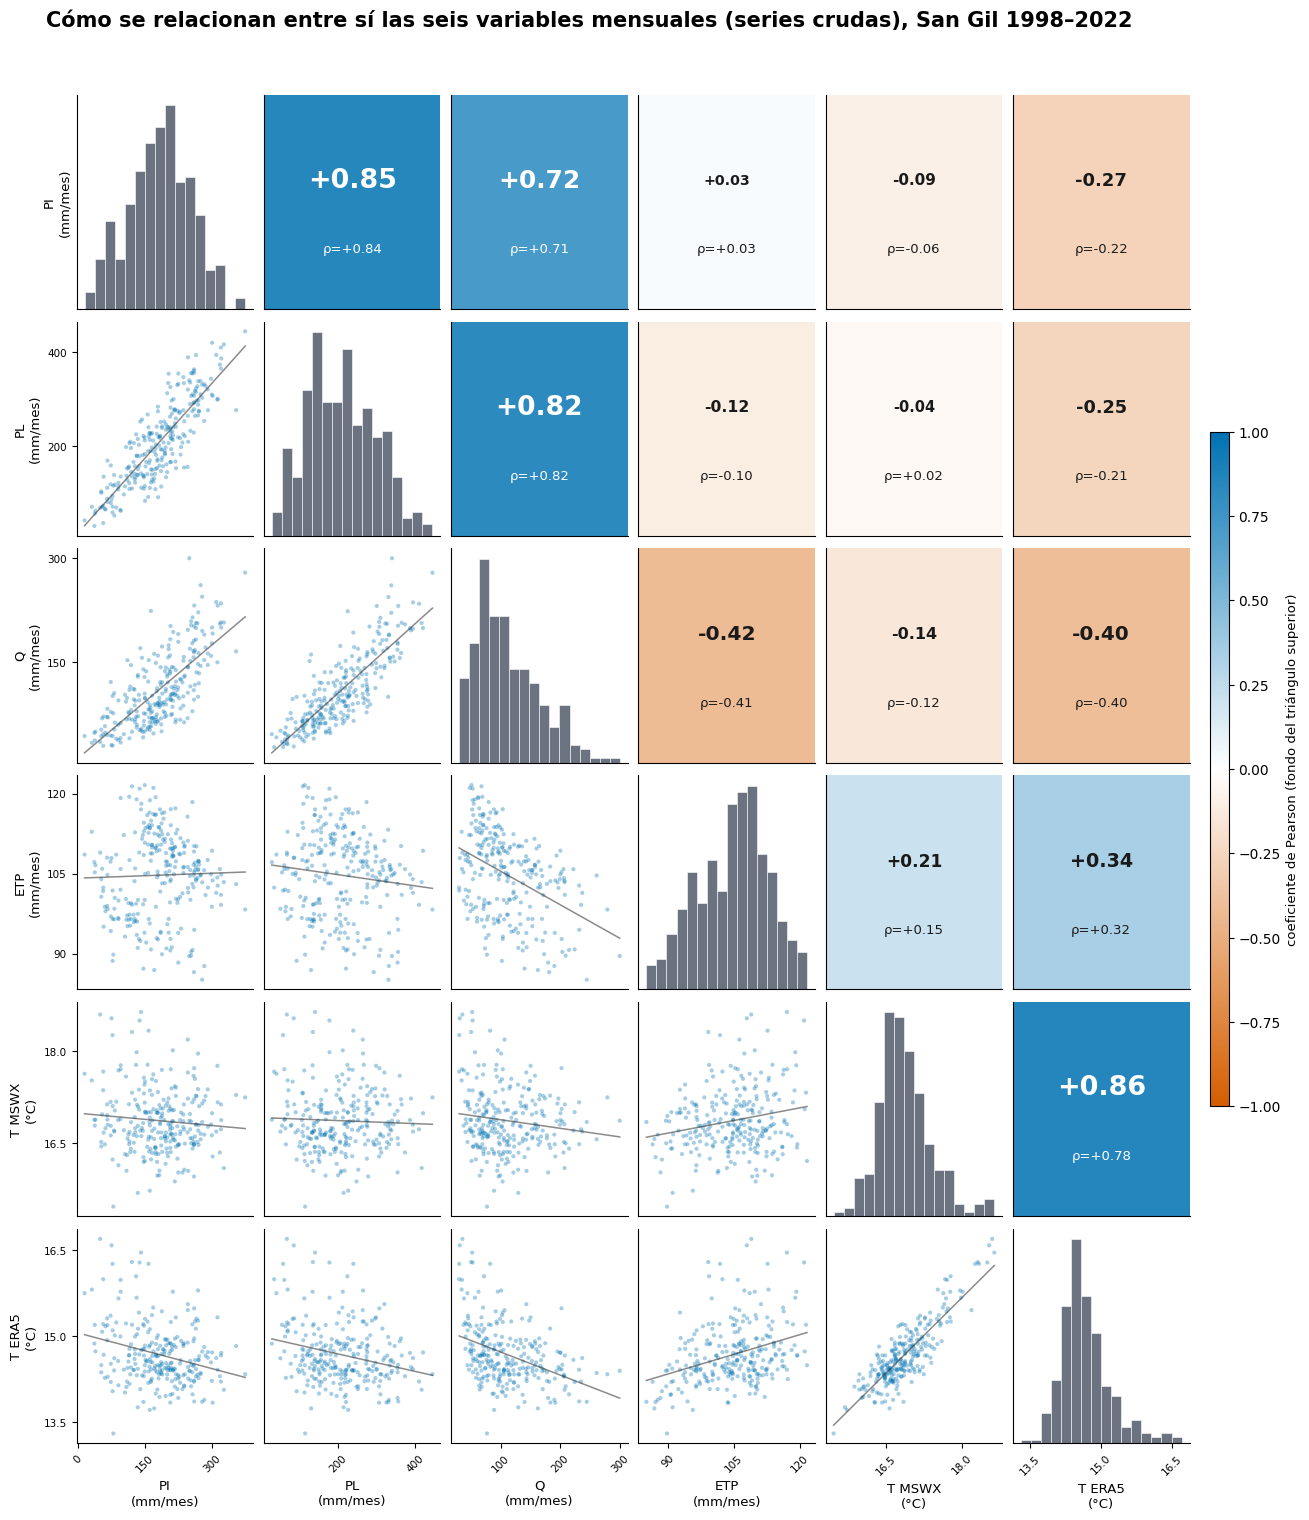

In [28]:
# paleta Okabe-Ito del proyecto; escala divergente para el fondo del triángulo superior,
# blanca en 0, naranja para correlaciones negativas y azul para positivas
AZUL, VERDE, NARANJA, ROSA, GRIS = "#0072B2", "#009E73", "#D55E00", "#CC79A7", "#6B7280"
CMAP_DIV = LinearSegmentedColormap.from_list("okabe_div", [NARANJA, "#FFFFFF", AZUL])
NORM_DIV = Normalize(vmin=-1, vmax=1)

VARIABLES_CORR = ["PI", "PL", "Q", "ETP", "T MSWX", "T ERA5"]
UNIDADES_CORR = {"PI": "mm/mes", "PL": "mm/mes", "Q": "mm/mes",
                 "ETP": "mm/mes", "T MSWX": "°C", "T ERA5": "°C"}


def dibujar_matriz_dispersion(datos, pearson, spearman, titulo, archivo):
    """Matriz de dispersión 6x6 de las variables mensuales del proyecto.

    Diagonal: histograma de cada variable. Triángulo inferior: nube de puntos del par con una recta de
    ajuste tenue. Triángulo superior: coeficientes de Pearson (grande, arriba) y Spearman (chico, abajo,
    con ρ), con el fondo de la celda coloreado según Pearson.
    """
    n = len(VARIABLES_CORR)
    fig, ejes = plt.subplots(n, n, figsize=(15.5, 15.5))
    fig.subplots_adjust(wspace=0.06, hspace=0.06, left=0.07, right=0.93, top=0.93, bottom=0.06)

    for i, vi in enumerate(VARIABLES_CORR):
        for j, vj in enumerate(VARIABLES_CORR):
            eje = ejes[i, j]
            if i == j:                                    # diagonal: histograma
                eje.hist(datos[vi].dropna(), bins=16, color=GRIS, edgecolor="white",
                        linewidth=0.4, zorder=2)
                eje.set_yticks([])
            elif i > j:                                    # triángulo inferior: nube de puntos
                pareja = datos[[vj, vi]].dropna()
                x, y = pareja[vj], pareja[vi]
                eje.scatter(x, y, s=9, alpha=0.35, color=AZUL, edgecolors="none",
                           zorder=2, rasterized=True)
                pendiente, intercepto = stats.linregress(x, y)[:2]     # recta de ajuste tenue
                x_recta = np.array([x.min(), x.max()])
                eje.plot(x_recta, intercepto + pendiente * x_recta, color="#2B2B2B",
                        lw=1.1, alpha=0.55, zorder=3)
                eje.yaxis.set_major_locator(plt.MaxNLocator(nbins=3))
            else:                                          # triángulo superior: coeficientes en texto
                r_pearson = pearson.loc[vi, vj]
                r_spearman = spearman.loc[vi, vj]
                eje.set_facecolor(CMAP_DIV(NORM_DIV(r_pearson)))
                color_texto = "white" if abs(r_pearson) > 0.55 else "#1A1A1A"
                tamano = 10 + 11 * abs(r_pearson)           # el texto de Pearson crece con |r|
                eje.text(0.5, 0.60, f"{r_pearson:+.2f}", ha="center", va="center", fontsize=tamano,
                        fontweight="bold", color=color_texto, transform=eje.transAxes, zorder=2)
                eje.text(0.5, 0.28, f"ρ={r_spearman:+.2f}", ha="center", va="center", fontsize=9.5,
                        color=color_texto, transform=eje.transAxes, zorder=2)
                eje.set_xticks([]); eje.set_yticks([])

            eje.xaxis.set_major_locator(plt.MaxNLocator(nbins=3))
            for lado in ("top", "right"):
                eje.spines[lado].set_visible(False)

            # etiquetas y marcas de eje solo en el borde izquierdo y el inferior
            if i < n - 1:
                eje.set_xticklabels([])
                eje.tick_params(axis="x", length=0)
            else:
                eje.tick_params(axis="x", labelsize=7.5, rotation=45)
                eje.set_xlabel(f"{vj}\n({UNIDADES_CORR[vj]})", fontsize=9.5)
            if j > 0:
                eje.set_yticklabels([])
                eje.tick_params(axis="y", length=0)
            else:
                eje.tick_params(axis="y", labelsize=7.5)
                eje.set_ylabel(f"{vi}\n({UNIDADES_CORR[vi]})", fontsize=9.5)

    mapeable = ScalarMappable(norm=NORM_DIV, cmap=CMAP_DIV)
    barra = fig.colorbar(mapeable, ax=ejes.ravel().tolist(), shrink=0.5, pad=0.015, aspect=35)
    barra.set_label("coeficiente de Pearson (fondo del triángulo superior)", fontsize=9.5)

    fig.suptitle(titulo, fontsize=15, fontweight="semibold", x=0.05, ha="left", y=0.985)
    fig.savefig(archivo, dpi=150, bbox_inches="tight")
    return fig


OUT_FIG = RAIZ / "reporte/figuras"
dibujar_matriz_dispersion(
    variables_mensuales, corr_pearson, corr_spearman,
    "Cómo se relacionan entre sí las seis variables mensuales (series crudas), San Gil 1998–2022",
    OUT_FIG / "matriz_dispersion_variables.png",
)
plt.show()

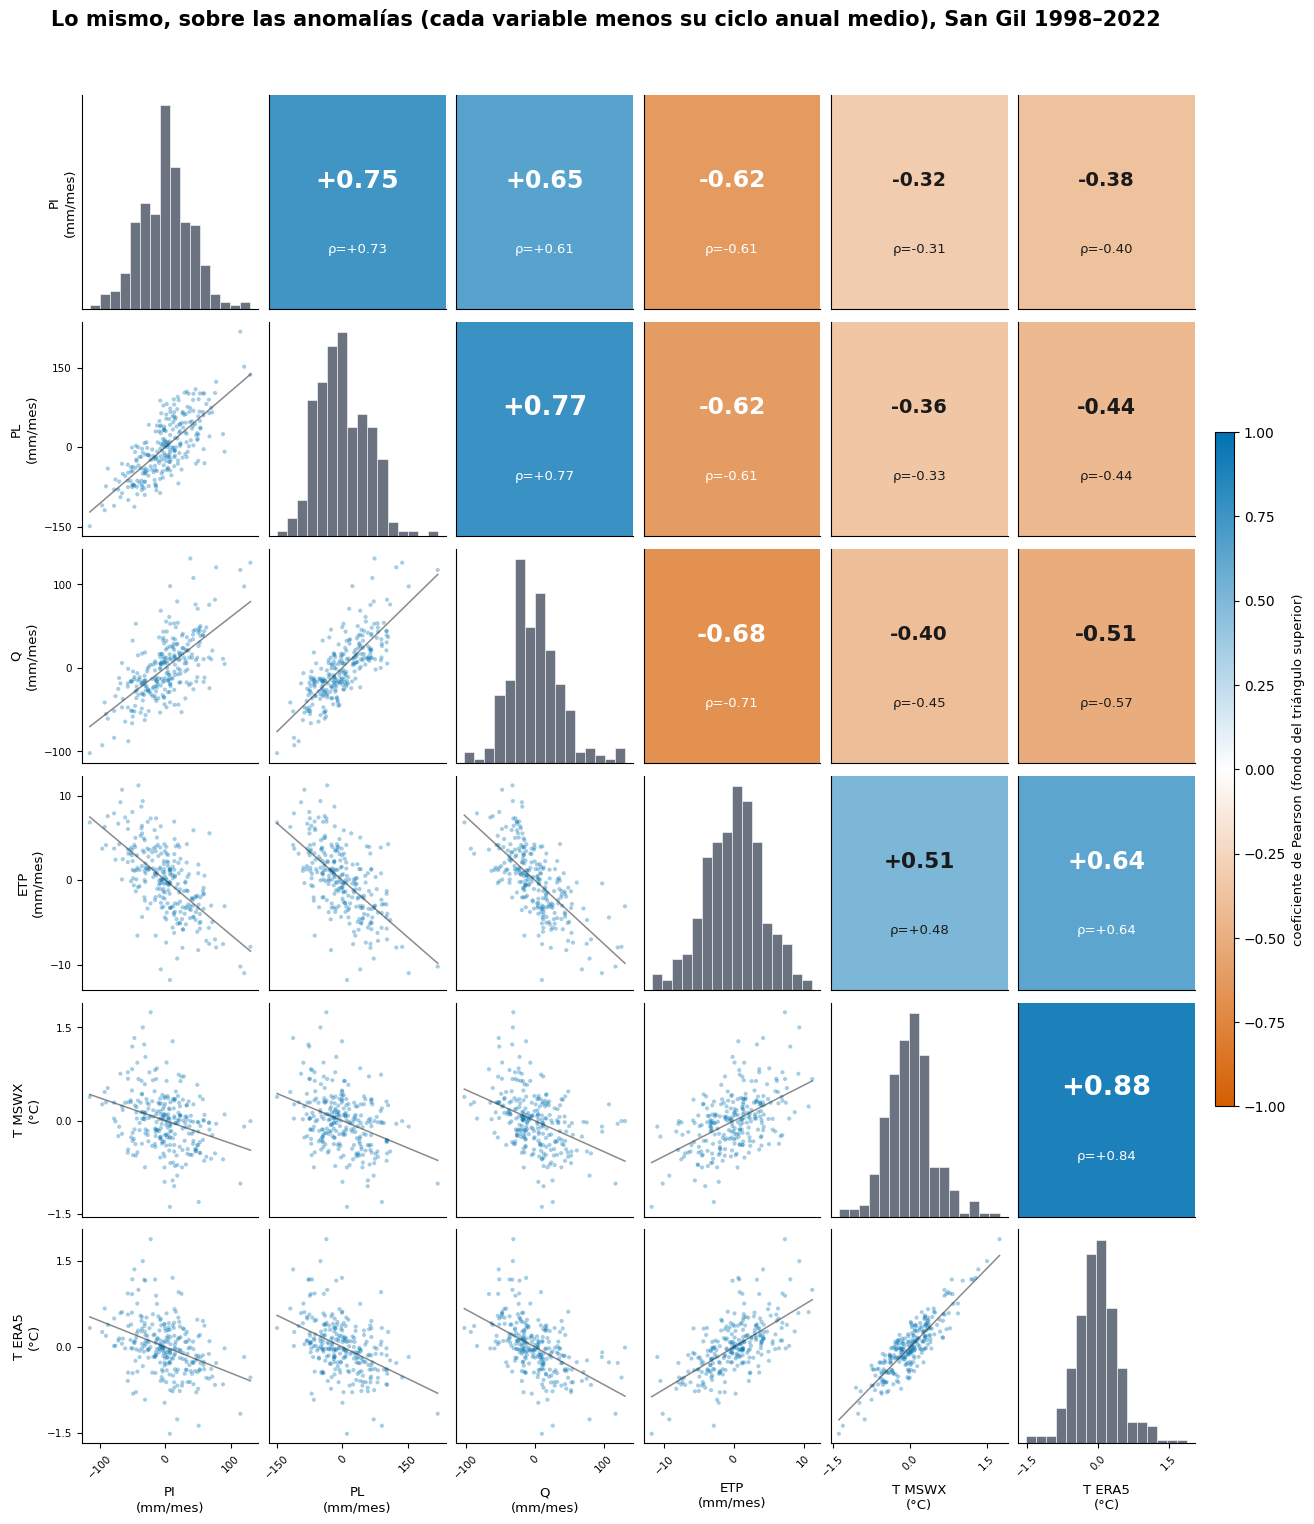

In [29]:
# anomalías: cada variable menos su propio ciclo anual medio (misma definición que usa scripts/16_correlaciones_variables.py)
anomalias_mensuales = (variables_mensuales
                       - variables_mensuales.groupby(variables_mensuales.index.month).transform("mean"))

dibujar_matriz_dispersion(
    anomalias_mensuales, corr_pearson_anom, corr_spearman_anom,
    "Lo mismo, sobre las anomalías (cada variable menos su ciclo anual medio), San Gil 1998–2022",
    OUT_FIG / "matriz_dispersion_anomalias.png",
)
plt.show()

In [30]:
# --- 3: lectura, con los coeficientes de Pearson de out/correlaciones_pearson*.csv ---
_c, _a = corr_pearson, corr_pearson_anom
_dif_max = max(((corr_pearson - corr_spearman).abs().values.max(), (corr_pearson_anom - corr_spearman_anom).abs().values.max()))
_pares = [("PL", "T MSWX"), ("PI", "ETP"), ("Q", "T ERA5")]
display(Markdown(f"""
**Lo que se ve.**

1. **PI y PL correlacionan {_c.loc['PI', 'PL']:.2f}**: comparten calendario de lluvias, pero no dejan de ser dos
   mediciones con métodos distintos —satélite contra red de pluviómetros—.
2. **Q correlaciona {"mejor con PL" if _c.loc['PL', 'Q'] > _c.loc['PI', 'Q'] else "mejor con PI"} ({_c.loc['PL', 'Q']:.2f})
   que con PI ({_c.loc['PI', 'Q']:.2f})**. La elección de fuente de lluvia no es neutral para lo que de verdad importa,
   que es el caudal.
3. **Las dos temperaturas correlacionan {_c.loc['T MSWX', 'T ERA5']:.2f}** pese a la diferencia de nivel entre sus
   medias (1.5): discrepan en el nivel, no en el movimiento.
4. **El hallazgo principal**: las correlaciones con temperatura y ETP **crecen en valor absoluto al quitar el ciclo
   anual**, al revés de lo que suele pasar. Ejemplos: {"; ".join(f"{x}–{y} pasa de {_c.loc[x, y]:.2f} a {_a.loc[x, y]:.2f}" for x, y in _pares)}.
   La lluvia tiene un ciclo anual enorme y la temperatura casi no tiene, y los dos ciclos no guardan relación: en la
   serie cruda esa oscilación de la lluvia diluye la relación; al quitarla aparece el vínculo mes a mes, **negativo
   y físicamente esperable**: los meses anormalmente lluviosos son más nublados, más frescos y con menos ETP.
5. **Pearson y Spearman casi no difieren**: la diferencia mayor entre los dos coeficientes de un mismo par es de
   {_dif_max:.2f}.

**Cómo leer los coeficientes.** Se calculan sobre los **{len(variables_mensuales)} meses en que las seis variables
tienen dato a la vez**, no sobre la muestra propia de cada par, para que sean comparables entre sí.
"""))


**Lo que se ve.**

1. **PI y PL correlacionan 0.85**: comparten calendario de lluvias, pero no dejan de ser dos
   mediciones con métodos distintos —satélite contra red de pluviómetros—.
2. **Q correlaciona mejor con PL (0.82)
   que con PI (0.72)**. La elección de fuente de lluvia no es neutral para lo que de verdad importa,
   que es el caudal.
3. **Las dos temperaturas correlacionan 0.86** pese a la diferencia de nivel entre sus
   medias (1.5): discrepan en el nivel, no en el movimiento.
4. **El hallazgo principal**: las correlaciones con temperatura y ETP **crecen en valor absoluto al quitar el ciclo
   anual**, al revés de lo que suele pasar. Ejemplos: PL–T MSWX pasa de -0.04 a -0.36; PI–ETP pasa de 0.03 a -0.62; Q–T ERA5 pasa de -0.40 a -0.51.
   La lluvia tiene un ciclo anual enorme y la temperatura casi no tiene, y los dos ciclos no guardan relación: en la
   serie cruda esa oscilación de la lluvia diluye la relación; al quitarla aparece el vínculo mes a mes, **negativo
   y físicamente esperable**: los meses anormalmente lluviosos son más nublados, más frescos y con menos ETP.
5. **Pearson y Spearman casi no difieren**: la diferencia mayor entre los dos coeficientes de un mismo par es de
   0.08.

**Cómo leer los coeficientes.** Se calculan sobre los **262 meses en que las seis variables
tienen dato a la vez**, no sobre la muestra propia de cada par, para que sean comparables entre sí.


## 4. Control de calidad de los datos

Antes de sacar conclusiones hay que saber qué tan confiables son las series. Esta sección se hace en
cinco pasos: completitud (4.1), control básico (4.2), anomalías (4.3), registro de decisiones (4.4) y
coherencia hidrológica (4.5). Parte del trabajo ya está hecho en las secciones anteriores —la
disponibilidad de PI y Q en 1.4, la exclusión de Encino 2016-2018 en 1.7, el reemplazo de MSWX por
ERA5-Land en 1.5— y aquí se cita en lugar de repetirse. Las exclusiones de PL que salieron de esta
sección (Pueblo Viejo y los meses en cero) se aplican a todo el notebook.

### 4.1 Completitud: días válidos, meses que se conservan y meses que se excluyen

**El criterio.** Un mes se calcula si le faltan **cuatro días o menos** (`MAX_DIAS_FALTANTES = 4`); con
cinco o más queda vacío. Se aplica con la misma función, `a_mensual`, a toda serie diaria del proyecto.
Un mes que se conserva con días faltantes no se presenta como si estuviera completo:

- los **promedios** (Q en m³/s, temperaturas) son el promedio de los días con dato;
- los **acumulados** (Q en mm, ETP) son ese promedio **por los días del mes**, no la suma de los días que
  hay. Sumar solo los días con dato daría un acumulado parcial presentado como mensual.

**Qué series tienen días.** Q, ETP y las temperaturas llegan en paso diario y se les pueden contar los
días. PI y PL llegan ya mensuales: IMERG es un producto de malla sin huecos, y DHIME entrega el total
mensual que calcula el IDEAM **sin decir con cuántos días se armó**. Para PL solo se puede saber qué
pluviómetros tienen dato cada mes.

In [31]:
# --- 4.1 completitud: días con dato de cada variable diaria, mes a mes, en el período de estudio ---
DIAS_ESTUDIO = pd.date_range("1998-01-01", "2022-12-31", freq="D")
variables_diarias = {
    "Q": san_gil_diario["caudal"],          # CAMELS-COL (IDEAM), m³/s
    "ETP": etp_diaria["etp_era5land"],      # Hargreaves con ERA5-Land (1.8), mm/día
    "T media": era5["t_media"],             # ERA5-Land, °C
    "T máx": era5["t_max"],
    "T mín": era5["t_min"],
}
dias_con_dato = pd.DataFrame({nombre: s.reindex(DIAS_ESTUDIO).notna().resample("MS").sum()
                              for nombre, s in variables_diarias.items()})
dias_con_dato.index = dias_con_dato.index.to_period("M")
dias_faltantes = dias_con_dato.rsub(dias_con_dato.index.days_in_month, axis=0)

# estado de cada mes según la regla: completo, incompleto (se conserva) o excluido
estado_mes = dias_faltantes.apply(lambda col: pd.Series(
    np.select([col == 0, col <= MAX_DIAS_FALTANTES], ["completo", "incompleto"], "excluido"), index=col.index))

# PL: cuántos de los pluviómetros de la cuenca tienen dato cada mes (DHIME no dice cuántos días)
pluvio_con_dato = (pluvio_por_mes[PLUVIO_EN_CUENCA].reindex(PERIODO_ESTUDIO).notna().sum(axis=1))

resumen_41 = pd.DataFrame({
    nombre: {"paso": "diario",
             "meses completos": int((estado_mes[nombre] == "completo").sum()),
             "meses incompletos que se conservan": int((estado_mes[nombre] == "incompleto").sum()),
             "meses excluidos": int((estado_mes[nombre] == "excluido").sum())}
    for nombre in variables_diarias}).T
_pi = variables_resumen["PI (mm/mes)"]
resumen_41.loc["PI"] = ["mensual", int(_pi.notna().sum()), "no aplica", int(_pi.isna().sum())]
resumen_41.loc["PL"] = ["mensual", int((pluvio_con_dato > 0).sum()), "no aplica", int((pluvio_con_dato == 0).sum())]
resumen_41 = resumen_41.loc[["PI", "PL", "Q", "ETP", "T media", "T máx", "T mín"]]
print(f"PL: entre {pluvio_con_dato.min()} y {pluvio_con_dato.max()} pluviómetros con dato por mes "
      f"(de {len(PLUVIO_EN_CUENCA)}); {int((pluvio_con_dato == len(PLUVIO_EN_CUENCA)).sum())} meses con todos")
resumen_41

PL: entre 4 y 7 pluviómetros con dato por mes (de 7); 132 meses con todos


,paso,meses completos,meses incompletos que se conservan,meses excluidos
PI,mensual,300,no aplica,0
PL,mensual,300,no aplica,0
Q,diario,199,63,38
ETP,diario,300,0,0
T media,diario,300,0,0
T máx,diario,300,0,0
T mín,diario,300,0,0


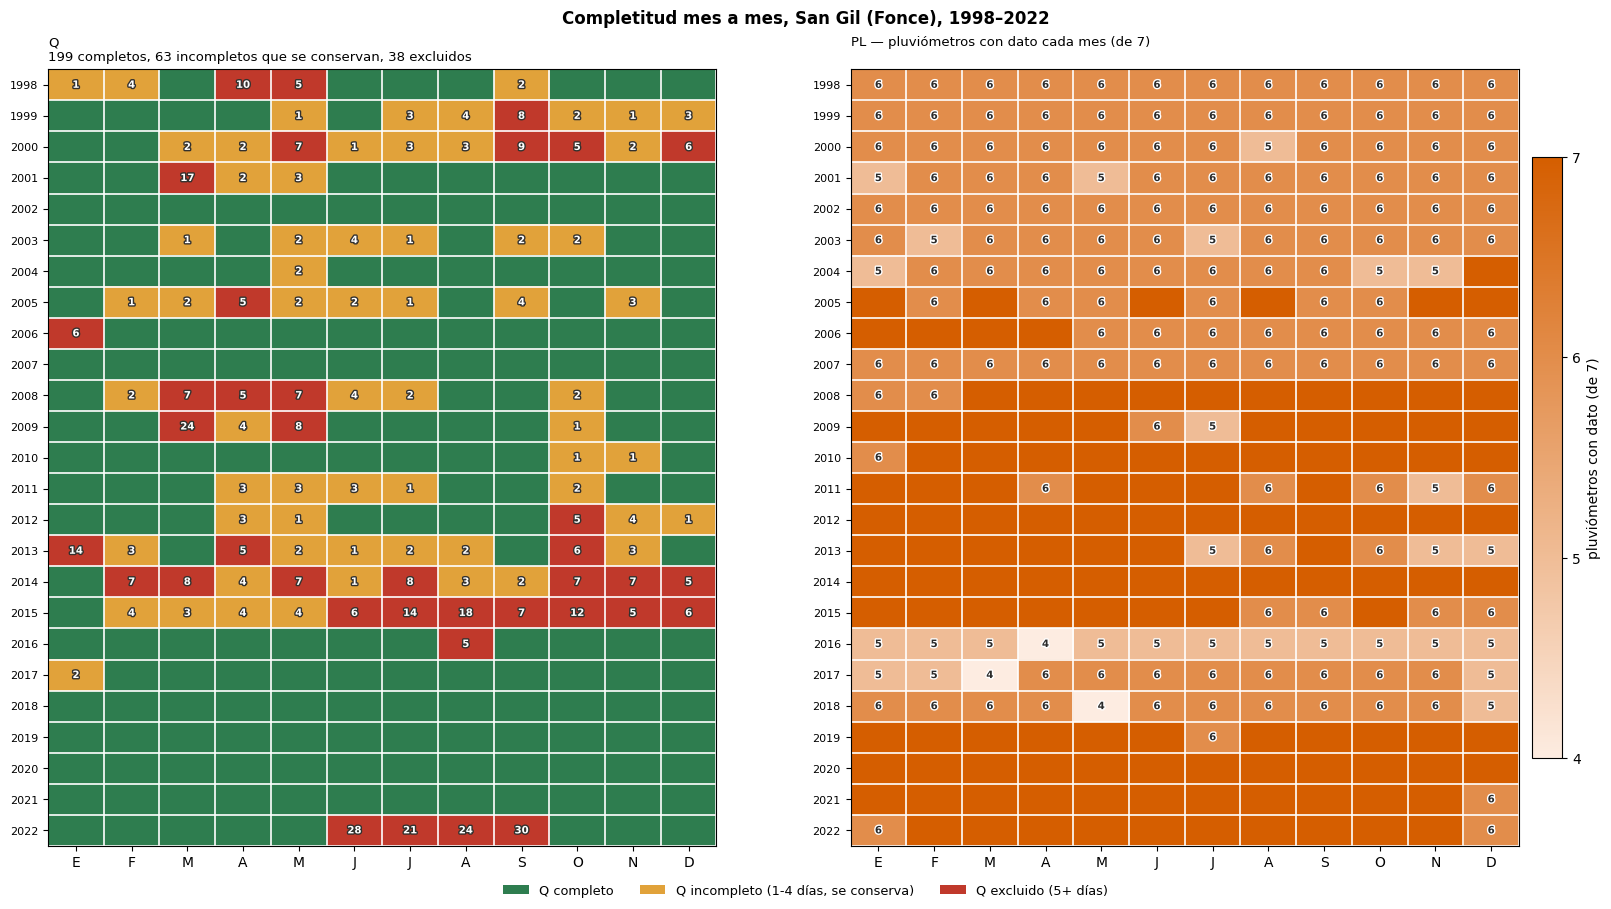

In [32]:
# --- 4.1: la matriz completa de completitud mes a mes (la versión detallada de resumen_41).
#     Izquierda: estado de Q (completo/incompleto/excluido), con los días faltantes escritos en las
#     celdas que no están completas. Q es la única variable diaria del proyecto con huecos.
#     Derecha: PL, cuántos de los 7 pluviómetros de la cuenca aportaron dato cada mes. ---
VERDE, AMBAR, ROJO = "#2E7D4F", "#E1A23A", "#C0392B"
COLOR_PL = "#D55E00"   # mismo naranja que identifica a PL en el resto del notebook (sección 1.2)

anios = sorted(estado_mes.index.year.unique())          # 1998 ... 2022, uno por fila
MES_INI = ["E", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]
N_PLUVIOMETROS = len(PLUVIO_EN_CUENCA)

fig, (izq, der) = plt.subplots(1, 2, figsize=(16, 9), constrained_layout=True,
                               gridspec_kw={"wspace": 0.12})

# --- panel izquierdo: estado de Q ---
codigo_estado = {"completo": 0, "incompleto": 1, "excluido": 2}
estado_q = estado_mes["Q"].map(codigo_estado).values.reshape(len(anios), 12)
faltan_q = dias_faltantes["Q"].values.reshape(len(anios), 12)

izq.imshow(estado_q, cmap=ListedColormap([VERDE, AMBAR, ROJO]), vmin=0, vmax=2,
           aspect="auto", interpolation="nearest")
for fila in range(len(anios)):
    for col in range(12):
        if estado_q[fila, col] != 0:      # solo se etiquetan los meses que no están completos
            izq.text(col, fila, int(faltan_q[fila, col]), ha="center", va="center",
                     fontsize=7.3, color="white", fontweight="bold",
                     path_effects=[pe.withStroke(linewidth=2, foreground="#33312E")])

n_completos = int((estado_mes["Q"] == "completo").sum())
n_incompletos = int((estado_mes["Q"] == "incompleto").sum())
n_excluidos = int((estado_mes["Q"] == "excluido").sum())
# título en dos líneas: el texto completo no cabe en el ancho del panel en una sola línea
izq.set_title("Q\n"
              f"{n_completos} completos, {n_incompletos} incompletos que se conservan, "
              f"{n_excluidos} excluidos",
              fontsize=9.5, loc="left")

# --- panel derecho: PL, pluviómetros con dato cada mes (de N_PLUVIOMETROS) ---
pl = pluvio_con_dato.reindex(estado_mes.index).values.reshape(len(anios), 12)
cmap_pl = LinearSegmentedColormap.from_list("pl_naranja", ["#FDECE1", COLOR_PL])
norm_pl = Normalize(vmin=pluvio_con_dato.min(), vmax=N_PLUVIOMETROS)
im_pl = der.imshow(pl, cmap=cmap_pl, norm=norm_pl, aspect="auto", interpolation="nearest")
for fila in range(len(anios)):
    for col in range(12):
        valor = int(pl[fila, col])
        if valor != N_PLUVIOMETROS:       # solo se etiquetan los meses sin los 7
            der.text(col, fila, valor, ha="center", va="center", fontsize=7.3,
                     color="#2B2B2B", fontweight="bold",
                     path_effects=[pe.withStroke(linewidth=2, foreground="white")])
der.set_title(f"PL — pluviómetros con dato cada mes (de {N_PLUVIOMETROS})\n ",
              fontsize=9.5, loc="left")
barra = fig.colorbar(im_pl, ax=der, orientation="vertical", fraction=0.045, pad=0.02,
                     label=f"pluviómetros con dato (de {N_PLUVIOMETROS})")
barra.set_ticks(range(int(pluvio_con_dato.min()), N_PLUVIOMETROS + 1))    # se cuentan estaciones: enteros

# --- formato común: años en filas (1998 arriba), meses en columnas, grilla blanca fina (como en 1.4) ---
for eje in (izq, der):
    eje.set_xticks(range(12), MES_INI)
    eje.set_yticks(range(len(anios)), anios, fontsize=8)
    eje.set_xticks(np.arange(-.5, 12, 1), minor=True)
    eje.set_yticks(np.arange(-.5, len(anios), 1), minor=True)
    eje.grid(which="minor", color="white", lw=1.2)
    eje.tick_params(which="minor", length=0)

parches = [Patch(facecolor=VERDE, label="Q completo"),
           Patch(facecolor=AMBAR, label="Q incompleto (1-4 días, se conserva)"),
           Patch(facecolor=ROJO, label="Q excluido (5+ días)")]
fig.legend(handles=parches, loc="outside lower center", ncol=3, frameon=False, fontsize=9.3)
fig.suptitle("Completitud mes a mes, San Gil (Fonce), 1998–2022", fontsize=12, fontweight="semibold")
plt.show()


In [33]:
# --- 4.1: lectura del mapa de completitud ---
_q = estado_mes["Q"].value_counts()
_exc_por_anio = (estado_mes["Q"] == "excluido").groupby(estado_mes.index.year).sum()
_peores = _exc_por_anio[_exc_por_anio == _exc_por_anio.max()]
display(Markdown(f"""
**Lo que se ve.**

1. **Solo Q pierde meses**: {_q.get('excluido', 0)} excluidos y {_q.get('incompleto', 0)} incompletos que se conservan,
   de {len(estado_mes)}. Los peores años son {" y ".join(str(a) for a in _peores.index)}, con {_peores.max()} meses
   excluidos cada uno. (La temperatura de MSWX dentro de CAMELS-COL tiene los mismos huecos, pero el proyecto no la usa.)
2. **ERA5-Land no tiene huecos**, ni la ETP que se calcula con ella: es un reanálisis, un modelo que entrega un valor
   todos los días. Que esté completo no dice nada de su exactitud; eso se revisa en 4.2.
3. **PI y PL tienen dato los {len(estado_mes)} meses, pero PL no siempre con la misma red**: cada mes aportan entre
   {pluvio_con_dato.min()} y {pluvio_con_dato.max()} pluviómetros, y los {len(PLUVIO_EN_CUENCA)} juntos solo en
   {int((pluvio_con_dato == len(PLUVIO_EN_CUENCA)).sum())} meses. Las franjas claras son sobre todo los tramos excluidos
   (Pueblo Viejo antes de 2005 y Encino 2016-2018). Cuánto mueve eso a PL se estima en 4.3.
"""))


**Lo que se ve.**

1. **Solo Q pierde meses**: 38 excluidos y 63 incompletos que se conservan,
   de 300. Los peores años son 2014 y 2015, con 7 meses
   excluidos cada uno. (La temperatura de MSWX dentro de CAMELS-COL tiene los mismos huecos, pero el proyecto no la usa.)
2. **ERA5-Land no tiene huecos**, ni la ETP que se calcula con ella: es un reanálisis, un modelo que entrega un valor
   todos los días. Que esté completo no dice nada de su exactitud; eso se revisa en 4.2.
3. **PI y PL tienen dato los 300 meses, pero PL no siempre con la misma red**: cada mes aportan entre
   4 y 7 pluviómetros, y los 7 juntos solo en
   132 meses. Las franjas claras son sobre todo los tramos excluidos
   (Pueblo Viejo antes de 2005 y Encino 2016-2018). Cuánto mueve eso a PL se estima en 4.3.


In [34]:
# --- los meses de Q que se excluyen, y los incompletos que se conservan, año por año ---
NOMBRE_MES = dict(enumerate(["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"], 1))


def meses_por_anio(periodos):
    return {anio: ", ".join(NOMBRE_MES[p.month] for p in grupo)
            for anio, grupo in pd.Series(periodos).groupby(pd.Series(periodos).dt.year)} if len(periodos) else {}


q_excluidos = estado_mes.index[estado_mes["Q"] == "excluido"]
q_incompletos = estado_mes.index[estado_mes["Q"] == "incompleto"]
pd.DataFrame({"Q excluidos": pd.Series(meses_por_anio(q_excluidos)),
              "Q incompletos (se conservan)": pd.Series(meses_por_anio(q_incompletos))}).fillna("").sort_index()

,Q excluidos,Q incompletos (se conservan)
1998,"abr, may","ene, feb, sep"
1999,sep,"may, jul, ago, oct, nov, dic"
2000,"may, sep, oct, dic","mar, abr, jun, jul, ago, nov"
2001,mar,"abr, may"
2003,,"mar, may, jun, jul, sep, oct"
2004,,may
2005,abr,"feb, mar, may, jun, jul, sep, nov"
2006,ene,
2008,"mar, abr, may","feb, jun, jul, oct"
2009,"mar, may","abr, oct"


In [35]:
# --- ¿por qué cuatro días? Prueba sobre los meses COMPLETOS de Q: se les quita un bloque de k días
#     seguidos (el peor caso: una racha, no días sueltos) en cada posición posible del mes, y se mide
#     cuánto se aleja el caudal medio del mes del verdadero. Nada es aleatorio: se prueban todas las
#     posiciones de todos los meses completos. ---
q_estudio = san_gil_diario["caudal"].reindex(DIAS_ESTUDIO)
meses_completos_q = [g.to_numpy() for _, g in q_estudio.groupby(q_estudio.index.to_period("M"))
                     if g.notna().all()]

filas = []
for k in range(1, 8):
    errores = []
    for dias in meses_completos_q:
        verdadero = dias.mean()
        for inicio in range(len(dias) - k + 1):
            quedan = np.delete(dias, range(inicio, inicio + k))
            errores.append(abs(quedan.mean() / verdadero - 1) * 100)
    errores = np.array(errores)
    filas.append({"días faltantes (seguidos)": k, "error mediano (%)": np.median(errores),
                  "error p95 (%)": np.percentile(errores, 95), "error máximo (%)": errores.max(),
                  "meses de Q que se conservarían": int((dias_faltantes["Q"] <= k).sum())})
prueba_umbral = pd.DataFrame(filas).set_index("días faltantes (seguidos)")
fila_0 = pd.DataFrame({"meses de Q que se conservarían": [int((dias_faltantes["Q"] == 0).sum())]}, index=[0])
prueba_umbral = pd.concat([fila_0, prueba_umbral]).rename_axis("días faltantes (seguidos)")
print(f"{len(meses_completos_q)} meses completos de Q usados en la prueba")
prueba_umbral.round(1)

199 meses completos de Q usados en la prueba


,meses de Q que se conservarían,error mediano (%),error p95 (%),error máximo (%)
días faltantes (seguidos),,,,
0,199,NaN,NaN,NaN
1,215,0.8,2.5,9.4
2,237,1.5,4.7,14.9
3,251,2.2,6.8,21.9
4,262,2.9,8.8,24.9
5,271,3.5,10.7,27.9
6,276,4.2,12.6,31.0
7,284,4.8,14.6,33.0


**Por qué cuatro días.** El error crece parejo con cada día que falta —la mediana sube unos 0.7 puntos por
día— y no hay un salto que marque un límite natural. Con 4 días seguidos faltantes, el peor caso, el
caudal medio del mes se aleja del verdadero un 2.9 % en la mediana y un 8.8 % en el 95 % de los casos
(24.9 % en el peor). A cambio, el umbral conserva 262 meses de Q en vez de 199. Es una decisión, no un
resultado: con 3 días quedarían 251 meses y el percentil 95 bajaría a 6.8 %.

In [36]:
# --- lo que se corrigió: la suma de los días con dato contra el acumulado de a_mensual (promedio x días
#     del mes), en los meses incompletos de Q en mm (la única serie acumulada del proyecto con huecos) ---
comparacion_sumas = {}
for nombre, columna in (("Q (mm)", "caudal_mm"),):
    s = san_gil_diario[columna].reindex(DIAS_ESTUDIO)
    suma_parcial = s.resample("MS").sum()
    suma_parcial.index = suma_parcial.index.to_period("M")
    acumulado = a_mensual_del_periodo(s, "sum")
    incompletos = estado_mes.index[estado_mes["Q"] == "incompleto"]
    faltaba = (1 - suma_parcial[incompletos] / acumulado[incompletos]) * 100
    comparacion_sumas[nombre] = {"meses incompletos": len(incompletos),
                                 "faltaba en promedio (%)": faltaba.mean(),
                                 "faltaba como máximo (%)": faltaba.max()}
comparacion_sumas = pd.DataFrame(comparacion_sumas).T

# efecto sobre el coeficiente de escorrentía del período (Q / P, en los meses con los dos datos)
_q_parcial = san_gil_diario["caudal_mm"].reindex(DIAS_ESTUDIO).resample("MS").sum()
_q_parcial.index = _q_parcial.index.to_period("M")
_q_parcial = _q_parcial.where(estado_mes["Q"] != "excluido")
_q_acumulado = a_mensual_del_periodo(san_gil_diario["caudal_mm"], "sum")
for nombre_p, p in (("PL", variables_resumen["PL (mm/mes)"]), ("PI", variables_resumen["PI (mm/mes)"])):
    coef = {et: (lambda b: b.q.sum() / b.p.sum())(pd.DataFrame({"p": p, "q": q}).dropna())
            for et, q in (("antes", _q_parcial), ("ahora", _q_acumulado))}
    print(f"coeficiente de escorrentía con {nombre_p}: {coef['antes']:.3f} sumando los días con dato, "
          f"{coef['ahora']:.3f} con el acumulado del mes")
comparacion_sumas.round(1)

coeficiente de escorrentía con PL: 0.518 sumando los días con dato, 0.529 con el acumulado del mes
coeficiente de escorrentía con PI: 0.593 sumando los días con dato, 0.605 con el acumulado del mes


,meses incompletos,faltaba en promedio (%),faltaba como máximo (%)
Q (mm),63.0,7.7,14.3


In [37]:
# --- 4.1: lectura de la corrección de los acumulados ---
_q_mm = san_gil_diario["caudal_mm"].reindex(DIAS_ESTUDIO)
_parcial = _q_mm.resample("MS").sum()
_parcial.index = _parcial.index.to_period("M")
_parcial = _parcial.where(estado_mes["Q"] != "excluido")
_acum = a_mensual_del_periodo(san_gil_diario["caudal_mm"], "sum")
_coef = {n: {e: (lambda b: b.q.sum() / b.p.sum())(pd.DataFrame({"p": p, "q": q}).dropna())
             for e, q in (("antes", _parcial), ("ahora", _acum))}
         for n, p in (("PL", variables_resumen["PL (mm/mes)"]), ("PI", variables_resumen["PI (mm/mes)"]))}
_f = comparacion_sumas.loc["Q (mm)"]
display(Markdown(f"""
**Lo que se corrigió.** Hasta esta revisión, el caudal en mm se sumaba día a día (y también la ETP de CAMELS-COL,
que ya no se usa). Así, los {int(_f['meses incompletos'])} meses incompletos quedaban en promedio un
{_f['faltaba en promedio (%)']:.1f} % por debajo, y hasta un {_f['faltaba como máximo (%)']:.1f} %, presentados como
acumulados completos. Ahora `a_mensual` da el acumulado como el promedio de los días con dato por los días del mes.
En el balance el efecto es pequeño: el coeficiente de escorrentía pasa de {_coef['PL']['antes']:.3f} a
{_coef['PL']['ahora']:.3f} con PL y de {_coef['PI']['antes']:.3f} a {_coef['PI']['ahora']:.3f} con PI.
"""))


**Lo que se corrigió.** Hasta esta revisión, el caudal en mm se sumaba día a día (y también la ETP de CAMELS-COL,
que ya no se usa). Así, los 63 meses incompletos quedaban en promedio un
7.7 % por debajo, y hasta un 14.3 %, presentados como
acumulados completos. Ahora `a_mensual` da el acumulado como el promedio de los días con dato por los días del mes.
En el balance el efecto es pequeño: el coeficiente de escorrentía pasa de 0.518 a
0.529 con PL y de 0.593 a 0.605 con PI.


### 4.2 Control de calidad básico

Se revisan los archivos **tal como se descargaron**, antes de que el procesamiento los ordene, los
reindexe o los agregue: fechas legibles y en orden, duplicados, unidades, códigos de faltante (−9999,
−999, 9999…), valores imposibles según la física de cada variable y banderas de calidad. Cada variable se
juzga por lo suyo: una temperatura negativa es posible, una lluvia o un caudal negativos no.

Los chequeos corren en `scripts/07b_control_calidad_basico.py`, porque necesitan los archivos crudos (el
zip de DHIME, los 300 archivos de texto de IMERG, los 25 anuales de ERA5-Land). Cada uno queda con un
resultado:

- **sin problemas**: el chequeo se hizo y pasó;
- **anotado**: no es un error, pero hay que tenerlo presente;
- **revisar**: algo que puede ser un error y se sigue en 4.3;
- **no disponible**: la fuente no trae con qué hacer el chequeo.

In [38]:
# --- 4.2: resultado de cada chequeo (tabla completa) ---
print(control_calidad.resultado.value_counts().to_string())
with pd.option_context("display.max_colwidth", None):
    display(control_calidad.style.hide(axis="index")
            .map(lambda v: {"revisar": "background-color: #F7D9C4", "anotado": "background-color: #FFF4C2",
                            "no disponible": "color: #8B949B"}.get(v, ""), subset=["resultado"])
            .set_properties(subset=["detalle"], **{"text-align": "left", "white-space": "normal"}))

resultado
sin problemas    25
no disponible     3
anotado           2
revisar           1


fuente,chequeo,resultado,detalle
CAMELS-COL (diario de San Gil),fechas legibles,sin problemas,"14 410 filas, 0 fechas que no se pueden leer; formato día/mes/año; de 1981-01-01 a 2022-12-31"
CAMELS-COL (diario de San Gil),fechas en orden,sin problemas,orden cronológico estricto
CAMELS-COL (diario de San Gil),fechas duplicadas,sin problemas,0 fechas repetidas
CAMELS-COL (diario de San Gil),días ausentes en 1998-2022,anotado,"530 de 9 131 días no tienen fila: el archivo omite el día entero cuando no hay caudal, en vez de marcarlo como faltante; son los huecos que cuenta la regla de completitud"
CAMELS-COL (diario de San Gil),"códigos de faltante (−9999, −999, 9999…) y vacíos",sin problemas,0 valores con códigos de faltante y 0 casillas vacías en las filas que existen
CAMELS-COL (diario de San Gil),Q ≥ 0 (un caudal no puede ser negativo),sin problemas,"0 días negativos; mínimo 17.40 m³/s, máximo 520.0 m³/s; 0 días con caudal exactamente 0"
CAMELS-COL (diario de San Gil),P de CHIRPS ≥ 0,sin problemas,0 días negativos (la columna viene en el archivo pero el proyecto no la usa)
CAMELS-COL (diario de San Gil),ETP de CAMELS-COL ≥ 0,sin problemas,0 días negativos (la columna viene en el archivo pero el proyecto no la usa)
CAMELS-COL (diario de San Gil),T de MSWX en rango físico (-15 a 45 °C),sin problemas,"T mín entre 7.3 y 16.2 °C, T máx entre 15.1 y 26.4 °C; 0 valores fuera de rango"
CAMELS-COL (diario de San Gil),T máx ≥ T mín,sin problemas,0 días con la máxima por debajo de la mínima


**Lo que se ve.**

1. **No hay nada roto en ninguna fuente.** No hay fechas ilegibles, fuera de orden ni duplicadas; no hay
   códigos de faltante disfrazados de número (−9999 y parecidos); no hay lluvia, caudal ni ETP negativos;
   no hay temperaturas imposibles ni días con la máxima por debajo de la mínima.
2. **Las unidades se confirman, no se suponen.**
   - **Q:** el archivo de CAMELS-COL no dice en qué viene el caudal. Pasando su caudal medio a mm/día se
     obtiene exactamente el `q_mean` que publica su archivo de firmas (3.58 mm/día), así que está en m³/s.
   - **IMERG:** su tasa en mm/h, multiplicada por las horas del mes, reproduce el archivo que usa el
     análisis.
   - **ERA5-Land:** viene entre 5 y 25 °C, ya convertida de kelvin.
3. **CAMELS-COL no marca los faltantes: los omite.** En 1998-2022 le faltan 530 días, que no aparecen
   como filas vacías sino que no aparecen. Es la misma completitud de 4.1, vista desde el archivo.
4. **Banderas.**
   - **CAMELS-COL:** no trae ninguna, ni el nivel de aprobación del IDEAM.
   - **DHIME:** sí trae, y el 85 % de los registros de PL son **preliminares** (el IDEAM aún no los
     validó). No es una marca de error, pero sí un recordatorio de que la red no está revisada.
   - **IMERG:** tiene variables de error que no se descargaron.
5. **Lo único para revisar: 9 meses de pluviómetro con exactamente 0 mm.**
   - Pavas Las: julio o agosto de 2000, 2001, 2009, 2013 y 2019, y mayo de 2018.
   - Pueblo Viejo: febrero de 2020.
   - Valle de San José: diciembre de 2017 y de 2021.

   Un mes sin una gota es posible en la temporada seca, pero en esta cuenca es raro. Se sigue en 4.3,
   comparándolos con los pluviómetros vecinos y con PI.

In [39]:
# --- 4.2: qué es cada dato: medido, estimado, simulado o calculado, y si tiene relleno ---
with pd.option_context("display.max_colwidth", None):
    display(naturaleza_fuentes.style.hide(axis="index")
            .set_properties(**{"text-align": "left", "white-space": "normal"}))

variable,fuente,tipo,cómo se obtiene,relleno
Q,"IDEAM, vía CAMELS-COL",observado,"el IDEAM registra el nivel del río en la estación y lo convierte en caudal con la curva de gasto de la estación, como en toda estación hidrométrica; la curva no viene en CAMELS-COL",no se ve relleno: los días sin dato faltan (530 en 1998-2022) y CAMELS-COL no describe ninguno
PL,"IDEAM, portal DHIME",observado,"total mensual de cada pluviómetro, calculado por el IDEAM; 85 % de los registros son preliminares",no se sabe con cuántos días se armó cada total mensual; los meses sin dato no aparecen; el proyecto excluyó Encino 2016-2018
PI,"NASA, IMERG Final V07",estimado,"estimación satelital (sensores de microondas e infrarrojo) ajustada mes a mes con pluviómetros (análisis del GPCC), en malla de 0.1° (Huffman et al., 2023)",completo por construcción: el producto da un valor en cada celda y cada mes
T,"ECMWF, ERA5-Land",simulado,"reanálisis: un modelo de superficie terrestre forzado con el reanálisis ERA5, en malla de 0.1° (Muñoz-Sabater et al.)",completo por construcción: no hay huecos que rellenar
ETP,el proyecto (06b_etp_hargreaves.py),calculado,fórmula de Hargreaves y Samani (1985) con la temperatura de ERA5-Land,"completa, porque ERA5-Land lo es"


**Qué es cada dato.** Solo Q y PL vienen de un instrumento en la cuenca, y ninguno de los dos tiene
valores rellenados: sus huecos se quedan como huecos. PI es una estimación satelital ajustada con
pluviómetros, T es la salida de un modelo (un reanálisis) y la ETP se calcula a partir de ese modelo. Que
PI, T y ETP no tengan huecos no quiere decir que sean exactas: no tienen huecos porque un modelo o un
algoritmo siempre da un número.

**Revisión a mano de un mes: octubre de 2019.** Se escogió porque está completo en Q (no le falta ningún
día) y tiene dato en los 7 pluviómetros, y cae en la temporada de lluvias. Para cada variable se rehace a
la vista la agregación y la conversión de unidades, desde el dato de partida, y se compara con el valor
que usa el análisis.

In [40]:
# --- 4.2: revisión a mano de octubre de 2019 (el mismo MES_REVISADO de 07b_control_calidad_basico.py) ---
MES_REVISADO = pd.Period("2019-10", "M")
n_dias = MES_REVISADO.days_in_month
area_m2 = AREA_KM2[ID_PRINCIPAL] * 1e6

# Q: los caudales diarios del mes, su promedio, y la conversión de m³/s a lámina de agua en mm
q_dias = san_gil_diario.loc[str(MES_REVISADO), "caudal"]
print(f"Q diario, {q_dias.notna().sum()} de {n_dias} días (m³/s):")
print(", ".join(f"{v:.1f}" for v in q_dias))
q_medio = q_dias.sum() / n_dias                                   # m³/s
q_volumen = q_medio * 86400 * n_dias                              # m³ en el mes
q_lamina = q_volumen / area_m2 * 1000                             # mm sobre la cuenca
print(f"  promedio = {q_dias.sum():.1f} / {n_dias} = {q_medio:.2f} m³/s")
print(f"  volumen  = {q_medio:.2f} m³/s × 86 400 s × {n_dias} días = {q_volumen / 1e6:.1f} millones de m³")
print(f"  lámina   = {q_volumen / 1e6:.1f} millones de m³ / {AREA_KM2[ID_PRINCIPAL]:,.2f} km² = {q_lamina:.2f} mm".replace(",", " "))

# PI: cada píxel de IMERG en mm/h (archivo crudo) × horas del mes, promediado con su peso de área
pi_mano = (pi_mes_revisado.mm_en_el_mes * pi_mes_revisado.peso).sum()
print(f"\nPI: {len(pi_mes_revisado)} píxeles; por ejemplo el de mayor peso, "
      f"{pi_mes_revisado.loc[pi_mes_revisado.peso.idxmax(), 'mm_por_hora']:.4f} mm/h × {pi_mes_revisado.horas_del_mes.iloc[0]} h = "
      f"{pi_mes_revisado.loc[pi_mes_revisado.peso.idxmax(), 'mm_en_el_mes']:.1f} mm, con peso "
      f"{pi_mes_revisado.peso.max():.3f}; suma de pesos = {pi_mes_revisado.peso.sum():.3f}")

# PL: el total de cada pluviómetro ese mes y su promedio
pl_estaciones = pluvio_por_mes.loc[MES_REVISADO, PLUVIO_EN_CUENCA].rename(PLUVIOMETROS)
print("\nPL, total del mes por pluviómetro (mm):")
print(pl_estaciones.round(1).to_string())
pl_mano = pl_estaciones.sum() / pl_estaciones.notna().sum()

# T media y ETP: promedio y suma de los días de ERA5-Land y de Hargreaves
t_mano = era5.loc[str(MES_REVISADO), "t_media"].sum() / n_dias
etp_mano = etp_diaria.loc[str(MES_REVISADO), "etp_era5land"].sum()

revision_a_mano = pd.DataFrame({
    "a mano": [q_medio, q_lamina, pi_mano, pl_mano, t_mano, etp_mano],
    "lo que usa el análisis": [variables_resumen.loc[MES_REVISADO, "Q (m³/s)"], q_mensual[MES_REVISADO],
                               imerg[(imerg.id_estacion == ID_PRINCIPAL) & (imerg.periodo == MES_REVISADO)].p_imerg_mm.iloc[0],
                               variables_resumen.loc[MES_REVISADO, "PL (mm/mes)"],
                               variables_resumen.loc[MES_REVISADO, "T media (°C)"],
                               etp_mensual.loc[MES_REVISADO, "Hargreaves con ERA5-Land"]],
}, index=["Q (m³/s)", "Q (mm)", "PI (mm)", "PL (mm)", "T media (°C)", "ETP (mm)"])
revision_a_mano["diferencia"] = revision_a_mano["a mano"] - revision_a_mano["lo que usa el análisis"]
revision_a_mano.round(3)

Q diario, 31 de 31 días (m³/s):
72.8, 61.4, 48.4, 44.8, 42.5, 48.4, 44.3, 80.1, 81.6, 70.3, 66.4, 124.0, 70.8, 62.3, 63.1, 74.0, 122.9, 129.3, 162.7, 93.6, 90.5, 131.3, 155.2, 165.4, 116.6, 99.0, 88.2, 73.6, 61.5, 53.8, 61.9
  promedio = 2660.7 / 31 = 85.83 m³/s
  volumen  = 85.83 m³/s × 86 400 s × 31 días = 229.9 millones de m³
  lámina   = 229.9 millones de m³ / 2 098.85 km² = 109.53 mm

PI: 30 píxeles; por ejemplo el de mayor peso, 0.3140 mm/h × 744 h = 233.6 mm, con peso 0.058; suma de pesos = 1.000

PL, total del mes por pluviómetro (mm):
codigo
Encino                      286.2
Charalá                     271.7
Pavas Las                   173.0
Pueblo Viejo                116.0
Coromoro                    264.2
Valle de San Jose           236.8
Escuela Agricola Mogotes    255.8


,a mano,lo que usa el análisis,diferencia
Q (m³/s),85.828,85.828,0.000
Q (mm),109.527,109.527,0.000
PI (mm),259.773,259.770,0.003
PL (mm),229.100,229.100,0.000
T media (°C),14.505,14.505,0.000
ETP (mm),104.719,104.719,0.000


In [41]:
# --- 4.2: un mes incompleto, febrero de 1998 (le faltan días): la suma de los días que hay contra el
#     acumulado del mes que da a_mensual (promedio de los días con dato × días del mes) ---
MES_INCOMPLETO = pd.Period("1998-02", "M")
dias_inc = san_gil_diario.loc[str(MES_INCOMPLETO), "caudal_mm"]
n_con = int(dias_inc.notna().sum())
print(f"{MES_INCOMPLETO}: {n_con} de {MES_INCOMPLETO.days_in_month} días con caudal")
print(f"  suma de los días que hay         = {dias_inc.sum():.2f} mm   (acumulado parcial)")
print(f"  promedio × días del mes          = {dias_inc.mean():.3f} × {MES_INCOMPLETO.days_in_month} = "
      f"{dias_inc.mean() * MES_INCOMPLETO.days_in_month:.2f} mm")
print(f"  lo que da a_mensual (sección 1.3) = {q_mensual[MES_INCOMPLETO]:.2f} mm")

1998-02: 24 de 28 días con caudal
  suma de los días que hay         = 42.44 mm   (acumulado parcial)
  promedio × días del mes          = 1.768 × 28 = 49.52 mm
  lo que da a_mensual (sección 1.3) = 49.52 mm


**Lo que se ve.** En las seis cuentas, lo hecho a mano coincide con lo que usa el análisis, salvo
redondeos: la agregación diaria a mensual, el paso de m³/s a mm con el área del polígono, el de mm/h a
mm/mes de IMERG con su promedio ponderado por área, y el promedio de la red de pluviómetros. En el mes
incompleto se ve lo que corrigió 4.1: la suma de los 24 días que hay sale menor que el acumulado del mes,
y `a_mensual` entrega el acumulado, no la suma parcial.

### 4.3 Anomalías: saltos, secuencias constantes, extremos aislados y cambios de cobertura

La sección 4.2 revisó que cada dato fuera posible. Esta revisa que las series sean **coherentes en el
tiempo**. Las pruebas corren en `scripts/07c_anomalias.py`:

- **Saltos bruscos.** Un cambio de estación, de instrumento o de producto deja un escalón: desde cierta
  fecha, la serie mide sistemáticamente más o menos que sus vecinas.
  - **Curva de doble masa:** el acumulado de la serie contra el acumulado de una referencia. Si las dos
    miden lo mismo en proporción, es una recta; un salto la quiebra.
  - **Prueba de Pettitt (1979):** busca el punto que mejor parte la serie en dos niveles distintos y da la
    probabilidad *p* de que eso ocurra por azar. Se aplica al logaritmo de la razón serie/referencia; es
    significativo si *p* < 0.05.
  - **Con qué se compara cada serie:** cada pluviómetro contra el promedio de los demás; PI y Q contra PL.
  - **Por rondas:** un pluviómetro con un salto contamina la referencia de sus vecinos. Por eso, el que sale
    peor se aparta de las referencias y se vuelven a probar los demás.
- **Secuencias constantes:**
  - 5 o más días seguidos con exactamente el mismo valor, en Q y en las temperaturas;
  - 2 o más meses seguidos con el mismo total en un pluviómetro.
- **Extremos aislados:** días de Q que valen al menos 3 veces cada uno de sus dos días vecinos. Los
  extremos mensuales ya se revisaron con los diagramas de caja (1.0). **Ningún valor se elimina por quedar
  fuera de los bigotes**: un extremo puede ser real.
- **Cambios de cobertura:** cuánto se aleja PL de su valor con los 7 pluviómetros en los meses en que falta
  alguno.

Los pluviómetros se revisan sobre la serie **como estaba antes de esta sección**: la cruda, sin el tramo
de Encino que ya se había excluido en 1.7, porque ese tramo inflaría la referencia de sus vecinos.

In [42]:
# --- 4.3: saltos bruscos, prueba de Pettitt (tabla) ---
homog = anomalias_homogeneidad.assign(
    **{"p": anomalias_homogeneidad.p.map(lambda v: "< 0.001" if v < 0.001 else f"{v:.3f}"),
       "razón antes": anomalias_homogeneidad.razon_antes.round(2),
       "razón después": anomalias_homogeneidad.razon_despues.round(2),
       "cambio (%)": anomalias_homogeneidad.cambio_pct.round(0)})
homog[["serie", "referencia", "meses", "primer_mes_despues", "p", "significativo",
       "razón antes", "razón después", "cambio (%)"]].rename(columns={"primer_mes_despues": "primer mes del segundo tramo"})

,serie,referencia,meses,primer mes del segundo tramo,p,significativo,razón antes,razón después,cambio (%)
0,PL · Charalá,promedio de los demás pluviómetros (sin Pueblo...,290,2007-12,0.588,False,1.01,1.11,10.0
1,PL · Coromoro,promedio de los demás pluviómetros (sin Pueblo...,300,2003-03,0.006,True,1.11,0.89,-20.0
2,PL · Encino,promedio de los demás pluviómetros (sin Pueblo...,258,2005-10,1.000,False,1.11,1.27,14.0
3,PL · Escuela Agricola Mogotes,promedio de los demás pluviómetros (sin Pueblo...,296,2009-04,0.471,False,1.04,1.13,9.0
4,PL · Pavas Las,promedio de los demás pluviómetros (sin Pueblo...,270,2009-04,0.420,False,0.82,0.76,-7.0
5,PL · Pueblo Viejo,promedio de los demás pluviómetros,266,2004-12,< 0.001,True,0.27,0.74,177.0
6,PL · Valle de San Jose,promedio de los demás pluviómetros (sin Pueblo...,292,2014-06,0.245,False,0.72,0.82,13.0
7,PI (IMERG),PL,300,2014-06,0.005,True,0.84,0.94,11.0
8,Q,PL,262,2004-11,0.177,False,0.48,0.54,14.0


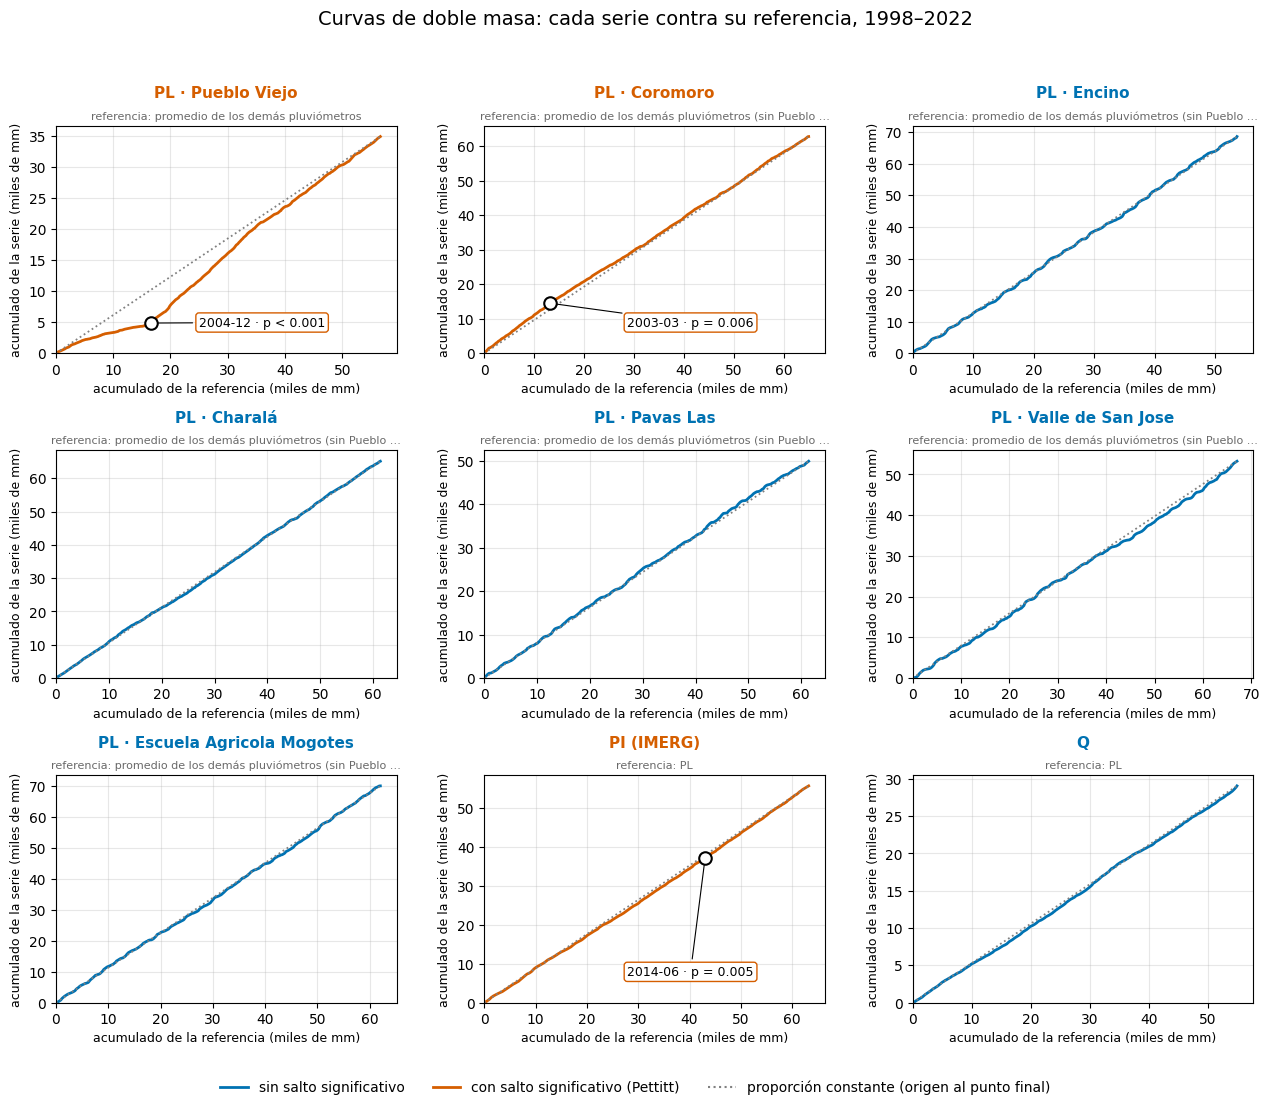

In [43]:
# --- 4.3: saltos bruscos, curvas de doble masa (figura) ---
# Cómo leer una curva de doble masa: cada punto es (acumulado de la referencia, acumulado de la serie).
# Si la serie mantiene una proporción estable con su referencia, la curva es una recta; un quiebre
# (cambio de pendiente) marca el mes desde el cual la serie mide más o menos que antes.
color_estable, color_salto = "#0072B2", "#D55E00"
series_doble_masa = list(anomalias_doble_masa.serie.unique())   # 7 PL, PI y Q, en el orden del archivo

fig, ejes = plt.subplots(3, 3, figsize=(13, 11))
for eje, nombre in zip(ejes.ravel(), series_doble_masa):
    curva = anomalias_doble_masa[anomalias_doble_masa.serie == nombre]
    prueba = anomalias_homogeneidad[anomalias_homogeneidad.serie == nombre].iloc[0]
    x = curva.acumulado_referencia.to_numpy() / 1000    # miles de mm
    y = curva.acumulado_serie.to_numpy() / 1000
    color = color_salto if prueba.significativo else color_estable

    eje.plot(x, y, color=color, lw=2, label="curva de doble masa")
    # Recta de proporción constante: del origen al punto final
    eje.plot([0, x[-1]], [0, y[-1]], color="gray", ls=":", lw=1.3)

    if prueba.significativo:
        # El punto de cambio es el primer mes del segundo tramo
        fila = curva.index[curva.periodo == prueba.primer_mes_despues][0]
        xc, yc = x[curva.index.get_loc(fila)], y[curva.index.get_loc(fila)]
        etiqueta_p = "p < 0.001" if prueba.p < 0.001 else f"p = {prueba.p:.3f}"
        eje.plot(xc, yc, marker="o", ms=9, mfc="white", mec="black", mew=1.5, zorder=5)
        eje.annotate(f"{prueba.primer_mes_despues} · {etiqueta_p}", (xc, yc),
                     xytext=(0.42, 0.12), textcoords="axes fraction", fontsize=9,
                     arrowprops=dict(arrowstyle="-", color="black", lw=0.8),
                     bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=color))

    referencia = str(prueba.referencia)
    if len(referencia) > 48:
        referencia = referencia[:47] + "…"
    eje.set_title(nombre, fontsize=11, fontweight="bold", color=color, pad=20)
    eje.text(0.5, 1.02, "referencia: " + referencia, transform=eje.transAxes,
             ha="center", va="bottom", fontsize=8, color="dimgray")
    eje.set_xlabel("acumulado de la referencia (miles de mm)", fontsize=9)
    eje.set_ylabel("acumulado de la serie (miles de mm)", fontsize=9)
    eje.set_xlim(left=0); eje.set_ylim(bottom=0)
    eje.grid(alpha=0.3)

for eje in ejes.ravel()[len(series_doble_masa):]:
    eje.set_visible(False)

leyenda = [Line2D([0], [0], color=color_estable, lw=2, label="sin salto significativo"),
           Line2D([0], [0], color=color_salto, lw=2, label="con salto significativo (Pettitt)"),
           Line2D([0], [0], color="gray", ls=":", label="proporción constante (origen al punto final)")]
fig.legend(handles=leyenda, loc="lower center", ncol=3, frameon=False, fontsize=10)
fig.suptitle("Curvas de doble masa: cada serie contra su referencia, 1998–2022", fontsize=14, y=0.995)
fig.tight_layout(rect=(0, 0.04, 1, 0.97))
plt.show()


In [44]:
# --- 4.3: lectura de los saltos, con las cifras de la tabla de arriba ---
MESES_LARGOS = ["enero", "febrero", "marzo", "abril", "mayo", "junio", "julio", "agosto", "septiembre",
                "octubre", "noviembre", "diciembre"]
_h = anomalias_homogeneidad.set_index("serie")
_fmt_p = lambda p: "< 0.001" if p < 0.001 else f"= {p:.3f}"
_mes = lambda p: f"{MESES_LARGOS[pd.Period(p, 'M').month - 1]} de {pd.Period(p, 'M').year}"
_pl = _h[_h.index.str.startswith("PL")]
_pv, _pi, _q = _h.loc["PL · Pueblo Viejo"], _h.loc["PI (IMERG)"], _h.loc["Q"]
_otros = _pl[_pl.significativo & (_pl.index != "PL · Pueblo Viejo")]
display(Markdown(f"""
**Lo que se ve.** {int((~_pl.significativo).sum())} de los {len(_pl)} pluviómetros no tienen salto. Los que sí:

1. **Pueblo Viejo** mide {_pv.razon_antes:.2f} veces lo que sus vecinos hasta {_mes(_pv.ultimo_mes_antes)} y
   {_pv.razon_despues:.2f} desde {_mes(_pv.primer_mes_despues)} (*p* {_fmt_p(_pv.p)}). Sus vecinos no acompañan ese
   escalón, así que es un problema de registro del primer tramo, no del clima. **Decisión:** ese tramo sale de PL
   en todos los análisis (`scripts/07_pluviometros_dhime.py`), como Encino 2016-2018.
""" + "".join(f"""
{k}. **{s.split(' · ')[1]}**: {f.cambio_pct:+.0f} % desde {_mes(f.primer_mes_despues)} (*p* {_fmt_p(f.p)}, con {', '.join(
   f.referencia.split('(sin ')[1].rstrip(')').split(', ')) if '(sin ' in f.referencia else 'ninguna estación'} fuera de la
   referencia). **Se conserva y se registra como incierto**: año por año no se ve un escalón limpio.
""" for k, (s, f) in enumerate(_otros.iterrows(), start=2)) + f"""
**PI frente a PL:** {_pi.cambio_pct:+.0f} % desde {_mes(_pi.primer_mes_despues)} (*p* {_fmt_p(_pi.p)}); PI pasa de
{_pi.razon_antes:.2f} a {_pi.razon_despues:.2f} veces PL. El corte cae en el cambio de era de IMERG: según su
documentación técnica, hasta mayo de 2014 se calibra con TRMM y desde el 1 de junio de 2014 con GPM (Huffman et al.,
2023). Ningún pluviómetro salta en esa fecha, así que el cambio es del producto satelital. **PI se conserva y se
registra como incierto**: es la fuente de contraste, y en lo que hay que escoger manda PL.

**Q frente a PL:** {"sin salto" if not _q.significativo else "con salto"} (*p* {_fmt_p(_q.p)}).

**Metadatos.** El catálogo del IDEAM no guarda historia de reubicaciones ni de cambios de instrumento: de cada
estación solo da la fecha de instalación (todas anteriores a 1998), la tecnología (convencional) y el estado
(activa). Los saltos de los pluviómetros no se pueden confirmar ni descartar con metadatos; el de IMERG, sí.
"""))


**Lo que se ve.** 5 de los 7 pluviómetros no tienen salto. Los que sí:

1. **Pueblo Viejo** mide 0.27 veces lo que sus vecinos hasta noviembre de 2004 y
   0.74 desde diciembre de 2004 (*p* < 0.001). Sus vecinos no acompañan ese
   escalón, así que es un problema de registro del primer tramo, no del clima. **Decisión:** ese tramo sale de PL
   en todos los análisis (`scripts/07_pluviometros_dhime.py`), como Encino 2016-2018.

2. **Coromoro**: -20 % desde marzo de 2003 (*p* = 0.006, con Pueblo Viejo fuera de la
   referencia). **Se conserva y se registra como incierto**: año por año no se ve un escalón limpio.

**PI frente a PL:** +11 % desde junio de 2014 (*p* = 0.005); PI pasa de
0.84 a 0.94 veces PL. El corte cae en el cambio de era de IMERG: según su
documentación técnica, hasta mayo de 2014 se calibra con TRMM y desde el 1 de junio de 2014 con GPM (Huffman et al.,
2023). Ningún pluviómetro salta en esa fecha, así que el cambio es del producto satelital. **PI se conserva y se
registra como incierto**: es la fuente de contraste, y en lo que hay que escoger manda PL.

**Q frente a PL:** sin salto (*p* = 0.177).

**Metadatos.** El catálogo del IDEAM no guarda historia de reubicaciones ni de cambios de instrumento: de cada
estación solo da la fecha de instalación (todas anteriores a 1998), la tecnología (convencional) y el estado
(activa). Los saltos de los pluviómetros no se pueden confirmar ni descartar con metadatos; el de IMERG, sí.


In [45]:
# --- 4.3: secuencias constantes, extremos aislados de Q y meses con 0 mm ---
print(f"rachas de Q o de temperatura con 5+ días iguales: "
      f"{int(anomalias_rachas.variable.str.contains('diario|ERA5').sum())}")
print(f"picos aislados de Q (≥ 3 veces sus dos días vecinos): {len(anomalias_picos_q)}")
print("meses seguidos con el mismo total en un pluviómetro:")
print(anomalias_rachas[anomalias_rachas.variable.str.startswith("PL")].to_string(index=False))
print("\nmeses con 0 mm (serie antes de esta sección):")
anomalias_ceros_pl[["pluviometro", "periodo", "otros_con_dato", "otros_minimo_mm", "otros_promedio_mm",
                    "pi_mm", "dificil_de_creer"]].round(1)

rachas de Q o de temperatura con 5+ días iguales: 0
picos aislados de Q (≥ 3 veces sus dos días vecinos): 0
meses seguidos con el mismo total en un pluviómetro:
                   variable   desde   hasta  largo  valor unidad
   PL · Pavas Las (mensual) 2020-06 2020-07      2   80.0     mm
PL · Pueblo Viejo (mensual) 2002-01 2002-02      2    2.0     mm
PL · Pueblo Viejo (mensual) 2009-10 2009-11      2  192.0     mm

meses con 0 mm (serie antes de esta sección):


,pluviometro,periodo,otros_con_dato,otros_minimo_mm,otros_promedio_mm,pi_mm,dificil_de_creer
0,Pavas Las,2000-08,6,34.0,145.2,218.6,True
1,Pavas Las,2001-08,6,2.0,124.6,169.3,False
2,Pavas Las,2009-07,5,49.0,110.9,161.3,True
3,Pavas Las,2013-07,5,50.1,97.2,102.8,True
4,Pavas Las,2018-05,4,257.0,394.8,310.2,True
5,Pavas Las,2019-07,6,67.0,157.4,128.1,True
6,Pueblo Viejo,2020-02,6,3.1,72.6,95.8,False
7,Valle de San Jose,2017-12,5,101.8,145.3,119.1,True
8,Valle de San Jose,2021-12,6,53.0,129.4,127.3,True


In [46]:
# --- 4.3: lectura de secuencias, picos y meses en cero ---
_rachas_dia = anomalias_rachas[~anomalias_rachas.variable.str.startswith("PL")]
_rachas_pl = anomalias_rachas[anomalias_rachas.variable.str.startswith("PL")]
_fuera = anomalias_ceros_pl[anomalias_ceros_pl.dificil_de_creer]
_quedan = anomalias_ceros_pl[~anomalias_ceros_pl.dificil_de_creer]
_mes = lambda p: f"{MESES_LARGOS[pd.Period(p, 'M').month - 1]} de {pd.Period(p, 'M').year}"
_peor = _fuera.loc[_fuera.otros_minimo_mm.idxmax()]
display(Markdown(f"""
**Lo que se ve.**

1. **Q y temperatura:** {"no hay" if _rachas_dia.empty else f"hay {len(_rachas_dia)}"} tramos de 5 días o más con el
   mismo valor exacto, que sería la huella de un limnímetro trabado o de un dato copiado, y
   {"ningún día" if anomalias_picos_q.empty else f"{len(anomalias_picos_q)} días"} de Q que triplique a sus dos vecinos:
   las crecidas de San Gil suben y bajan en varios días.
2. **{len(_rachas_pl)} pares de meses seguidos con el mismo total en un pluviómetro**:
   {"; ".join(f"{v.split(' · ')[1].split(' (')[0]} {d} y {h} ({val:.1f} mm)" for v, d, h, val in _rachas_pl[["variable", "desde", "hasta", "valor"]].itertuples(index=False))}.
   Son coincidencias posibles o caen en tramos ya excluidos; no cambian nada.
3. **De los {len(anomalias_ceros_pl)} meses con 0 mm, {len(_fuera)} son difíciles de creer**: todos los demás
   pluviómetros midieron al menos 20 mm. El caso más claro es {_peor.pluviometro} en {_mes(_peor.periodo)}, con vecinos de
   {_peor.otros_minimo_mm:.0f} mm o más. **Decisión:** se tratan como meses no registrados y salen de PL; en un
   pluviómetro, un 0 suele ser una planilla vacía. Los otros {len(_quedan)}
   ({", ".join(f"{p} en {_mes(m)}" for p, m in _quedan[["pluviometro", "periodo"]].itertuples(index=False))}) son
   plausibles, porque algún vecino también midió casi nada, y se quedan.
"""))


**Lo que se ve.**

1. **Q y temperatura:** no hay tramos de 5 días o más con el
   mismo valor exacto, que sería la huella de un limnímetro trabado o de un dato copiado, y
   ningún día de Q que triplique a sus dos vecinos:
   las crecidas de San Gil suben y bajan en varios días.
2. **3 pares de meses seguidos con el mismo total en un pluviómetro**:
   Pavas Las 2020-06 y 2020-07 (80.0 mm); Pueblo Viejo 2002-01 y 2002-02 (2.0 mm); Pueblo Viejo 2009-10 y 2009-11 (192.0 mm).
   Son coincidencias posibles o caen en tramos ya excluidos; no cambian nada.
3. **De los 9 meses con 0 mm, 7 son difíciles de creer**: todos los demás
   pluviómetros midieron al menos 20 mm. El caso más claro es Pavas Las en mayo de 2018, con vecinos de
   257 mm o más. **Decisión:** se tratan como meses no registrados y salen de PL; en un
   pluviómetro, un 0 suele ser una planilla vacía. Los otros 2
   (Pavas Las en agosto de 2001, Pueblo Viejo en febrero de 2020) son
   plausibles, porque algún vecino también midió casi nada, y se quedan.


In [47]:
# --- 4.3: cobertura de PL: sesgo estimado en los meses en que faltan pluviómetros (serie depurada) ---
sesgo = anomalias_cobertura_pl.sesgo_estimado_pct
print(f"{len(anomalias_cobertura_pl)} meses con algún pluviómetro faltante; sesgo estimado de PL: "
      f"mediana {sesgo.abs().median():.1f} %, máximo {sesgo.abs().max():.1f} %; "
      f"{int((sesgo.abs() > 5).sum())} meses por encima de 5 %")
print("\ntramos excluidos de PL:")
pluvio_exclusiones.assign(pluviometro=pluvio_exclusiones.codigo.map(PLUVIOMETROS))[
    ["pluviometro", "desde", "hasta", "meses_excluidos", "evidencia"]]

168 meses con algún pluviómetro faltante; sesgo estimado de PL: mediana 3.8 %, máximo 8.1 %; 9 meses por encima de 5 %

tramos excluidos de PL:


,pluviometro,desde,hasta,meses_excluidos,evidencia
0,Encino,2016-01,2018-12,36,1.7
1,Pueblo Viejo,1998-01,2004-11,76,4.3
2,Pavas Las,2000-08,2000-08,1,4.3
3,Pavas Las,2009-07,2009-07,1,4.3
4,Pavas Las,2013-07,2013-07,1,4.3
5,Pavas Las,2018-05,2018-05,1,4.3
6,Pavas Las,2019-07,2019-07,1,4.3
7,Valle de San Jose,2017-12,2017-12,1,4.3
8,Valle de San Jose,2021-12,2021-12,1,4.3


In [48]:
# --- 4.3: lectura de la cobertura y del efecto de las exclusiones sobre PL ---
_sesgo = anomalias_cobertura_pl.sesgo_estimado_pct.abs()
_pi_pl = (variables_resumen["PI (mm/mes)"].mean() / variables_resumen["PL (mm/mes)"].mean() - 1) * 100
display(Markdown(f"""
**Lo que se ve.** A PL le falta algún pluviómetro en {len(anomalias_cobertura_pl)} meses. El efecto se estima en los
meses en que están los 7: para cada grupo de estaciones presentes, la mediana de su promedio dividido por el de los 7.
El sesgo de PL es pequeño: {_sesgo.median():.1f} % en la mediana, {_sesgo.max():.1f} % como máximo, y solo
{int((_sesgo > 5).sum())} meses pasan de 5 %. No se corrige; queda como incertidumbre declarada.

Con todas las exclusiones de la tabla, PL promedia {variables_resumen["PL (mm/mes)"].mean():.1f} mm/mes y **PI queda un
{abs(_pi_pl):.1f} % por debajo de PL**.
"""))


**Lo que se ve.** A PL le falta algún pluviómetro en 168 meses. El efecto se estima en los
meses en que están los 7: para cada grupo de estaciones presentes, la mediana de su promedio dividido por el de los 7.
El sesgo de PL es pequeño: 3.8 % en la mediana, 8.1 % como máximo, y solo
9 meses pasan de 5 %. No se corrige; queda como incertidumbre declarada.

Con todas las exclusiones de la tabla, PL promedia 210.7 mm/mes y **PI queda un
12.0 % por debajo de PL**.
